## Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve, r2_score
import os
import math
from datetime import datetime, timedelta
import plotly.express as px
from scipy import stats

## Database

In [2]:
project_dir = os.path.join(os.path.expanduser("~"), "OneDrive", "Project_Code", "ASN-DSA-T5", "30-MM", "Projeto_1")
project_dir


'C:\\Users\\kel_m\\OneDrive\\Project_Code\\ASN-DSA-T5\\30-MM\\Projeto_1'

In [3]:
# Pre-processing
arquivo = os.path.join(project_dir,'data/2_envio_case_base_Total_2026_adj.csv')
import re

with open(arquivo) as f:
    texto = f.read()

texto = re.sub(r'\((\d+),\s*(\d+)\]', r'(\1;\2]', texto)

from io import StringIO
df = pd.read_csv(StringIO(texto), sep=",",  index_col=False)

In [4]:
# Variables Format
df.sample(10)

,id,ano_mes,idade_veiculo,marca,vl_bem,idade,estado_civil,qt_restr,renda,Regiao,Profissao,entrada,prazo,pmt,target,FPD,score,contratado
412478,331921401,202210,1_2,VW,(25000;70000],32,casado,0,3453,SE,autonomos,0,36,1311,0.0,0.0,4,1
18903,685000994,202301,1_2,Fiat,(0;25000],39,divorciado,0,3177,NE,assalariados,40,36,421,0.0,0.0,7,1
210231,851104606,202311,3_5,VW,(25000;70000],55,viuvo,0,3000,SE,prof_serv,30,48,927,0.0,0.0,7,1
644947,264586500,202410,1_2,Toyota,(25000;70000],27,divorciado,0,3126,SE,prof_serv,20,36,1172,0.0,0.0,6,1
641763,359152823,202410,10,Outros,(0;25000],18,divorciado,0,3626,CO,prof_serv,10,48,512,NaN,NaN,3,0
746343,531807877,202505,6_10,Toyota,(0;25000],38,solteiro,0,25878,CO,liberais,0,36,767,NaN,NaN,4,0
460988,906540901,202205,10,Chevrolet,(25000;70000],54,viuvo,0,24075,N,autonomos,30,24,1830,0.0,0.0,7,1
630991,116413620,202412,6_10,Outros,(25000;70000],36,viuvo,0,20422,SE,autonomos,10,48,777,0.0,0.0,5,1
473975,844613454,202208,1_2,Hyundai,(25000;70000],44,solteiro,0,21743,CO,consignados,0,36,1081,0.0,0.0,8,1
714155,177091678,202501,3_5,Ford,(25000;70000],31,solteiro,0,16522,CO,prof_serv,30,24,2193,0.0,0.0,8,1


## Cleaning

### Adjust Variables

- `contratado` : convert to numeric

In [5]:
df['contratado'] = pd.to_numeric(df['contratado'], errors='coerce')

### New Variables 

- `comp_renda` : `prestacao`/`renda` - comprometimento de renda
- `tt_financiado_com_juros` : `prazo` * `pmt` = total financiado com juros 
- `valor_medio_fx` : (min fx vl bem `valor_min` + max fx vl bem `valor_max` ) / 2 - média da faixa do valor do bem 
- `idade_media_veiculo` : média da faixa da idade veiculo 
- `vl_medio_por_idade_media_veiculo` : média da faixa do valor do bem / média da faixa da idade veiculo  = valor médio por tempo médio de fabricação
- `vl_a_pagar_por_idade_media_veiculo` : total financiado com juros / média da faixa da idade veiculo = valor a pagar do contrato por média de tempo do veículo
- `nacionalidade` : separar as marcas por nacionalidade
- `id_duplicado` : contar ids duplicados
- `flg_restr` : flg qt_restr
- a partir de quando foi a primeira restrição? (possível mudança de mercado)
- tx restrição mensal por renda
- Criar one hot encoder para veriifcar percentual por mês de cada categoria


In [6]:
df['comp_renda'] = df['pmt'] / df['renda']
df['tt_financiado_com_juros'] = df['pmt'] * df['prazo']
df['valor_min'] = df['vl_bem'].str.extract(r'\((\d+);').fillna(0).astype(int)
df['valor_max'] = df['vl_bem'].str.extract(r';(\d+)\]').fillna(0).astype(int)
df['valor_medio_fx'] = (df['valor_max'] + df['valor_min']) / 2

In [7]:
df['idade_veiculo'].unique()

def media_idade(row):
    if row.idade_veiculo == '3_5':
        return 4
    elif row.idade_veiculo == '1_2':
        return 1.5
    elif row.idade_veiculo == '6_10':
        return 8
    else:
        return int(row.idade_veiculo)

df['idade_media_veiculo'] = df.apply(media_idade, axis = 1)

In [8]:
df['vl_medio_por_idade_media_veiculo']  = np.divide(
    df['valor_medio_fx'],
    df['idade_media_veiculo'],
    out=np.zeros_like(df['valor_medio_fx'], dtype=float),
    where=df['idade_media_veiculo'] != 0
)

df['vl_a_pagar_por_idade_media_veiculo']  = np.divide(
    df['tt_financiado_com_juros'],
    df['idade_media_veiculo'],
    out=np.zeros_like(df['tt_financiado_com_juros'], dtype=float),
    where=df['idade_media_veiculo'] != 0
)

In [9]:
# Brand Country
nacionalidade_marcas = {
    'Chevrolet': 'Estados Unidos',
    'Fiat': 'Itália',
    'VW': 'Alemanha',
    'Ford': 'Estados Unidos',
    'Toyota': 'Japão',
    'Outros': 'Outros',
    'Honda': 'Japão',
    'Nissan': 'Japão',
    'Peugeot': 'França',
    'Hyundai': 'Coreia do Sul',
    'Jac': 'China'
}
df['nacionalidade'] = df['marca'].map(nacionalidade_marcas)

In [10]:
# duplicate id
df['id_duplicado'] = df['id'].duplicated()

In [11]:
# restriction flag
df['flg_restr'] = (df['qt_restr'] != '0').astype(int)

In [12]:
# Periods 
peri_treinamento = [202203,202204,202205,202206,202207,202208,202209,202210,202211,202212,202301,202302]
peri_observacao = [202303,202304,202305,202306,202307,202308,202309,202310,202311,202312,202401,202402]

In [13]:
def generate_month_list(start_date, end_date):
    """Generate a list of months in YYYYMM format between start and end dates"""
    months = []
    current = datetime.strptime(start_date, "%Y%m")
    end = datetime.strptime(end_date, "%Y%m")
    
    while current <= end:
        months.append(int(current.strftime("%Y%m")))
        # Move to next month
        if current.month == 12:
            current = current.replace(year=current.year + 1, month=1)
        else:
            current = current.replace(month=current.month + 1)
    
    return months

# Generate your periods
peri_treinamento = generate_month_list("202203", "202302")
peri_observacao = generate_month_list("202303", "202402")

print("peri_treinamento =", peri_treinamento)
print("peri_observacao =", peri_observacao)

peri_treinamento = [202203, 202204, 202205, 202206, 202207, 202208, 202209, 202210, 202211, 202212, 202301, 202302]
peri_observacao = [202303, 202304, 202305, 202306, 202307, 202308, 202309, 202310, 202311, 202312, 202401, 202402]


In [14]:
def generate_periods(start_date, end_date, output_format="int"):
    """
    Generate a list of months between start and end dates
    
    Args:
        start_date: string in format "YYYYMM" (e.g., "202203")
        end_date: string in format "YYYYMM" (e.g., "202302")
        output_format: format of the output
            - "int": 202203, 202204, ... (default)
            - "str": "2022-03", "2022-04", ...
            - "str_slash": "2022/03", "2022/04", ...
            - "month_name": "Mar/2022", "Apr/2022", ...
            - "month_name_pt": "Mar/2022", "Abr/2022", ... (Portuguese)
            - "tuple": (2022,3), (2022,4), ...
            - "datetime": datetime objects
            - "year_month": {"year":2022, "month":3}, ...
    
    Returns:
        List of months in the specified format
    """
    # Parse start and end dates
    start = datetime.strptime(start_date, "%Y%m")
    end = datetime.strptime(end_date, "%Y%m")
    
    # Portuguese month abbreviations
    months_pt = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", 
                 "Jul", "Ago", "Set", "Out", "Nov", "Dez"]
    
    # English month abbreviations
    months_en = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                 "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    
    periods = []
    current = start
    
    while current <= end:
        year = current.year
        month = current.month
        
        if output_format == "int":
            periods.append(year * 100 + month)
        
        elif output_format == "str":
            periods.append(f"{year}-{month:02d}")
        
        elif output_format == "str_slash":
            periods.append(f"{year}/{month:02d}")
        
        elif output_format == "month_name":
            periods.append(f"{months_en[month-1]}/{year}")
        
        elif output_format == "month_name_pt":
            periods.append(f"{months_pt[month-1]}/{year}")
        
        elif output_format == "tuple":
            periods.append((year, month))
        
        elif output_format == "datetime":
            periods.append(current)
        
        elif output_format == "year_month":
            periods.append({"year": year, "month": month, 
                           "month_name": months_en[month-1]})
        
        elif output_format == "compact":
            periods.append(f"{year}{month:02d}")
        
        else:
            raise ValueError(f"Unknown format: {output_format}")
        
        # Move to next month
        if month == 12:
            current = current.replace(year=year + 1, month=1)
        else:
            current = current.replace(month=month + 1)
    
    return periods

# Examples of different formats
# print("1. Integer format:")
# print(generate_periods("202203", "202302", "int"))

# print("\n2. String with hyphen:")
# print(generate_periods("202203", "202302", "str"))

# print("\n3. String with slash:")
# print(generate_periods("202203", "202302", "str_slash"))

# print("\n4. Month name (English):")
# print(generate_periods("202203", "202302", "month_name"))

# print("\n5. Month name (Portuguese):")
# print(generate_periods("202203", "202302", "month_name_pt"))

# print("\n6. Tuples:")
# print(generate_periods("202203", "202302", "tuple"))

# print("\n7. Datetime objects:")
# print(generate_periods("202203", "202302", "datetime"))

# print("\n8. Dictionary format:")
# print(generate_periods("202203", "202302", "year_month"))

# print("\n9. Compact string:")
# print(generate_periods("202203", "202302", "compact"))

# Now you can easily create your periods in any format
# peri_treinamento = generate_periods("202203", "202302", "int")  # or any format you want
# peri_observacao = generate_periods("202303", "202402", "month_name_pt")  # Portuguese format

# print(f"\nTraining period (int): {peri_treinamento}")
# print(f"Observation period (PT): {peri_observacao}")

period_modeling = generate_periods("202203", "202302", "int")
period_observed = generate_periods("202303", "202402", "int")
period_production = generate_periods("202405", "202512", "int")

period_dt_modeling = generate_periods("202203", "202302", "month_name")
period_dt_observed = generate_periods("202303", "202402", "month_name")
period_dt_production = generate_periods("202405", "202512", "month_name")


In [15]:
df['per_model'] = ((df['ano_mes'] >= 202203) & (df['ano_mes'] <= 202302)).astype(int)
df['per_observed'] = ((df['ano_mes'] >= 202303) & (df['ano_mes'] <= 202402)).astype(int)
df['per_limbo'] = ((df['ano_mes'] >= 202403) & (df['ano_mes'] <= 202404)).astype(int)
df['per_production'] = (df['ano_mes'] >= 202405).astype(int)
df['per_observed2'] = ((df['ano_mes'] >= 202303) & (df['ano_mes'] <= 202404)).astype(int)


## Functions

In [16]:
# Function: univariate_numeric_variable: Create relevant charts for univariated analysis on numeric variable.
def univariate_numeric_variable(data, variable):
    """
    Generates a matrix of charts (2x2) for a numeric continuous variable.

    [1,1] Histogram
    [1,2] Violin Plot
    [2,1] Box plot
    [2,2] Box plot with points overlaid

    Above the charts, shows a table with the variable descriptive statistics.

    Parameters:
        data (pd.DataFrame): Database containing the variable.
        variable (str): Name of the variable to be analysed.

    Returns:
        None

    Usage example:
        >> data = pd.DataFrame({"example_variable": np.random.normal(loc=50, scale=10, size=100)})
        >>univariate_numeric_variable(data, "example_variable")
        
    """
    
    # Calculate descriptive statistics
    desc_stats = data[variable].describe().to_frame().T
    desc_stats = desc_stats.round(4)  # Limit to 4 decimal places

    # Configuration of subplots
    fig = plt.figure(figsize=(8, 6))
    fig.suptitle(f"Analysing: {variable}", fontsize=16, y=0.98)

    # Add table on the top
    ax_table = plt.subplot2grid((3, 2), (0, 0), colspan=2)
    ax_table.axis("off")
    table = ax_table.table(cellText=desc_stats.values,
                           colLabels=desc_stats.columns,
                           rowLabels=desc_stats.index,
                           cellLoc="center",
                           loc="center",
                           bbox=[0, 0, 1, 1]) 
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.auto_set_column_width(col=list(range(len(desc_stats.columns))))

    # Add padding by scaling the table
    table.scale(1.2, 1.8)  # Adjust these values for horizontal/vertical padding

    # [1,1] Histogram
    ax1 = plt.subplot2grid((3, 2), (1, 0))
    sns.histplot(data[variable], kde=True, ax=ax1, color="skyblue")
    ax1.set_title("Histogram", fontsize=12)
    ax1.set_xlabel(variable)

    # [1,2] Violin Chart
    ax2 = plt.subplot2grid((3, 2), (1, 1), sharex=ax1)
    sns.violinplot(x=data[variable], ax=ax2, color="lightgreen")
    ax2.set_title("Violin Chart", fontsize=12)
    ax2.set_xlabel(variable)

    # [2,1] Box plot
    ax3 = plt.subplot2grid((3, 2), (2, 0), sharex=ax1)
    sns.boxplot(x=data[variable], ax=ax3, color="orange")
    ax3.set_title("Box plot", fontsize=12)
    ax3.set_xlabel(variable)

    # [2,2] Box plot with points overlaid
    ax4 = plt.subplot2grid((3, 2), (2, 1), sharex=ax1)
    sns.boxplot(x=data[variable], ax=ax4, color="lightcoral")
    sns.stripplot(x=data[variable], ax=ax4, color="black", alpha=0.5, jitter=True)
    ax4.set_title("Box plot with points", fontsize=12)
    ax4.set_xlabel(variable)

    # Final Adjustments
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [17]:
# Function: univariate_categorical_variable: Create relevant charts for univariated analysis on categorical variable.
def univariate_categorical_variable(data, variable):
    """
    Analyse categorical variable.

    1. Returns transposed describe function in a table format.
    2. Returns a table with level frequency (including percentage and total).
    3. Plot a bar chart with frequency and show values on top.

    Parameters:
        data (pd.DataFrame): Database containing the variable.
        variable (str): Name of the variable to be analysed.

    Returns:
        None

    Usage example:
        >>> import pandas as pd
        >>> df = pd.DataFrame({'Caregory': ['A', 'B', 'A', 'C', 'B', 'A', 'C', 'C', 'A', 'B']})
        >>> univariate_categorical_variable(df, 'Caregory')
    """
    # Verify if variable is on the dataframe
    if variable not in data.columns:
        raise ValueError(f"Variable '{variable}' is not in the DataFrame.")

    # 1. Transposed and formated describe
    describe_table = data[variable].describe().to_frame()
    describe_table = describe_table.T
    describe_table.index = [variable]

    # Show formated table
    print("Categorical variable describe:")
    display(describe_table)

    # 2. Frequency of each level (percentage and total)
    frequency_table = data[variable].value_counts().reset_index()
    frequency_table.columns = [variable, 'Frequency']
    frequency_table['Percentage (%)'] = (frequency_table['Frequency'] / len(data) * 100).round(2)

    # Add line for total
    total_row = pd.DataFrame({
        variable: ['Total'],
        'Frequency': [frequency_table['Frequency'].sum()],
        'Percentage (%)': [100.0]
    })
    frequency_table = pd.concat([frequency_table, total_row], ignore_index=True)

    # Show formated table
    print("Frequency table of categorical variable (with percentage and total):")
    display(frequency_table)

    # 3. Frequency bar chart
    plt.figure(figsize=(8, 5))
    ax = sns.barplot(x=variable, y='Frequency', data=frequency_table[:-1], errorbar=None)

    # Add lables on top of the bar
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=7, color='black',
                    xytext=(0, 5), textcoords='offset points')

    # Configure chart
    plt.title(f'Frequency chart: {variable}')
    plt.xlabel(variable)
    plt.ylabel('Frequency')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()



In [18]:
# Function: numeric_variable_analysis_percentile: Percentile analysis for one numeric variable.
def numeric_variable_analysis_percentile(data, x, y, q=10, chart='none'):
    """
    Sort variable x, divide in percentile and summarize.

    Paameters:
        data (pd.DataFrame): Database containing the variable.
        x (str): Name of the independent varaible.
        y (str): Name of dependent variable.
        q (int): Number of percentile (default: 10).
        chart (str): Chart options: 'p', 'logit', 'both', 'none' (default: 'none').

    Returns:
        pd.DataFrame: DataFrame with summarize statistics by percentile, incluindo:
                      - Percentile
                      - n (number of rows)
                      - Min x
                      - Max x
                      - p (mean y)
                      - logit p

    Usage example:
        >> data = pd.DataFrame({'x': np.random.uniform(0, 100, 1000), 
        'y': np.random.randint(0, 2, 1000)})
        >> result = numeric_variable_analysis_percentile(data, 'x', 'y', q=10, chart='both')
        >> print(result)
    """
    # Certify that y varaible is in a numeric format
    data[y] = pd.to_numeric(data[y], errors='coerce')

    # Sort dataframe by x variable
    data = data.sort_values(by=x).reset_index(drop=True)

    # Create percentiles
    data['percentile'] = pd.qcut(data[x], q=q, labels=[str(i) for i in range(1, q + 1)])

    # Summaraize statistics per percentile
    summary = data.groupby('percentile').agg(
        n=(x, 'count'),
        min_x=(x, 'min'),
        max_x=(x, 'max'),
        p=(y, 'mean')
    ).reset_index()

    # Calculate logit p
    summary['logit_p'] = np.log(summary['p'] / (1 - summary['p']))

    # Adjust to deal where p is 0 or 1
    epsilon = 1e-10  # smal value to adjust 0 e 1
    summary['logit_p'] = np.log(np.clip(summary['p'], epsilon, 1 - epsilon) / 
                                 (1 - np.clip(summary['p'], epsilon, 1 - epsilon)))


    # Chart option
    if chart in ['p', 'logit', 'both']:
        plt.figure(figsize=(8, 6))

        if chart == 'p':
            plt.scatter(summary['percentile'], summary['p'], color='blue')
            plt.title('Percentile chart x p')
            plt.xlabel('Percentile')
            plt.ylabel('p (average of y)')
            plt.grid(True)
            plt.show()

        elif chart == 'logit':
            plt.scatter(summary['percentile'], summary['logit_p'], color='red')
            plt.title('Percentile chart x logit p')
            plt.xlabel('Percentile')
            plt.ylabel('logit p')
            plt.grid(True)
            plt.show()

        elif chart == 'both':
            # Chart side-by-side
            fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

            # Percentile Chart x p
            axes[0].scatter(summary['percentile'], summary['p'], color='blue')
            axes[0].set_title('Percentile x p')
            axes[0].set_xlabel('Percentile')
            axes[0].set_ylabel('p (average of y)')
            axes[0].grid(True)

            # Percentile Chart x logit p
            axes[1].scatter(summary['percentile'], summary['logit_p'], color='red')
            axes[1].set_title('Percentile x logit p')
            axes[1].set_xlabel('Percentile')
            axes[1].set_ylabel('logit p')
            axes[1].grid(True)

            plt.tight_layout()
            plt.show()

    return summary

In [19]:
def assign_percentile_group(value, percentile_df):
    """
    Assign percentile group based on min/max ranges from percentile table
    """
    for _, row in percentile_df.iterrows():
        if row['min_x'] <= value <= row['max_x']:
            return row['percentile']
    return None

In [20]:
def bivariate_categorical_analysis(data, x, y):
    result = data.groupby(x)[y].agg([
        ('Frequency', 'count'),
        ('Probability', lambda x: x.mean().round(4)), 
        ]).reset_index()

    result['Percentage (%)'] = (result['Frequency'] / len(data) * 100).round(2)

    return result

In [21]:
def univariate_missing_analysis(df, variable):
    # Calculate missing stats
    total_rows = len(df)
    missing_count = df[variable].isna().sum()
    present_count = total_rows - missing_count
    missing_pct = (missing_count / total_rows) * 100
    present_pct = (present_count / total_rows) * 100

    # Create a simple table
    missing_table = pd.DataFrame({
        'Category': ['Missing', 'Present', 'Total'],
        'Count': [missing_count, present_count, total_rows],
        'Percentage': [f"{missing_pct:.2f}%", f"{present_pct:.2f}%", "100%"]
    })

    print(f"Missing Value Analysis for: {variable}")
    print("=" * 50)
    print(missing_table.to_string(index=False))

In [22]:
def missing_by_flag_simple(df, variable, flag_col):
    """
    Simple missing analysis by binary flag
    """
    
    total_rows = len(df)
    
    print(f"\nMissing Value Analysis for: {variable} by {flag_col}")
    print("=" * 60)
    
    for flag_value in [0, 1]:
        flag_df = df[df[flag_col] == flag_value]
        flag_rows = len(flag_df)
        missing = flag_df[variable].isna().sum()
        present = flag_rows - missing
        missing_pct = (missing / flag_rows) * 100
        present_pct = (present / flag_rows) * 100
        
        print(f"\n{flag_col} = {flag_value}:")
        print(f"  Total rows: {flag_rows:,}")
        print(f"  Missing:    {missing:,} ({missing_pct:.2f}%)")
        print(f"  Present:    {present:,} ({present_pct:.2f}%)")
    
    # Also show overall
    overall_missing = df[variable].isna().sum()
    overall_pct = (overall_missing / total_rows) * 100
    print(f"\nOVERALL:")
    print(f"  Total rows: {total_rows:,}")
    print(f"  Missing:    {overall_missing:,} ({overall_pct:.2f}%)")
    print("=" * 60)



In [23]:
def missing_var_when_flag_1(df, variable, flag_columns):
    """
    Analyze missing values in 'variable' only when each flag column == 1
    Returns a single comparison table
    """
    
    results = []
    total_rows_all = len(df)
    var_missing_all = df[variable].isna().sum()
    var_present_all = total_rows_all - var_missing_all
    var_missing_pct_all = (var_missing_all / total_rows_all) * 100
    
    for flag_col in flag_columns:
        # Filter rows where flag == 1
        flag_1_df = df[df[flag_col] == 1]
        flag_1_rows = len(flag_1_df)
        
        # Calculate missing in variable for these rows
        var_missing = flag_1_df[variable].isna().sum()
        var_present = flag_1_rows - var_missing
        var_missing_pct = (var_missing / flag_1_rows) * 100 if flag_1_rows > 0 else 0
        
        results.append({
            'Flag_Column': flag_col,
            'Rows_When_Flag_1': f"{flag_1_rows:,}",
            'var_Missing': f"{var_missing:,}",
            'var_Present': f"{var_present:,}",
            'Missing_%': f"{var_missing_pct:.2f}%",
            'vs_Overall': f"{var_missing_pct - var_missing_pct_all:+.2f}%"
        })
    
    # Create DataFrame
    result_df = pd.DataFrame(results)
    
    print("\n" + "="*90)
    print(" MISSING VALUES IN 'var' WHEN FLAG = 1")
    print("="*90)
    print(result_df.to_string(index=False))
    print("="*90)
    print(f"\n📊 OVERALL (all rows):")
    print(f"   Total rows: {total_rows_all:,}")
    print(f"   var missing: {var_missing_all:,} ({var_missing_pct_all:.2f}%)")
    print(f"   var present: {var_present_all:,} ({100 - var_missing_pct_all:.2f}%)")
    
    return result_df

## EDA - Univariate



| variável      | tipo       | descrição                                                                                                             |
| ------------- | ---------- | --------------------------------------------------------------------------------------------------------------------- |
| id            | chave      | numero de identificação da proposta de crédito                                                                        |
| ano_mes       | data       | data da proposta do crédito                                                                                           |
| idade_veiculo | categórica | idade do veículo a ser financiado                                                                                     |
| marca         | categórica | marca do veículo a ser financiado                                                                                     |
| vl_bem        | categórica | valor do veículo a ser financiado                                                                                     |
| idade         | contínua   | idade do proponente                                                                                                   |
| estado_civil  | categórica | estado civil do proponente                                                                                            |
| qt_restr      | categórica | quantidade de restritivos em aberto no mercado em nome do proponente                                                  |
| renda         | contínua   | renda do proponente                                                                                                   |
| Regiao        | categórica | região de residencia do proponente                                                                                    |
| Profissao     | categórica | profissão do proponente                                                                                               |
| entrada       | contínua   | % proposto pelo proponente a dar de entrada na aquisição do veículo                                                   |
| prazo         | contínua   | quantidade de parcelas que o proponente pretende pagar                                                                |
| pmt           | contínua   | valor da prestação                                                                                                    |
| target        | dicotômica | se o contrato foi inadimplente (1) ou não (0). Se estiver vazio é porque o contrato não foi efetivado                 |
| FPD           | dicotômica | se o contrato teve inadimplencia na 1a parcela (1) ou não (0). Se estiver vazio é porque o contrato não foi efetivado |
| score         | categórica | qualidade de crédito baseado no modelo estatístico desenvolvido pelo banco (usando o período de 2017)                 |
| contratado    | dicotômica | se a proposta foi efetivada (virou contrato) ou não                                                                   |



In [24]:
fig = px.timeline(
    x_start=["2022-03", "2023-03", "2024-05"],
    x_end=["2023-02", "2024-02", "2025-12"],
    y=["Modelagem", "Observação", "Produção"],
    color=["Modelagem", "Observação", "Produção"],
    labels={"y": "Fase do Projeto"}
)
fig.update_layout(title="Linha do tempo do projeto")
fig.show()

In [25]:
flags = ['per_model', 'per_observed', 'per_limbo', 'per_production']
category_mapping = {
    'per_model': 'Modelagem',
    'per_observed': 'Observação',
    'per_production': 'Produção',
    'per_limbo': 'Limbo',
}

flags2 = ['per_model', 'per_observed2', 'per_production']
category_mapping2 = {
    'per_model': 'Modelagem',
    'per_observed2': 'Observação',
    'per_production': 'Produção',
}


### Var: target

In [26]:
univariate_missing_analysis(df, 'target')

missing_var_when_flag_1(df, 'target', flags)


Missing Value Analysis for: target
Category  Count Percentage
 Missing 192550     22.71%
 Present 655451     77.29%
   Total 848001       100%

 MISSING VALUES IN 'var' WHEN FLAG = 1
   Flag_Column Rows_When_Flag_1 var_Missing var_Present Missing_% vs_Overall
     per_model          239,889      57,829     182,060    24.11%     +1.40%
  per_observed          239,940      58,482     181,458    24.37%     +1.67%
     per_limbo           40,237       9,915      30,322    24.64%     +1.94%
per_production          327,935      66,324     261,611    20.22%     -2.48%

📊 OVERALL (all rows):
   Total rows: 848,001
   var missing: 192,550 (22.71%)
   var present: 655,451 (77.29%)


,Flag_Column,Rows_When_Flag_1,var_Missing,var_Present,Missing_%,vs_Overall
0,per_model,"239,889","57,829","182,060",24.11%,+1.40%
1,per_observed,"239,940","58,482","181,458",24.37%,+1.67%
2,per_limbo,"40,237","9,915","30,322",24.64%,+1.94%
3,per_production,"327,935","66,324","261,611",20.22%,-2.48%


Categorical variable describe:


,count,mean,std,min,25%,50%,75%,max
target,655451.0,0.103524,0.304642,0.0,0.0,0.0,0.0,1.0


Frequency table of categorical variable (with percentage and total):


,target,Frequency,Percentage (%)
0,0.0,587596,69.29
1,1.0,67855,8.00
2,Total,655451,100.00


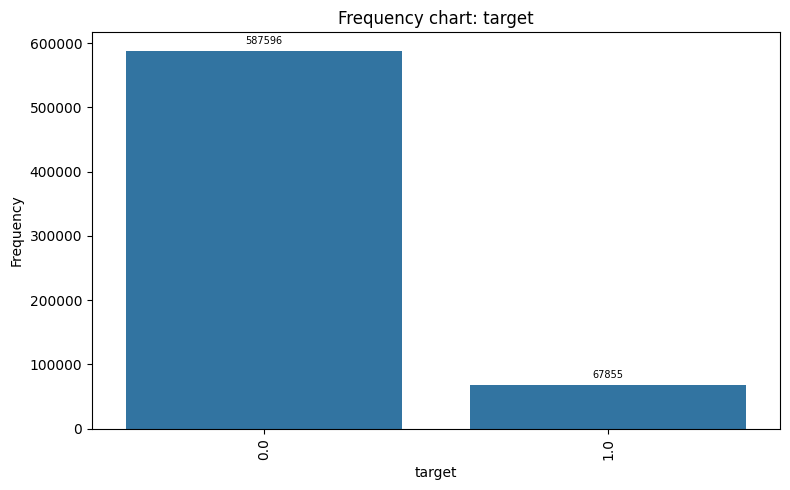

In [27]:
univariate_categorical_variable(df, 'target')

In [28]:
# target rate per period
dfG1 = df.groupby('target')[['per_model', 'per_observed', 'per_limbo', 'per_production']].sum().reset_index()
dfG1['total'] = dfG1[['per_model', 'per_observed', 'per_limbo', 'per_production']].sum(axis=1)

col_totals = dfG1[['per_model', 'per_observed', 'per_limbo', 'per_production', 'total']].sum()
target1_pct = (dfG1[dfG1['target'] == 1.0].iloc[0][['per_model', 'per_observed', 'per_limbo', 'per_production', 'total']] / col_totals * 100).round(1)

dfG1_f = pd.concat([
    dfG1,
    pd.DataFrame([col_totals], index=['COLUMN_TOTAL']),
    pd.DataFrame([target1_pct], index=['% target=1 of total'])
])

dfG1_f

,target,per_model,per_observed,per_limbo,per_production,total
0,0.0,159964.0,156112.0,25391.0,246129.0,587596.0
1,1.0,22096.0,25346.0,4931.0,15482.0,67855.0
COLUMN_TOTAL,NaN,182060.0,181458.0,30322.0,261611.0,655451.0
% target=1 of total,NaN,12.1,14.0,16.3,5.9,10.4


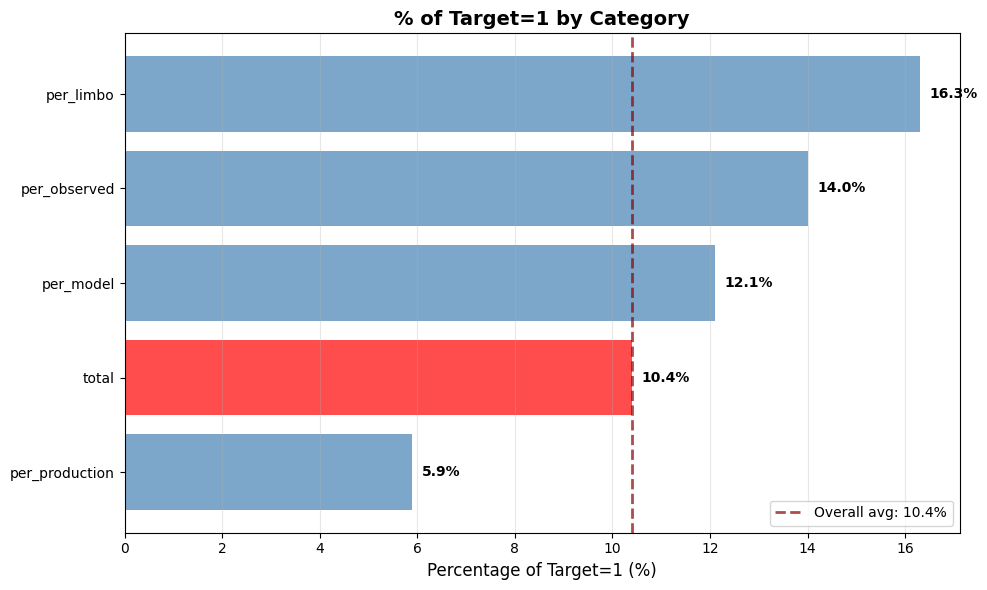

In [29]:
pct_row = dfG1_f.iloc[-1] 

# Create a DataFrame for plotting
pct_data = pd.DataFrame({
    'Category': ['per_model', 'per_observed', 'per_limbo', 'per_production', 'total'],
    'Percentage': [pct_row['per_model'], pct_row['per_observed'], 
                   pct_row['per_limbo'], pct_row['per_production'], pct_row['total']]
})

# Get overall average (total column)
overall_avg = pct_row['total']

# Sort by percentage for better visualization
pct_data = pct_data.sort_values('Percentage', ascending=True)

# Create horizontal bar chart
plt.figure(figsize=(10, 6))
bars = plt.barh(pct_data['Category'], pct_data['Percentage'], 
                color=['steelblue' if cat != 'total' else 'red' for cat in pct_data['Category']], 
                alpha=0.7)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, pct_data['Percentage'])):
    plt.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val}%', 
             va='center', fontweight='bold')

# Add vertical line for overall average
plt.axvline(x=overall_avg, color='darkred', linestyle='--', alpha=0.7, 
            linewidth=2, label=f'Overall avg: {overall_avg}%')

plt.xlabel('Percentage of Target=1 (%)', fontsize=12)
plt.title('% of Target=1 by Category', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

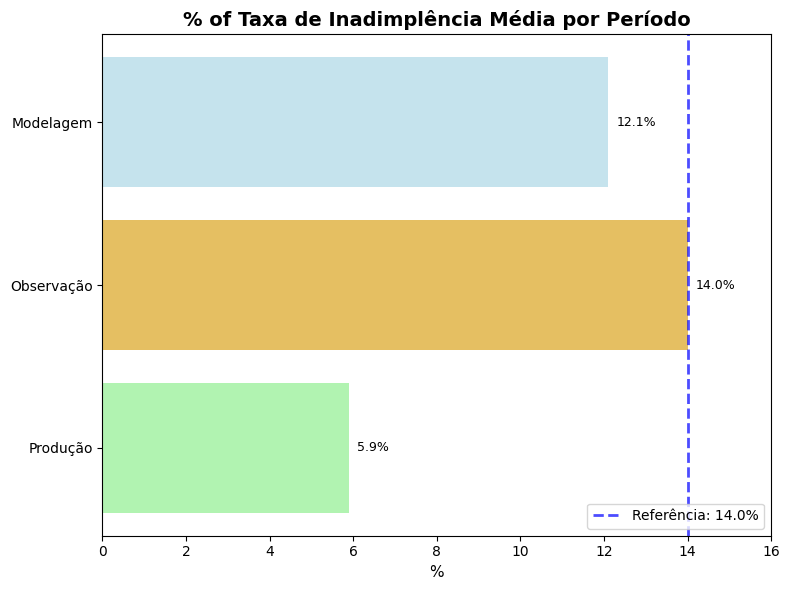

In [30]:
pct_row = dfG1_f.iloc[-1]  

# Create DataFrame with only the categories you want, in your specified order
categories = ['per_model', 'per_observed', 'per_production']
colors = ['lightblue', 'goldenrod', 'lightgreen']

# Create DataFrame with renamed categories
pct_data = pd.DataFrame({
    'Original_Category': categories,
    'Category': [category_mapping[cat] for cat in categories],
    'Percentage': [pct_row['per_model'], pct_row['per_observed'], pct_row['per_production']]
})

# Get per_model value for reference line
reference_line = pct_row['per_observed']

# Reverse the order for the plot
pct_data_reversed = pct_data.iloc[::-1].reset_index(drop=True)
colors_reversed = colors[::-1]

# Create horizontal bar chart
plt.figure(figsize=(8, 6))
bars = plt.barh(pct_data_reversed['Category'], pct_data_reversed['Percentage'], 
                color=colors_reversed, alpha=0.7)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, pct_data_reversed['Percentage'])):
    plt.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val}%', 
             va='center', fontweight='normal', fontsize=9)

# Add vertical line for reference
plt.axvline(x=reference_line, color='blue', linestyle='--', alpha=0.7, 
            linewidth=2, label=f'Referência: {reference_line}%')

plt.xlim(0, 16)
plt.xlabel('%', fontsize=11)
plt.title('% of Taxa de Inadimplência Média por Período', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
# plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

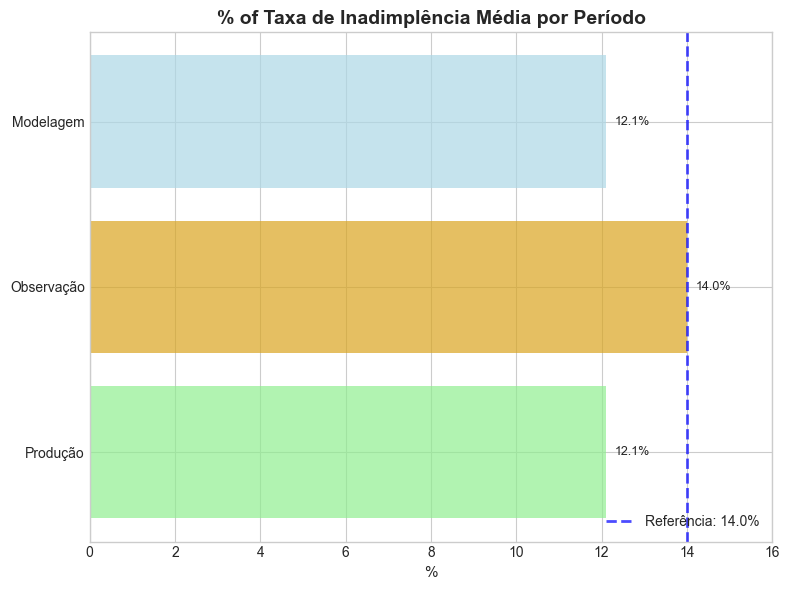

In [138]:
# target rate per period
df_fTnull = df[df['ano_mes'] < 202501]
dfG1c = df_fTnull.groupby('target')[['per_model', 'per_observed', 'per_limbo', 'per_production']].sum().reset_index()
dfG1c['total'] = dfG1c[['per_model', 'per_observed', 'per_limbo', 'per_production']].sum(axis=1)

col_totals = dfG1c[['per_model', 'per_observed', 'per_limbo', 'per_production', 'total']].sum()
target1_pct = (dfG1c[dfG1c['target'] == 1.0].iloc[0][['per_model', 'per_observed', 'per_limbo', 'per_production', 'total']] / col_totals * 100).round(1)

dfG1c_f = pd.concat([
    dfG1,
    pd.DataFrame([col_totals], index=['COLUMN_TOTAL']),
    pd.DataFrame([target1_pct], index=['% target=1 of total'])
])

dfG1c_f


pct_datac = dfG1c_f.iloc[-1]  

# Create DataFrame with only the categories you want, in your specified order
categories = ['per_model', 'per_observed', 'per_production']
colors = ['lightblue', 'goldenrod', 'lightgreen']

# Create DataFrame with renamed categories
pct_datac = pd.DataFrame({
    'Original_Category': categories,
    'Category': [category_mapping[cat] for cat in categories],
    'Percentage': [pct_datac['per_model'], pct_datac['per_observed'], pct_datac['per_production']]
})

# Get per_model value for reference line
# reference_line = pct_datac['per_observed']

# Reverse the order for the plot
pct_data_reversedc = pct_datac.iloc[::-1].reset_index(drop=True)
colors_reversed = colors[::-1]

# Create horizontal bar chart
plt.figure(figsize=(8, 6))
bars = plt.barh(pct_data_reversedc['Category'], pct_data_reversedc['Percentage'], 
                color=colors_reversed, alpha=0.7)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, pct_data_reversedc['Percentage'])):
    plt.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val}%', 
             va='center', fontweight='normal', fontsize=9)

# Add vertical line for reference
plt.axvline(x=reference_line, color='blue', linestyle='--', alpha=0.7, linewidth=2, label=f'Referência: {reference_line}%')

plt.xlim(0, 16)
plt.xlabel('%', fontsize=11)
plt.title('% of Taxa de Inadimplência Média por Período', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
# plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [126]:
df_fTnull

,id,ano_mes,idade_veiculo,marca,vl_bem,idade,estado_civil,qt_restr,renda,Regiao,Profissao,entrada,prazo,pmt,target,FPD,score,contratado,comp_renda,tt_financiado_com_juros,valor_min,valor_max,valor_medio_fx,idade_media_veiculo,vl_medio_por_idade_media_veiculo,vl_a_pagar_por_idade_media_veiculo,nacionalidade,id_duplicado,flg_restr,per_model,per_observed,per_limbo,per_production,per_observed2,target_categoria,FPD_categoria,periodo,ano_mes_dt,mes_ano,mes_num,ano,mes_nome
518067,285474243,202203,10,Ford,(0;25000],32,divorciado,0,24251,CO,autonomos,40,24,674,1.0,0.0,6,1,0.027793,16176,0,25000,12500.0,10.0,1250.000000,1617.6,Estados Unidos,False,0,1,0,0,0,0,1.0,0.0,Modelagem (Mar/22-Fev/23),2022-03-01,2022-03,3,2022,Mar
432751,753010996,202203,6_10,VW,(25000;70000],53,divorciado,2,18422,CO,prof_serv,0,36,2209,0.0,0.0,3,1,0.119911,79524,25000,70000,47500.0,8.0,5937.500000,9940.5,Alemanha,False,1,1,0,0,0,0,0.0,0.0,Modelagem (Mar/22-Fev/23),2022-03-01,2022-03,3,2022,Mar
533179,949022361,202203,1_2,Honda,(25000;70000],35,divorciado,0,24557,SE,prof_serv,10,48,845,0.0,0.0,8,1,0.034410,40560,25000,70000,47500.0,1.5,31666.666667,27040.0,Japão,False,0,1,0,0,0,0,0.0,0.0,Modelagem (Mar/22-Fev/23),2022-03-01,2022-03,3,2022,Mar
592407,440126628,202203,1_2,VW,(25000;70000],39,solteiro,>2,24423,CO,prof_serv,40,36,685,0.0,0.0,7,1,0.028047,24660,25000,70000,47500.0,1.5,31666.666667,16440.0,Alemanha,False,1,1,0,0,0,0,0.0,0.0,Modelagem (Mar/22-Fev/23),2022-03-01,2022-03,3,2022,Mar
533176,318448632,202203,1_2,VW,(25000;70000],45,casado,0,3445,SE,prof_serv,20,48,857,0.0,0.0,7,1,0.248766,41136,25000,70000,47500.0,1.5,31666.666667,27424.0,Alemanha,False,0,1,0,0,0,0,0.0,0.0,Modelagem (Mar/22-Fev/23),2022-03-01,2022-03,3,2022,Mar
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
794009,275394880,202512,6_10,Peugeot,(25000;70000],33,casado,0,4582,NE,assalariados,10,36,961,0.0,0.0,6,1,0.209734,34596,25000,70000,47500.0,8.0,5937.500000,4324.5,França,False,0,0,0,0,1,0,0.0,0.0,Produção (Mai/24 em diante),2025-12-01,2025-12,12,2025,Dec
803395,542004964,202512,1_2,VW,(25000;70000],36,casado,2,5163,SE,assalariados,50,36,744,0.0,0.0,8,1,0.144102,26784,25000,70000,47500.0,1.5,31666.666667,17856.0,Alemanha,False,1,0,0,0,1,0,0.0,0.0,Produção (Mai/24 em diante),2025-12-01,2025-12,12,2025,Dec
794005,893658723,202512,1_2,VW,(25000;70000],42,viuvo,0,4228,CO,empresarios,50,48,534,0.0,0.0,9,1,0.126301,25632,25000,70000,47500.0,1.5,31666.666667,17088.0,Alemanha,False,0,0,0,0,1,0,0.0,0.0,Produção (Mai/24 em diante),2025-12-01,2025-12,12,2025,Dec
787671,330700569,202512,0,VW,(25000;70000],44,divorciado,2,10056,SE,prof_serv,40,36,1021,0.0,0.0,8,1,0.101531,36756,25000,70000,47500.0,0.0,0.000000,0.0,Alemanha,False,1,0,0,0,1,0,0.0,0.0,Produção (Mai/24 em diante),2025-12-01,2025-12,12,2025,Dec


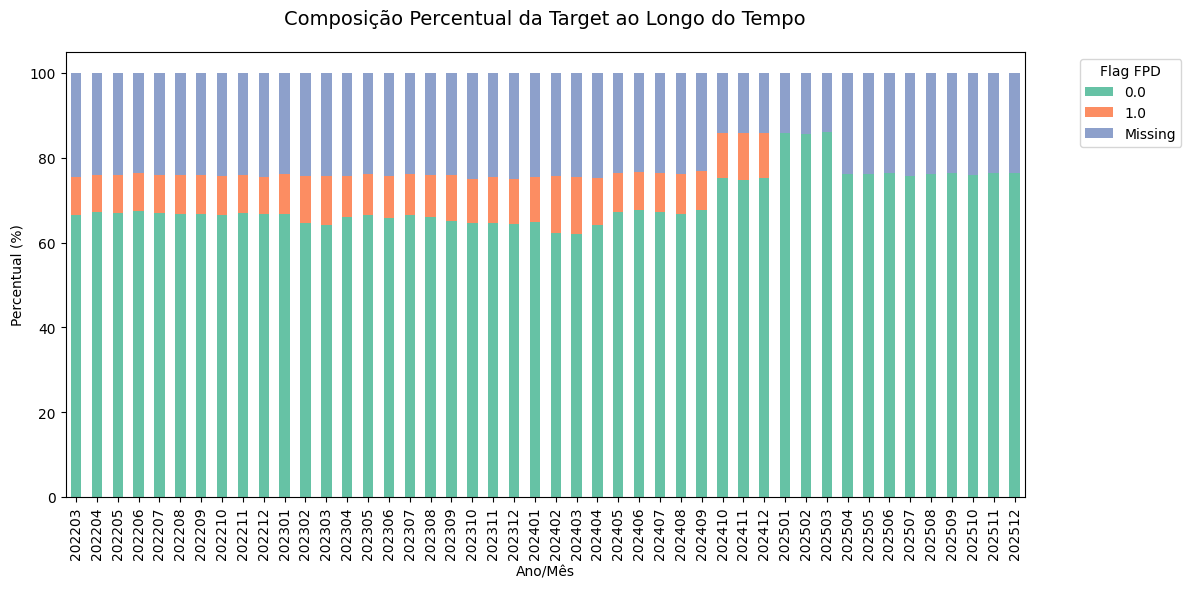

In [31]:
# Primeiro, criar uma cópia da coluna tratando os missing
df['target_categoria'] = df['target'].fillna('Missing').astype(str)

# Agora fazer o groupby com a nova coluna
dfG21 = df.groupby(['ano_mes', 'target_categoria']).size().reset_index(name='contagem')

# Calcular o total de veículos por mês
total_mes = df.groupby('ano_mes').size().reset_index(name='total')

# Juntar os dados e calcular a porcentagem
dfG21 = dfG21.merge(total_mes, on='ano_mes')
dfG21['percentual'] = (dfG21['contagem'] / dfG21['total']) * 100

# Ordenar por ano_mês
dfG21 = dfG21.sort_values('ano_mes')

dfG21

# Opção 2: Gráfico de barras empilhadas (mostra a composição total)
pivot_df = dfG21.pivot(index='ano_mes', columns='target_categoria', values='percentual')

cores_pastel = sns.color_palette("Set2", n_colors=len(pivot_df.columns))

pivot_df.plot(kind='bar', stacked=True, figsize=(12, 6), color=cores_pastel)

plt.title('Composição Percentual da Target ao Longo do Tempo', fontsize=14, pad=20)
plt.xlabel('Ano/Mês')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=90)
plt.legend(title='Flag FPD', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### <span style="color:purple">Nota</span>
- Existe um padrão diferente de comportamento dos contratos aprovados/efetivados ao longo dos períodos.
- No período de produção, parece que só os “bons” passaram, ou novas regras/modelos já estavam influenciando a aprovação.
- Os missings podem estar mascarando o verdadeiro risco da base (se eles não forem aleatórios!).
- Pode indicar “limbo operacional” ou mudança de política de crédito.

### Var: id

- Verificar duplicidade


In [32]:
univariate_missing_analysis(df, 'id')

# missing_var_when_flag_1(df, 'id', flags)

Missing Value Analysis for: id
Category  Count Percentage
 Missing      0      0.00%
 Present 848001    100.00%
   Total 848001       100%


In [33]:
nt = df['id'].size
n1 = df['id'].unique().size

print(f"Quantidade de linhas do dataset: {nt:,} e id únicas: {n1:,}.")

if nt > n1: 
    print(f"Temos {nt - n1:,} ids duplicadas ({(nt - n1) / nt:.2%}).")
elif nt < n1:
    print("Verificar, não posso ter menos linhas no df total!")
else:
    print("Não temos duplicatas")


Quantidade de linhas do dataset: 848,001 e id únicas: 847,654.
Temos 347 ids duplicadas (0.04%).


In [34]:
duplicate_ids = df[df['id_duplicado'] > 0]['id'].unique()
df[df['id_duplicado'] > 0]


,id,ano_mes,idade_veiculo,marca,vl_bem,idade,estado_civil,qt_restr,renda,Regiao,...,vl_a_pagar_por_idade_media_veiculo,nacionalidade,id_duplicado,flg_restr,per_model,per_observed,per_limbo,per_production,per_observed2,target_categoria
42355,516245139,202303,3_5,Fiat,(25000;70000],55,divorciado,>2,3136,CO,...,12339.0,Itália,True,1,0,1,0,0,1,Missing
48659,345653773,202302,10,Fiat,(25000;70000],45,divorciado,0,11070,CO,...,4003.2,Itália,True,0,1,0,0,0,0,Missing
49083,542049103,202303,0,Jac,(25000;70000],45,casado,0,5565,CO,...,0.0,China,True,0,0,1,0,0,1,0.0
61685,971072837,202305,0,Chevrolet,(0;25000],49,divorciado,>2,5840,N,...,0.0,Estados Unidos,True,1,0,1,0,0,1,Missing
63126,179799321,202308,10,Peugeot,(25000;70000],48,casado,0,19766,CO,...,5630.4,França,True,0,0,1,0,0,1,Missing
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
835886,443168779,202506,3_5,Chevrolet,(25000;70000],38,viuvo,0,3029,SE,...,10416.0,Estados Unidos,True,0,0,0,0,1,0,0.0
836553,783157578,202505,3_5,Outros,(0;25000],18,casado,1,10862,SE,...,4635.0,Outros,True,1,0,0,0,1,0,0.0
838400,817818488,202509,3_5,VW,(25000;70000],47,divorciado,>2,4433,N,...,17919.0,Alemanha,True,1,0,0,0,1,0,Missing
841736,958892383,202505,1_2,Fiat,(25000;70000],44,casado,0,3391,S,...,30456.0,Itália,True,0,0,0,0,1,0,0.0


In [35]:
# Check dispersion of duplicated ids in the periods
dfG2 = df[df['id'].isin(duplicate_ids)].groupby('id')[['per_model', 'per_observed', 'per_limbo', 'per_production']].sum().reset_index()
dfG2['total'] = dfG2[['per_model', 'per_observed', 'per_limbo', 'per_production']].sum(axis=1)
dfG2.sort_values('total',ascending=False)

,id,per_model,per_observed,per_limbo,per_production,total
0,103598196,0,0,1,1,2
1,103684955,1,1,0,0,2
2,106345375,1,0,0,1,2
3,109646943,1,1,0,0,2
4,122606377,0,1,0,1,2
...,...,...,...,...,...,...
342,975862373,1,1,0,0,2
343,981423262,2,0,0,0,2
344,991741927,1,0,0,1,2
345,995091442,0,2,0,0,2


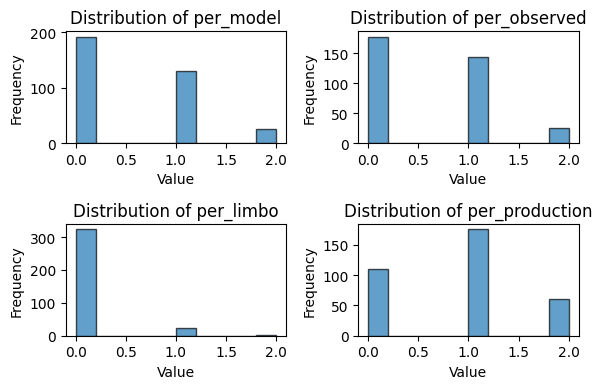

In [36]:
# Create separate histograms for each metric
fig, axes = plt.subplots(2, 2, figsize=(6, 4))
metrics = ['per_model', 'per_observed', 'per_limbo', 'per_production']

for ax, metric in zip(axes.flat, metrics):
    dfG2[metric].plot(kind='hist', ax=ax, bins=10, edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribution of {metric}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [37]:
flags = ['per_model', 'per_observed', 'per_limbo', 'per_production']

# Initialize matrix
cooccurrence = pd.DataFrame(0, index=flags, columns=flags)

# Calculate correctly based on the values
for idx, row in dfG2.iterrows():
    for i, cat_i in enumerate(flags):
        val_i = row[cat_i]
        
        if val_i == 2:
            # Both duplicates in this category
            cooccurrence.loc[cat_i, cat_i] += 1  # Add 1 ID to diagonal
        elif val_i == 1:
            # One duplicate in this category
            # Find which other category has the other duplicate (value=1)
            for cat_j in flags:
                if cat_j != cat_i and row[cat_j] == 1:
                    # This ID has one duplicate in cat_i and one in cat_j
                    cooccurrence.loc[cat_i, cat_j] += 1
                    # Don't double count - we'll handle symmetry

# Make matrix symmetric
for i in flags:
    for j in flags:
        if i != j:
            # Average or take max to ensure symmetry
            cooccurrence.loc[i, j] = max(cooccurrence.loc[i, j], cooccurrence.loc[j, i])
            cooccurrence.loc[j, i] = cooccurrence.loc[i, j]

# Calculate totals (sum of values/2 since each ID contributes 2 total)
totals = dfG2[flags].sum() / 2  # Divide by 2 because each ID contributes 2 to total sum

print("Co-occurrence Matrix (Number of IDs):")
print(cooccurrence)
print("\nTotals per category (number of IDs with at least one duplicate in this category):")
print(totals)
print(f"\nTotal unique IDs: {len(dfG2)}")


Co-occurrence Matrix (Number of IDs):
                per_model  per_observed  per_limbo  per_production
per_model              25            47          8              75
per_observed           47            25          5              92
per_limbo               8             5          1               9
per_production         75            92          9              60

Totals per category (number of IDs with at least one duplicate in this category):
per_model          90.0
per_observed       97.0
per_limbo          12.0
per_production    148.0
dtype: float64

Total unique IDs: 347


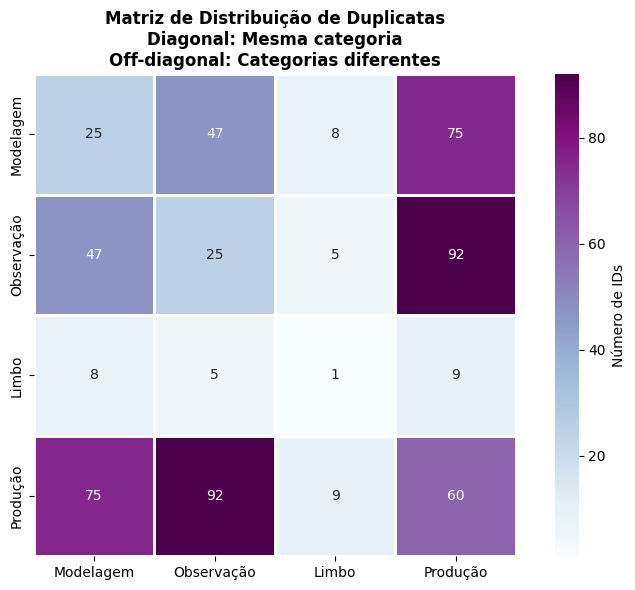

In [38]:
cooccurrence2 = cooccurrence.rename(columns=category_mapping, index=category_mapping)

# Create heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(cooccurrence2, 
            annot=True,           
            fmt='.0f',            
            cmap='BuPu',        
            square=True,          
            linewidths=1,         
            linecolor='white',    
            cbar_kws={'label': 'Número de IDs'})

plt.title('Matriz de Distribuição de Duplicatas\nDiagonal: Mesma categoria\nOff-diagonal: Categorias diferentes', 
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()



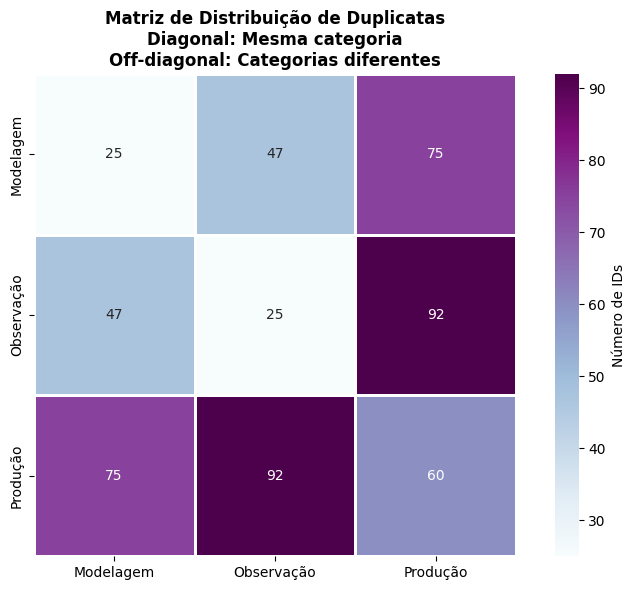

In [39]:
cooccurrence3 = cooccurrence2.drop('Limbo', axis=0).drop('Limbo', axis=1)

# Create heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(cooccurrence3, 
            annot=True,           
            fmt='.0f',            
            cmap='BuPu',        
            square=True,          
            linewidths=1,         
            linecolor='white',    
            cbar_kws={'label': 'Número de IDs'})

plt.title('Matriz de Distribuição de Duplicatas\nDiagonal: Mesma categoria\nOff-diagonal: Categorias diferentes', 
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [40]:
# Check dispersion of duplicated ids in the periods
dfG2a = df[df['id'].isin(duplicate_ids)].groupby('id')[['per_model', 'per_observed2', 'per_production']].sum().reset_index()
dfG2a['total'] = dfG2a[['per_model', 'per_observed2', 'per_production']].sum(axis=1)
dfG2a.sort_values('total',ascending=False)

# Initialize matrix
cooccurrence4 = pd.DataFrame(0, index=flags2, columns=flags2)

# Calculate correctly based on the values
for idx, row in dfG2a.iterrows():
    for i, cat_i in enumerate(flags2):
        val_i = row[cat_i]
        
        if val_i == 2:
            # Both duplicates in this category
            cooccurrence4.loc[cat_i, cat_i] += 1  # Add 1 ID to diagonal
        elif val_i == 1:
            # One duplicate in this category
            # Find which other category has the other duplicate (value=1)
            for cat_j in flags2:
                if cat_j != cat_i and row[cat_j] == 1:
                    # This ID has one duplicate in cat_i and one in cat_j
                    cooccurrence4.loc[cat_i, cat_j] += 1
                    # Don't double count - we'll handle symmetry

# Make matrix symmetric
for i in flags2:
    for j in flags2:
        if i != j:
            # Average or take max to ensure symmetry
            cooccurrence4.loc[i, j] = max(cooccurrence4.loc[i, j], cooccurrence4.loc[j, i])
            cooccurrence4.loc[j, i] = cooccurrence4.loc[i, j]

# Calculate totals (sum of values/2 since each ID contributes 2 total)
totals = dfG2a[flags2].sum() / 2  # Divide by 2 because each ID contributes 2 to total sum

print("Co-occurrence Matrix (Number of IDs):")
print(cooccurrence4)
print("\nTotals per category (number of IDs with at least one duplicate in this category):")
print(totals)
print(f"\nTotal unique IDs: {len(dfG2a)}")


Co-occurrence Matrix (Number of IDs):
                per_model  per_observed2  per_production
per_model              25             55              75
per_observed2          55             31             101
per_production         75            101              60

Totals per category (number of IDs with at least one duplicate in this category):
per_model          90.0
per_observed2     109.0
per_production    148.0
dtype: float64

Total unique IDs: 347


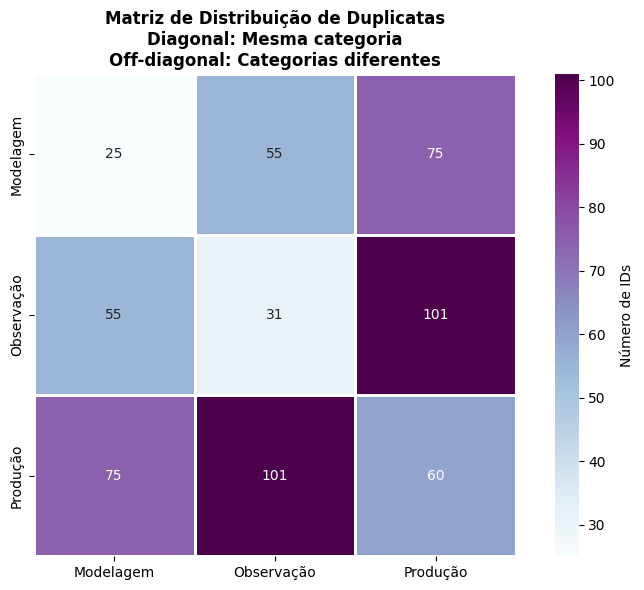

In [41]:
cooccurrence4a = cooccurrence4.rename(columns=category_mapping2, index=category_mapping2)

# Create heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(cooccurrence4a, 
            annot=True,           
            fmt='.0f',            
            cmap='BuPu',        
            square=True,          
            linewidths=1,         
            linecolor='white',    
            cbar_kws={'label': 'Número de IDs'})

plt.title('Matriz de Distribuição de Duplicatas\nDiagonal: Mesma categoria\nOff-diagonal: Categorias diferentes', 
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


#### <span style="color:purple">Nota</span>
**Surpresa**: Esperávamos que o id fosse único, mas encontramos duplicidades.\
**Impacto**: Isso pode indicar inconsistências nos registros, históricos não tratados ou até problemas operacionais que afetam indicadores de inadimplência e a precisão do modelo.

<br>

**Qualidade dos dados**: É preciso investigar: são versões diferentes da mesma proposta? Erro de extração?\
**Ação recomendada**: Corrigir/ajustar esse ponto antes de prosseguir para evitar viés no modelo.\
**Lição para o negócio**: Processos de cadastro ou atualização de propostas precisam ser revisados para garantir integridade da base.



Alguns Exemplos:

In [42]:
df[df['id'] == 103598196]

,id,ano_mes,idade_veiculo,marca,vl_bem,idade,estado_civil,qt_restr,renda,Regiao,...,vl_a_pagar_por_idade_media_veiculo,nacionalidade,id_duplicado,flg_restr,per_model,per_observed,per_limbo,per_production,per_observed2,target_categoria
281676,103598196,202403,3_5,Ford,(25000;70000],35,solteiro,2,3606,NE,...,17613.0,Estados Unidos,False,1,0,0,1,0,1,Missing
383381,103598196,202407,10,Fiat,(25000;70000],43,casado,0,27567,N,...,5246.4,Itália,True,0,0,0,0,1,0,0.0


In [43]:
df[df['id'] == 124712059]

,id,ano_mes,idade_veiculo,marca,vl_bem,idade,estado_civil,qt_restr,renda,Regiao,...,vl_a_pagar_por_idade_media_veiculo,nacionalidade,id_duplicado,flg_restr,per_model,per_observed,per_limbo,per_production,per_observed2,target_categoria
338729,124712059,202406,0,VW,(70000;999999],37,solteiro,>2,26194,CO,...,0.0,Alemanha,False,1,0,0,0,1,0,0.0
368647,124712059,202408,1_2,Outros,(0;25000],52,divorciado,0,27430,SE,...,20480.0,Outros,True,0,0,0,0,1,0,0.0


### Var: `idade_veiculo`

In [44]:
univariate_missing_analysis(df, 'idade_veiculo')

# missing_var_when_flag_1(df, 'idade_veiculo', flags)

Missing Value Analysis for: idade_veiculo
Category  Count Percentage
 Missing      0      0.00%
 Present 848001    100.00%
   Total 848001       100%


Categorical variable describe:


,count,unique,top,freq
idade_veiculo,848001,5,1_2,253868


Frequency table of categorical variable (with percentage and total):


,idade_veiculo,Frequency,Percentage (%)
0,1_2,253868,29.94
1,3_5,212151,25.02
2,10,169586,20.00
3,6_10,127874,15.08
4,0,84522,9.97
5,Total,848001,100.00


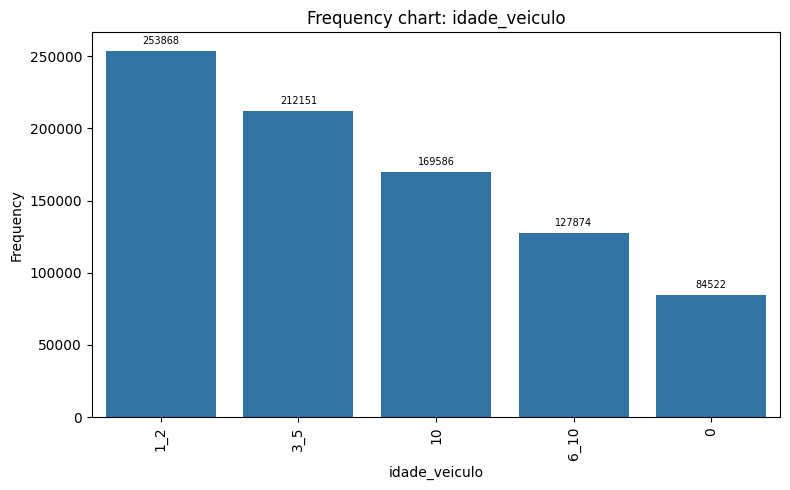

In [45]:
univariate_categorical_variable(df, 'idade_veiculo')

In [46]:
# Per period
dfG3 = df.groupby('idade_veiculo')[['per_model', 'per_observed', 'per_limbo', 'per_production']].sum().reset_index()
dfG3['total'] = dfG3[['per_model', 'per_observed', 'per_limbo', 'per_production']].sum(axis=1)

col_totals = dfG3[['per_model', 'per_observed', 'per_limbo', 'per_production', 'total']].sum()
idade_vei_0 = (dfG3.loc[0] / col_totals * 100).astype(float).round(1)
idade_vei_1 = (dfG3.loc[1] / col_totals * 100).astype(float).round(1)
idade_vei_2 = (dfG3.loc[2] / col_totals * 100).astype(float).round(1)
idade_vei_3 = (dfG3.loc[3] / col_totals * 100).astype(float).round(1)
idade_vei_4 = (dfG3.loc[4] / col_totals * 100).astype(float).round(1)

dfG3_f = pd.concat([
    dfG3,
    pd.DataFrame([col_totals], index=['COLUMN_TOTAL']),
    pd.DataFrame([idade_vei_0], index=['pct_0']),
    pd.DataFrame([idade_vei_1], index=['pct_10']),
    pd.DataFrame([idade_vei_2], index=['pct_1_2']),
    pd.DataFrame([idade_vei_3], index=['pct_3_5']),
    pd.DataFrame([idade_vei_4], index=['pct_6_10']),

])

dfG3_f

,idade_veiculo,per_model,per_observed,per_limbo,per_production,total
0,0,23714.0,23947.0,4012.0,32849.0,84522.0
1,10,48142.0,48157.0,7940.0,65347.0,169586.0
2,1_2,72192.0,71599.0,11952.0,98125.0,253868.0
3,3_5,59658.0,60059.0,10166.0,82268.0,212151.0
4,6_10,36183.0,36178.0,6167.0,49346.0,127874.0
COLUMN_TOTAL,NaN,239889.0,239940.0,40237.0,327935.0,848001.0
pct_0,NaN,9.9,10.0,10.0,10.0,10.0
pct_10,NaN,20.1,20.1,19.7,19.9,20.0
pct_1_2,NaN,30.1,29.8,29.7,29.9,29.9
pct_3_5,NaN,24.9,25.0,25.3,25.1,25.0


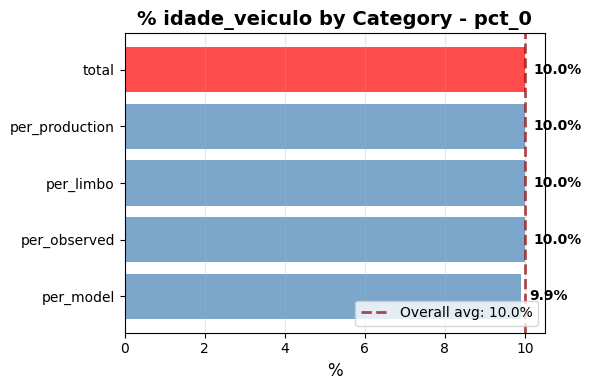

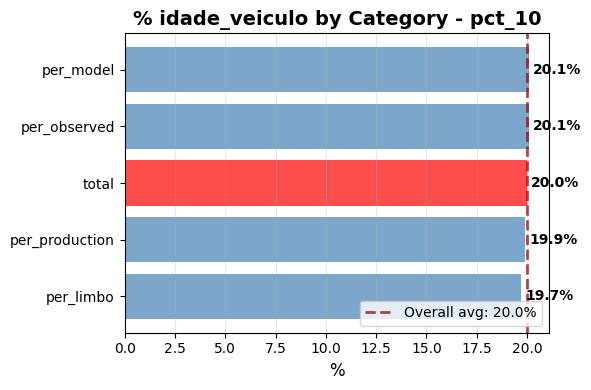

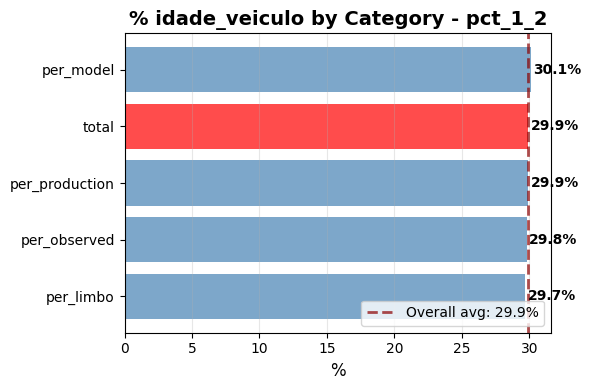

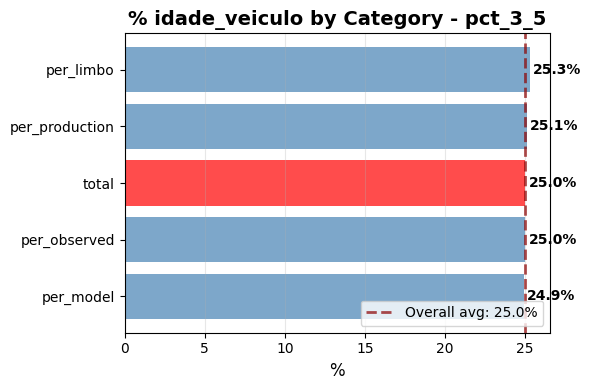

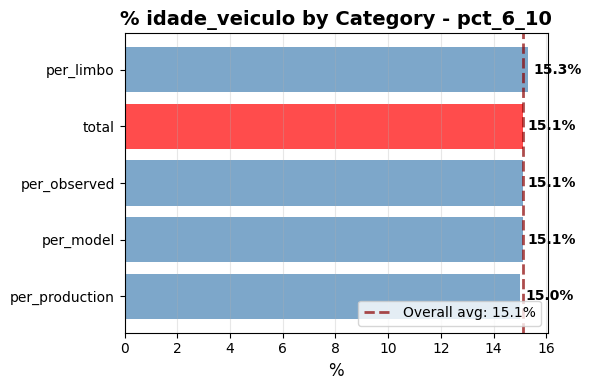

In [47]:

t1 = ['pct_0', 'pct_10', 'pct_1_2', 'pct_3_5', 'pct_6_10']

# Loop through each variable in t1
for period in t1:
    # 1. Extract the specific row for this period
    # Using .loc ensures we grab the row by its index name
    pct_row = dfG3_f.loc[period]

    # 2. Prepare data for plotting
    categories = ['per_model', 'per_observed', 'per_limbo', 'per_production', 'total']
    pct_data = pd.DataFrame({
        'Category': categories,
        'Percentage': [pct_row[cat] for cat in categories]
    })

    overall_avg = pct_row['total']
    pct_data = pct_data.sort_values('Percentage', ascending=True)

    # 3. Create the chart
    plt.figure(figsize=(6, 4))
    colors = ['steelblue' if cat != 'total' else 'red' for cat in pct_data['Category']]
    bars = plt.barh(pct_data['Category'], pct_data['Percentage'], color=colors, alpha=0.7)

    # Add value labels
    for bar, val in zip(bars, pct_data['Percentage']):
        plt.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val}%', 
                 va='center', fontweight='bold')

    # Add vertical line for overall average
    plt.axvline(x=overall_avg, color='darkred', linestyle='--', alpha=0.7, 
                linewidth=2, label=f'Overall avg: {overall_avg}%')

    # Customise titles and labels based on the current period
    plt.xlabel('%', fontsize=12)
    plt.title(f'% idade_veiculo by Category - {period}', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    
    # Display the chart for this iteration
    plt.show()

#### <span style="color:purple">Nota</span>
- Distribuição razoavel entre as categorias, onde grande parte dos financiamentos estão em veículos com 1 ou 2 anos.


### Var: `marca`

In [48]:
univariate_missing_analysis(df, 'marca')

# missing_var_when_flag_1(df, 'marca', flags)

Missing Value Analysis for: marca
Category  Count Percentage
 Missing      0      0.00%
 Present 848001    100.00%
   Total 848001       100%


Categorical variable describe:


,count,unique,top,freq
marca,848001,11,VW,150757


Frequency table of categorical variable (with percentage and total):


,marca,Frequency,Percentage (%)
0,VW,150757,17.78
1,Outros,147694,17.42
2,Fiat,134314,15.84
3,Ford,101177,11.93
4,Honda,83847,9.89
5,Chevrolet,67441,7.95
6,Toyota,50529,5.96
7,Peugeot,50504,5.96
8,Hyundai,46743,5.51
9,Nissan,7531,0.89


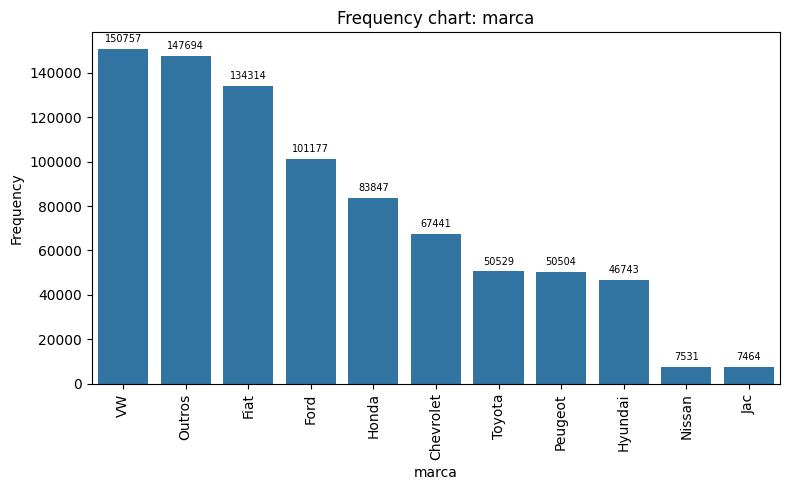

In [49]:
univariate_categorical_variable(df, 'marca')

In [50]:
# Per period
dfG4 = df.groupby('marca')[['per_model', 'per_observed', 'per_limbo', 'per_production']].sum().reset_index()
dfG4['total'] = dfG4[['per_model', 'per_observed', 'per_limbo', 'per_production']].sum(axis=1)

col_totals = dfG4[['per_model', 'per_observed', 'per_limbo', 'per_production', 'total']].sum()

dfG4_f = pd.concat([
    dfG4,
    pd.DataFrame([col_totals], index=['COLUMN_TOTAL']),

])

dfG4_f

,marca,per_model,per_observed,per_limbo,per_production,total
0,Chevrolet,19148,18977,3262,26054,67441
1,Fiat,37853,38293,6396,51772,134314
2,Ford,28435,28523,4824,39395,101177
3,Honda,23725,23810,3939,32373,83847
4,Hyundai,13235,13314,2195,17999,46743
5,Jac,4681,2431,52,300,7464
6,Nissan,4675,2455,45,356,7531
7,Outros,36650,40952,7619,62473,147694
8,Peugeot,14344,14336,2374,19450,50504
9,Toyota,14408,14263,2376,19482,50529


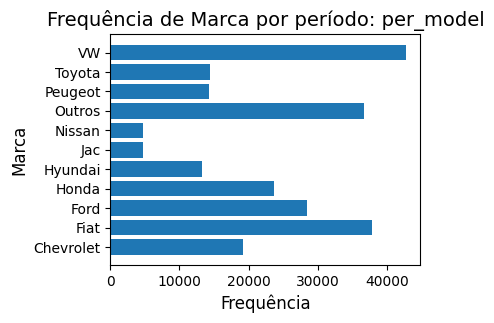

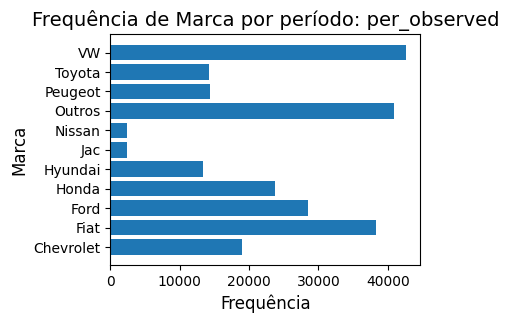

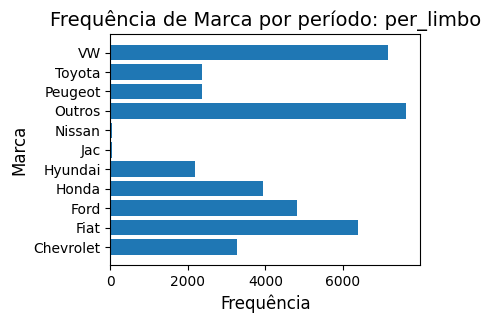

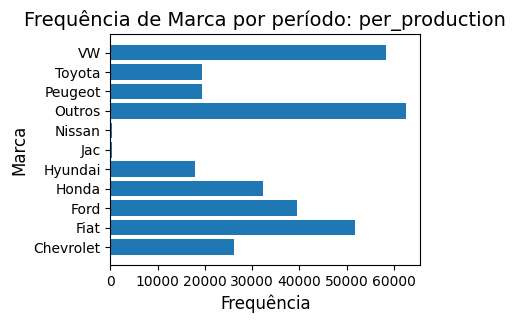

In [51]:
for flag in flags:

    plt.figure(figsize=(4, 3))
    plt.barh(dfG4['marca'].astype(str), dfG4[flag])

    plt.xlabel('Frequência', fontsize=12)
    plt.ylabel('Marca', fontsize=12)
    plt.title(f"Frequência de Marca por período: {flag}", fontsize=14)

    plt.show()

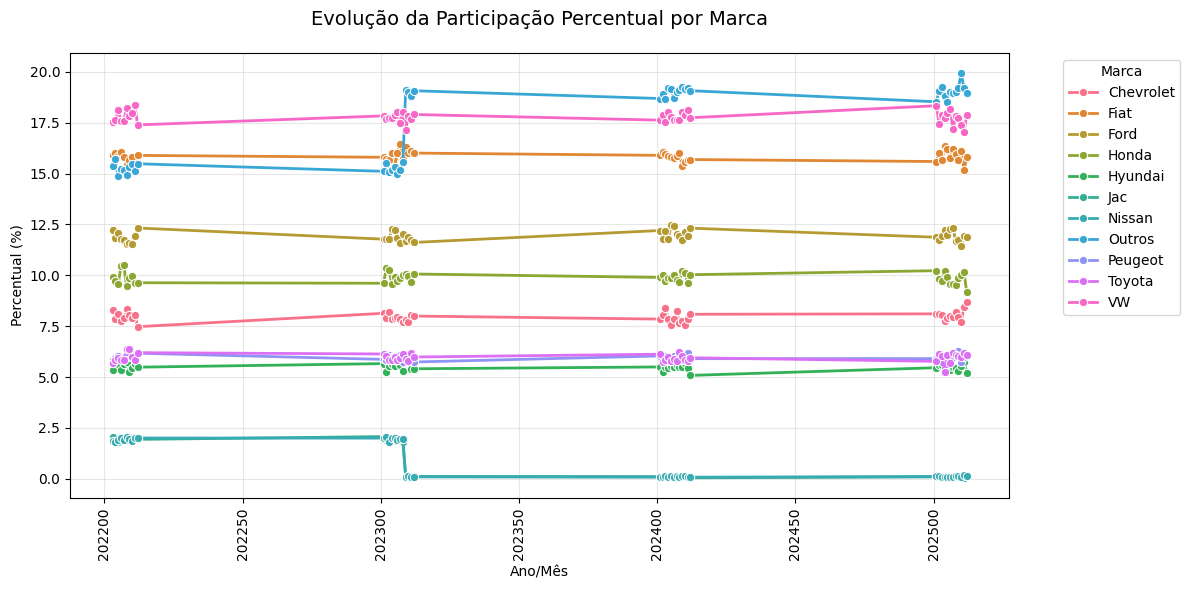

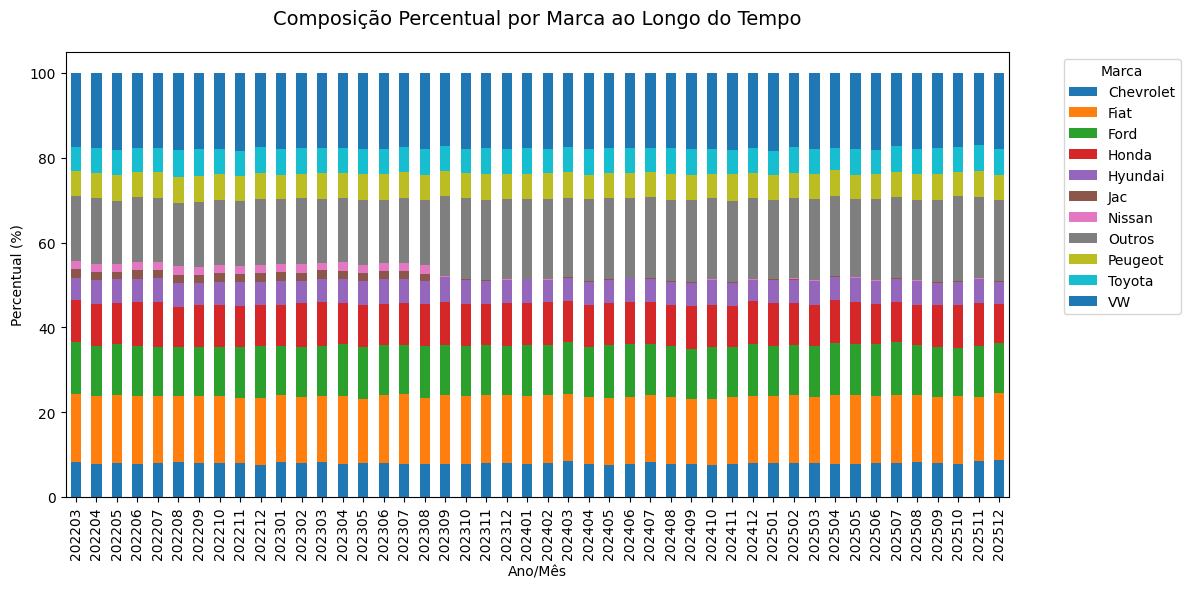

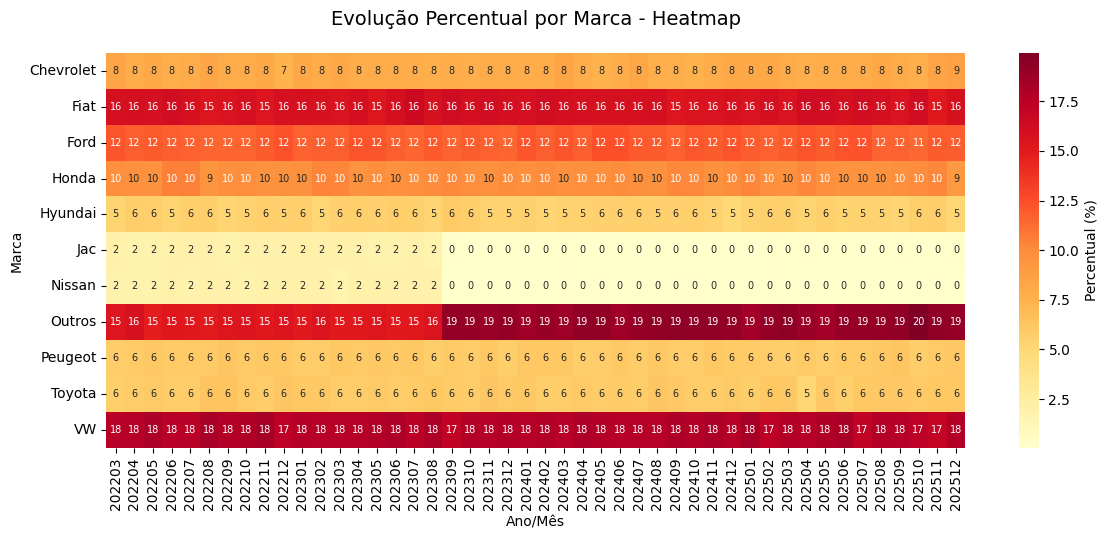

In [52]:
# Preparar os dados
# Calcular a contagem de veículos por mês e marca
marca_mes = df.groupby(['ano_mes', 'marca']).size().reset_index(name='contagem')

# Calcular o total de veículos por mês
total_mes = df.groupby('ano_mes').size().reset_index(name='total')

# Juntar os dados e calcular a porcentagem
marca_mes = marca_mes.merge(total_mes, on='ano_mes')
marca_mes['percentual'] = (marca_mes['contagem'] / marca_mes['total']) * 100

# Ordenar por ano_mês
marca_mes = marca_mes.sort_values('ano_mes')

# Criar o gráfico
plt.figure(figsize=(12, 6))

# Opção 1: Gráfico de linhas (melhor para visualizar tendências)
sns.lineplot(data=marca_mes, x='ano_mes', y='percentual', 
             hue='marca', marker='o', linewidth=2)

plt.title('Evolução da Participação Percentual por Marca', fontsize=14, pad=20)
plt.xlabel('Ano/Mês')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=90)
plt.legend(title='Marca', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Opção 2: Gráfico de barras empilhadas (mostra a composição total)
pivot_df = marca_mes.pivot(index='ano_mes', columns='marca', values='percentual')

pivot_df.plot(kind='bar', stacked=True, figsize=(12, 6))

plt.title('Composição Percentual por Marca ao Longo do Tempo', fontsize=14, pad=20)
plt.xlabel('Ano/Mês')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=90)
plt.legend(title='Marca', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Opção 3: Heatmap da evolução
pivot_heatmap = marca_mes.pivot(index='marca', columns='ano_mes', values='percentual')

plt.figure(figsize=(12, len(pivot_heatmap) * 0.5))
sns.heatmap(pivot_heatmap, annot=True, fmt='.0f', cmap='YlOrRd', 
            cbar_kws={'label': 'Percentual (%)'},
            annot_kws={'size': 7})

plt.title('Evolução Percentual por Marca - Heatmap', fontsize=14, pad=20)
plt.xlabel('Ano/Mês')
plt.ylabel('Marca')
plt.tight_layout()
plt.show()

In [53]:
marca_mes

,ano_mes,marca,contagem,total,percentual
0,202203,Chevrolet,1671,20095,8.315501
1,202203,Fiat,3194,20095,15.894501
2,202203,Ford,2458,20095,12.231898
3,202203,Honda,1990,20095,9.902961
4,202203,Hyundai,1079,20095,5.369495
...,...,...,...,...,...
501,202512,Nissan,14,12070,0.115990
502,202512,Outros,2287,12070,18.947804
503,202512,Peugeot,734,12070,6.081193
504,202512,Toyota,736,12070,6.097763


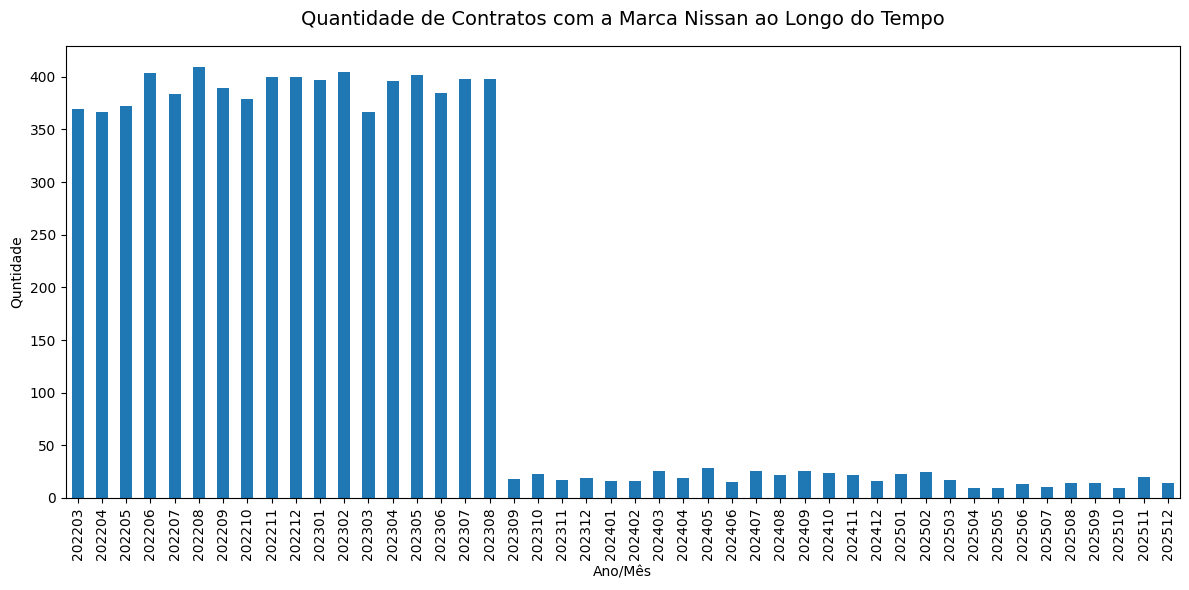

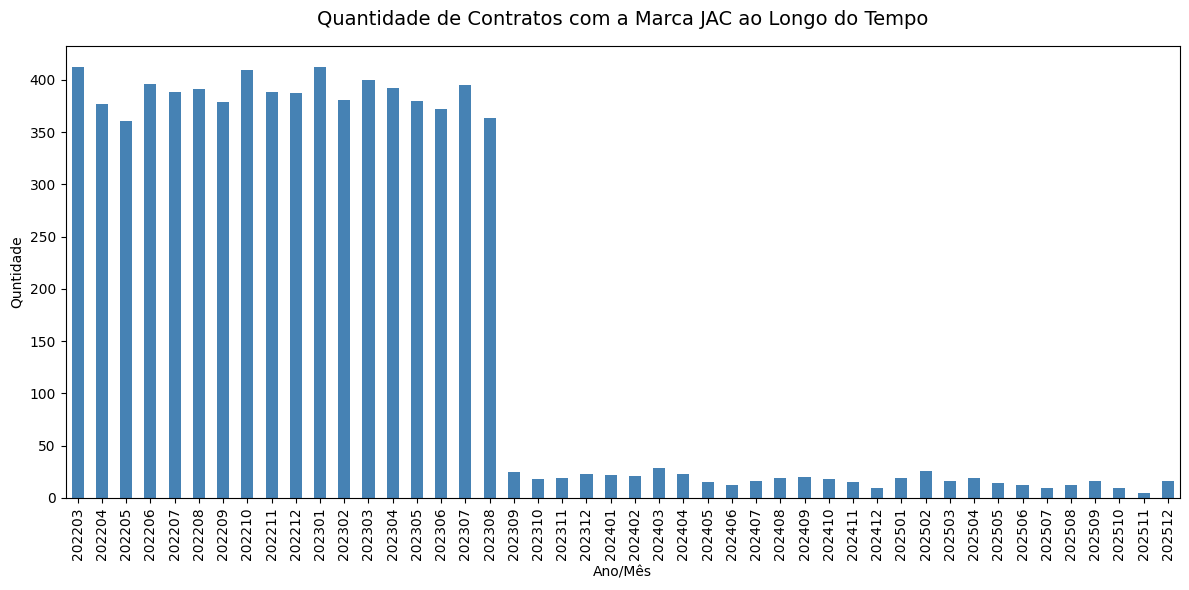

In [54]:
# Nissan & JAC
pivot_df_N = marca_mes[marca_mes['marca'] == 'Nissan']
pivot_df_N.plot(y='contagem', x='ano_mes' , kind='bar', stacked=False, figsize=(12, 6), legend=False)

plt.title('Quantidade de Contratos com a Marca Nissan ao Longo do Tempo', fontsize=14, pad=15)
plt.xlabel('Ano/Mês')
plt.ylabel('Quntidade')
plt.xticks(rotation=90)
# plt.legend(title='Marca', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


pivot_df_J = marca_mes[marca_mes['marca'] == 'Jac']
pivot_df_J.plot(y='contagem', x='ano_mes' , kind='bar', stacked=False, figsize=(12, 6), 
                legend=False, color='steelblue')

plt.title('Quantidade de Contratos com a Marca JAC ao Longo do Tempo', fontsize=14, pad=15)
plt.xlabel('Ano/Mês')
plt.ylabel('Quntidade')
plt.xticks(rotation=90)
# plt.legend(title='Marca', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()




#### <span style="color:purple">Nota</span>
- Redução de Nissan e Jac na base de dados logo após a modelagem

### Var: `vl_bem`

In [55]:
univariate_missing_analysis(df, 'vl_bem')

# missing_var_when_flag_1(df, 'id', flags)

Missing Value Analysis for: vl_bem
Category  Count Percentage
 Missing      0      0.00%
 Present 848001    100.00%
   Total 848001       100%


Categorical variable describe:


,count,unique,top,freq
vl_bem,848001,4,(25000;70000],672748


Frequency table of categorical variable (with percentage and total):


,vl_bem,Frequency,Percentage (%)
0,(25000;70000],672748,79.33
1,(0;25000],169590,20.00
2,(70000;999999],5662,0.67
3,25a70,1,0.00
4,Total,848001,100.00


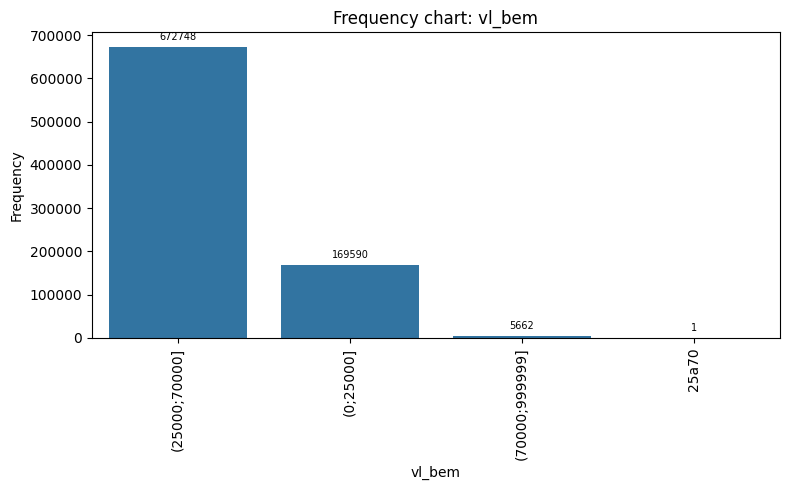

In [56]:
univariate_categorical_variable(df, 'vl_bem')

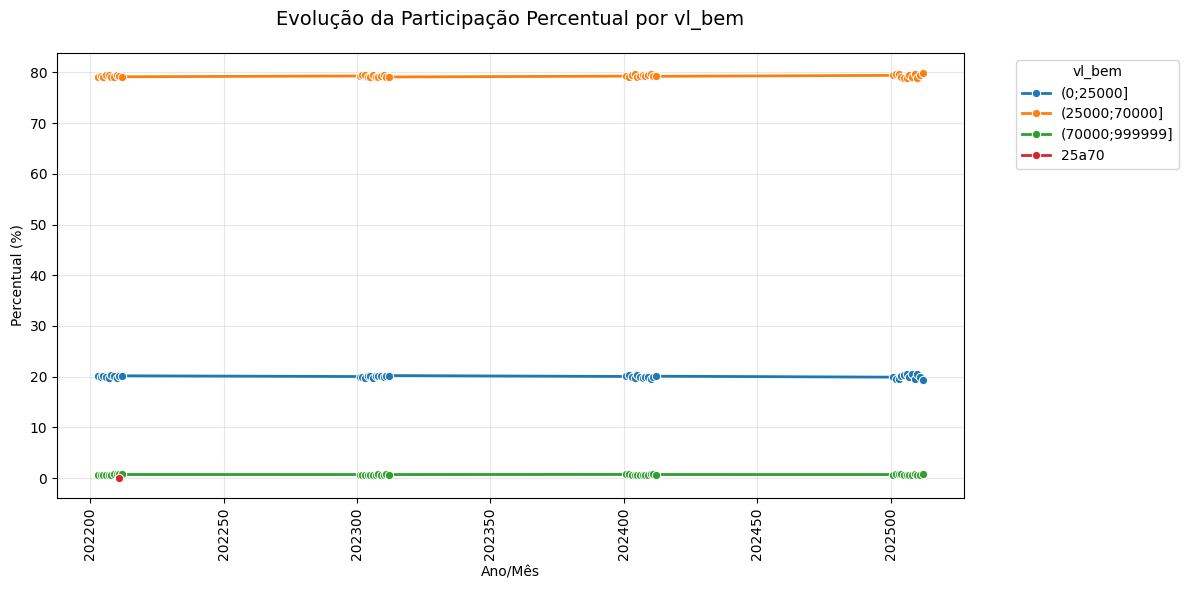

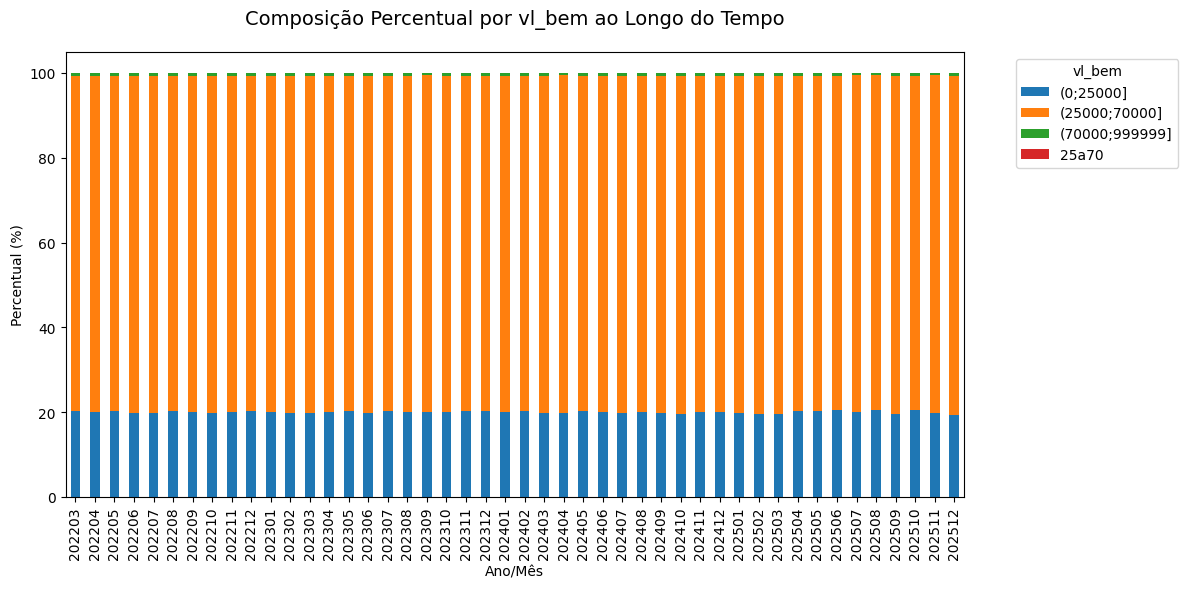

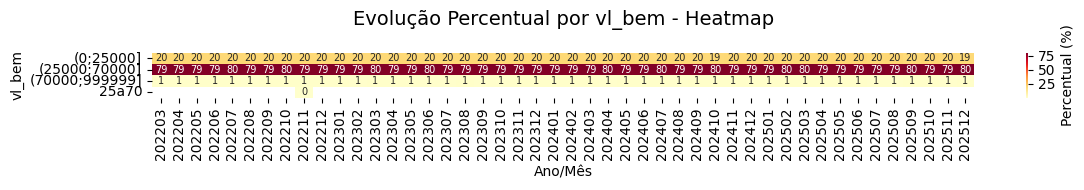

In [57]:
# Preparar os dados
# Calcular a contagem de veículos por mês e vl_bem
vl_bem_mes = df.groupby(['ano_mes', 'vl_bem']).size().reset_index(name='contagem')

# Calcular o total de veículos por mês
total_mes = df.groupby('ano_mes').size().reset_index(name='total')

# Juntar os dados e calcular a porcentagem
vl_bem_mes = vl_bem_mes.merge(total_mes, on='ano_mes')
vl_bem_mes['percentual'] = (vl_bem_mes['contagem'] / vl_bem_mes['total']) * 100

# Ordenar por ano_mês
vl_bem_mes = vl_bem_mes.sort_values('ano_mes')

# Criar o gráfico
plt.figure(figsize=(12, 6))

# Opção 1: Gráfico de linhas (melhor para visualizar tendências)
sns.lineplot(data=vl_bem_mes, x='ano_mes', y='percentual', 
             hue='vl_bem', marker='o', linewidth=2)

plt.title('Evolução da Participação Percentual por vl_bem', fontsize=14, pad=20)
plt.xlabel('Ano/Mês')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=90)
plt.legend(title='vl_bem', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Opção 2: Gráfico de barras empilhadas (mostra a composição total)
pivot_df = vl_bem_mes.pivot(index='ano_mes', columns='vl_bem', values='percentual')
pivot_df.plot(kind='bar', stacked=True, figsize=(12, 6))

plt.title('Composição Percentual por vl_bem ao Longo do Tempo', fontsize=14, pad=20)
plt.xlabel('Ano/Mês')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=90)
plt.legend(title='vl_bem', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Opção 3: Heatmap da evolução
pivot_heatmap = vl_bem_mes.pivot(index='vl_bem', columns='ano_mes', values='percentual')

plt.figure(figsize=(12, len(pivot_heatmap) * 0.5))
sns.heatmap(pivot_heatmap, annot=True, fmt='.0f', cmap='YlOrRd', 
            cbar_kws={'label': 'Percentual (%)'},
            annot_kws={'size': 7})

plt.title('Evolução Percentual por vl_bem - Heatmap', fontsize=14, pad=20)
plt.xlabel('Ano/Mês')
plt.ylabel('vl_bem')
plt.tight_layout()
plt.show()

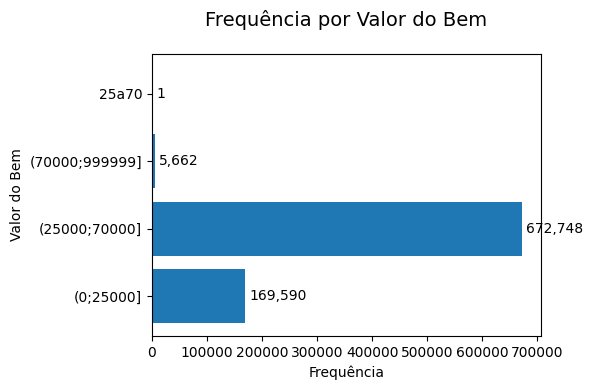

In [58]:
dfG5 = vl_bem_mes = df.groupby('vl_bem').size().reset_index(name='contagem')

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(dfG5['vl_bem'], dfG5['contagem'])

# Adicionar rótulos nas barras
ax.bar_label(bars, 
             labels=[f'{x:,.0f}' for x in dfG5['contagem']],  # Formato com vírgula
             padding=3)

plt.title('Frequência por Valor do Bem', fontsize=14, pad=20)
plt.xlabel('Frequência')
plt.ylabel('Valor do Bem')

plt.tight_layout()
plt.show()


In [59]:
df[df['vl_bem'] == '25a70']

,id,ano_mes,idade_veiculo,marca,vl_bem,idade,estado_civil,qt_restr,renda,Regiao,...,vl_a_pagar_por_idade_media_veiculo,nacionalidade,id_duplicado,flg_restr,per_model,per_observed,per_limbo,per_production,per_observed2,target_categoria
399824,362933522,202211,3_5,Outros,25a70,44,solteiro,0,3045,SE,...,16188.0,Outros,False,0,1,0,0,0,0,1.0


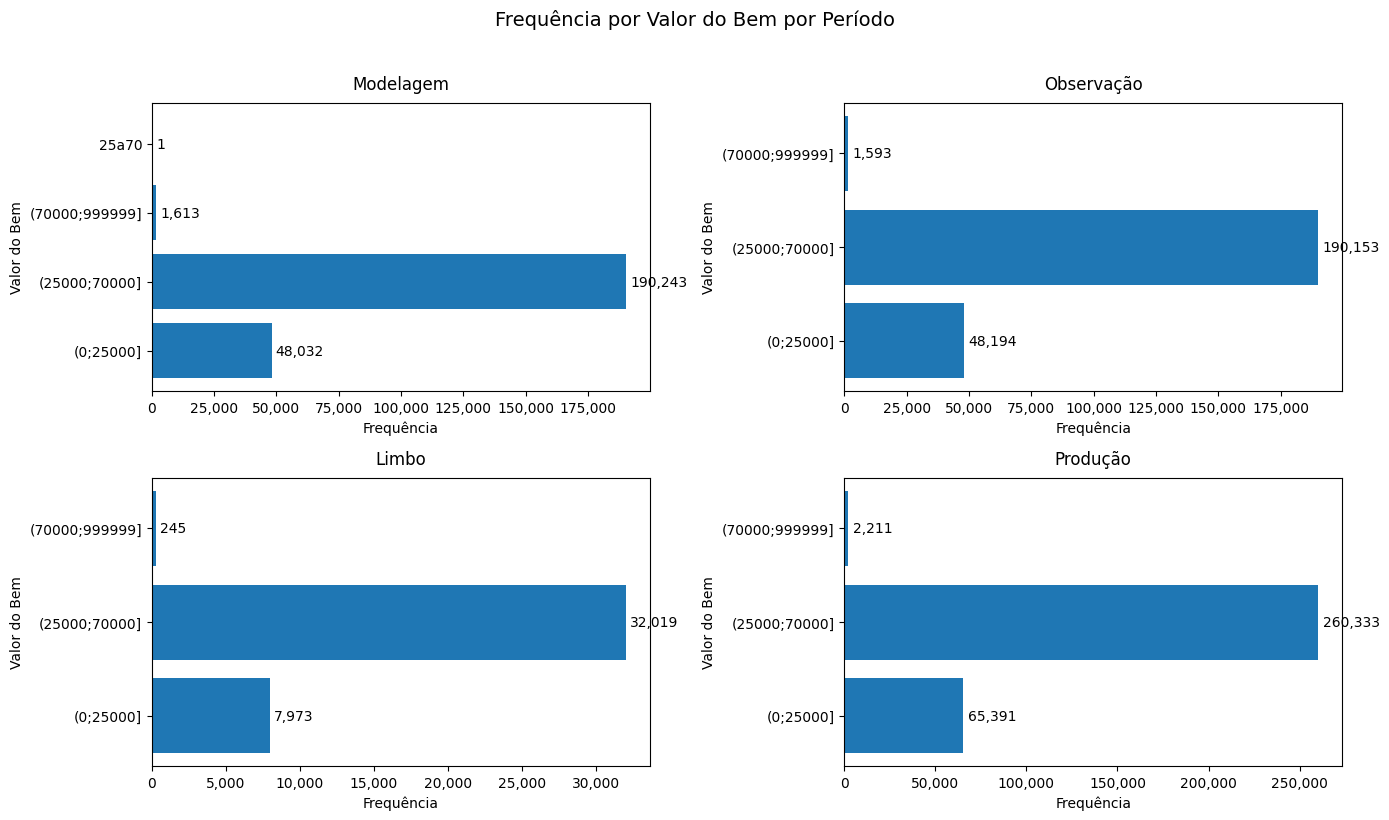


Quantidade de registros por período:
Modelagem: 239,889 registros
Observação: 239,940 registros
Limbo: 40,237 registros
Produção: 327,935 registros


In [60]:
# Filtrar apenas as categorias que têm dados (período = 1)
categorias_com_dados = []
dados_por_categoria = {}

for flag in flags:
    # Filtrar registros onde esta flag = 1
    df_categoria = df[df[flag] == 1]
    
    # Se houver dados para esta categoria, adicionar à lista
    if len(df_categoria) > 0:
        categorias_com_dados.append(flag)
        dados_por_categoria[flag] = df_categoria

# Calcular número de linhas necessário (2 colunas)
n_categorias = len(categorias_com_dados)
n_linhas = (n_categorias + 1) // 2

# Criar figura com subplots em grade 2 colunas
fig, axes = plt.subplots(n_linhas, 2, figsize=(14, 4*n_linhas))
axes = axes.flatten()

for i, flag in enumerate(categorias_com_dados):
    # Pegar os dados filtrados para esta categoria
    df_categoria = dados_por_categoria[flag]
    nome_categoria = category_mapping[flag]
    
    # Agrupar por vl_bem
    dfG5 = df_categoria.groupby('vl_bem').size().reset_index(name='contagem')
    
    # Criar gráfico de barras horizontais
    ax = axes[i]
    bars = ax.barh(dfG5['vl_bem'], dfG5['contagem'])
    
    # Adicionar rótulos nas barras
    ax.bar_label(bars, 
                 labels=[f'{x:,.0f}' for x in dfG5['contagem']],
                 padding=3)
    
    # Formatar eixo X com separador de milhares
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
    
    # Títulos e labels com nome amigável
    ax.set_title(f'{nome_categoria}', fontsize=12, pad=10)
    ax.set_xlabel('Frequência')
    ax.set_ylabel('Valor do Bem')

# Esconder subplots vazios
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Frequência por Valor do Bem por Período', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Mostrar quantos registros tem em cada categoria
print("\nQuantidade de registros por período:")
for flag in categorias_com_dados:
    nome = category_mapping[flag]
    qtd = len(dados_por_categoria[flag])
    print(f"{nome}: {qtd:,.0f} registros")

#### <span style="color:purple">Nota</span>
- 1 categoria contendo 1 unica observação

### Var: `idade`

In [61]:
univariate_missing_analysis(df, 'idade')

# missing_var_when_flag_1(df, 'idade', flags)

Missing Value Analysis for: idade
Category  Count Percentage
 Missing      0      0.00%
 Present 848001    100.00%
   Total 848001       100%


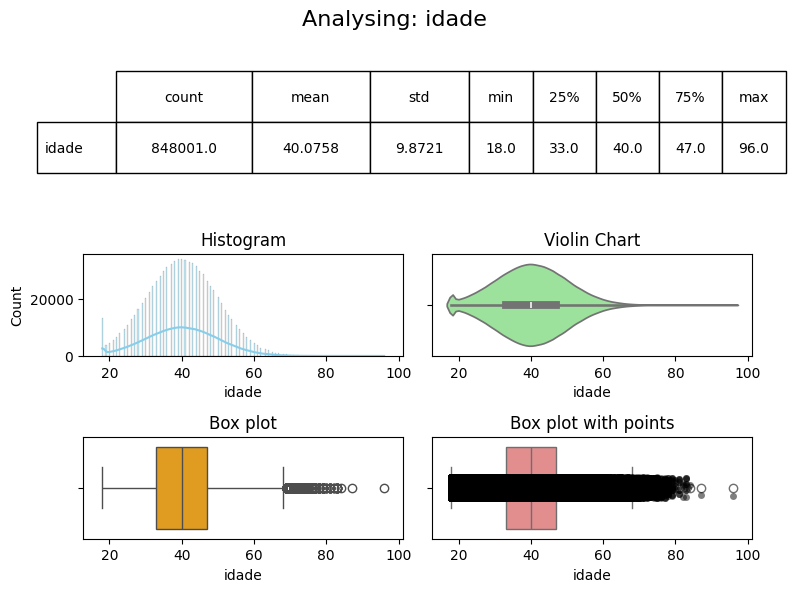

In [62]:
univariate_numeric_variable(df, 'idade')

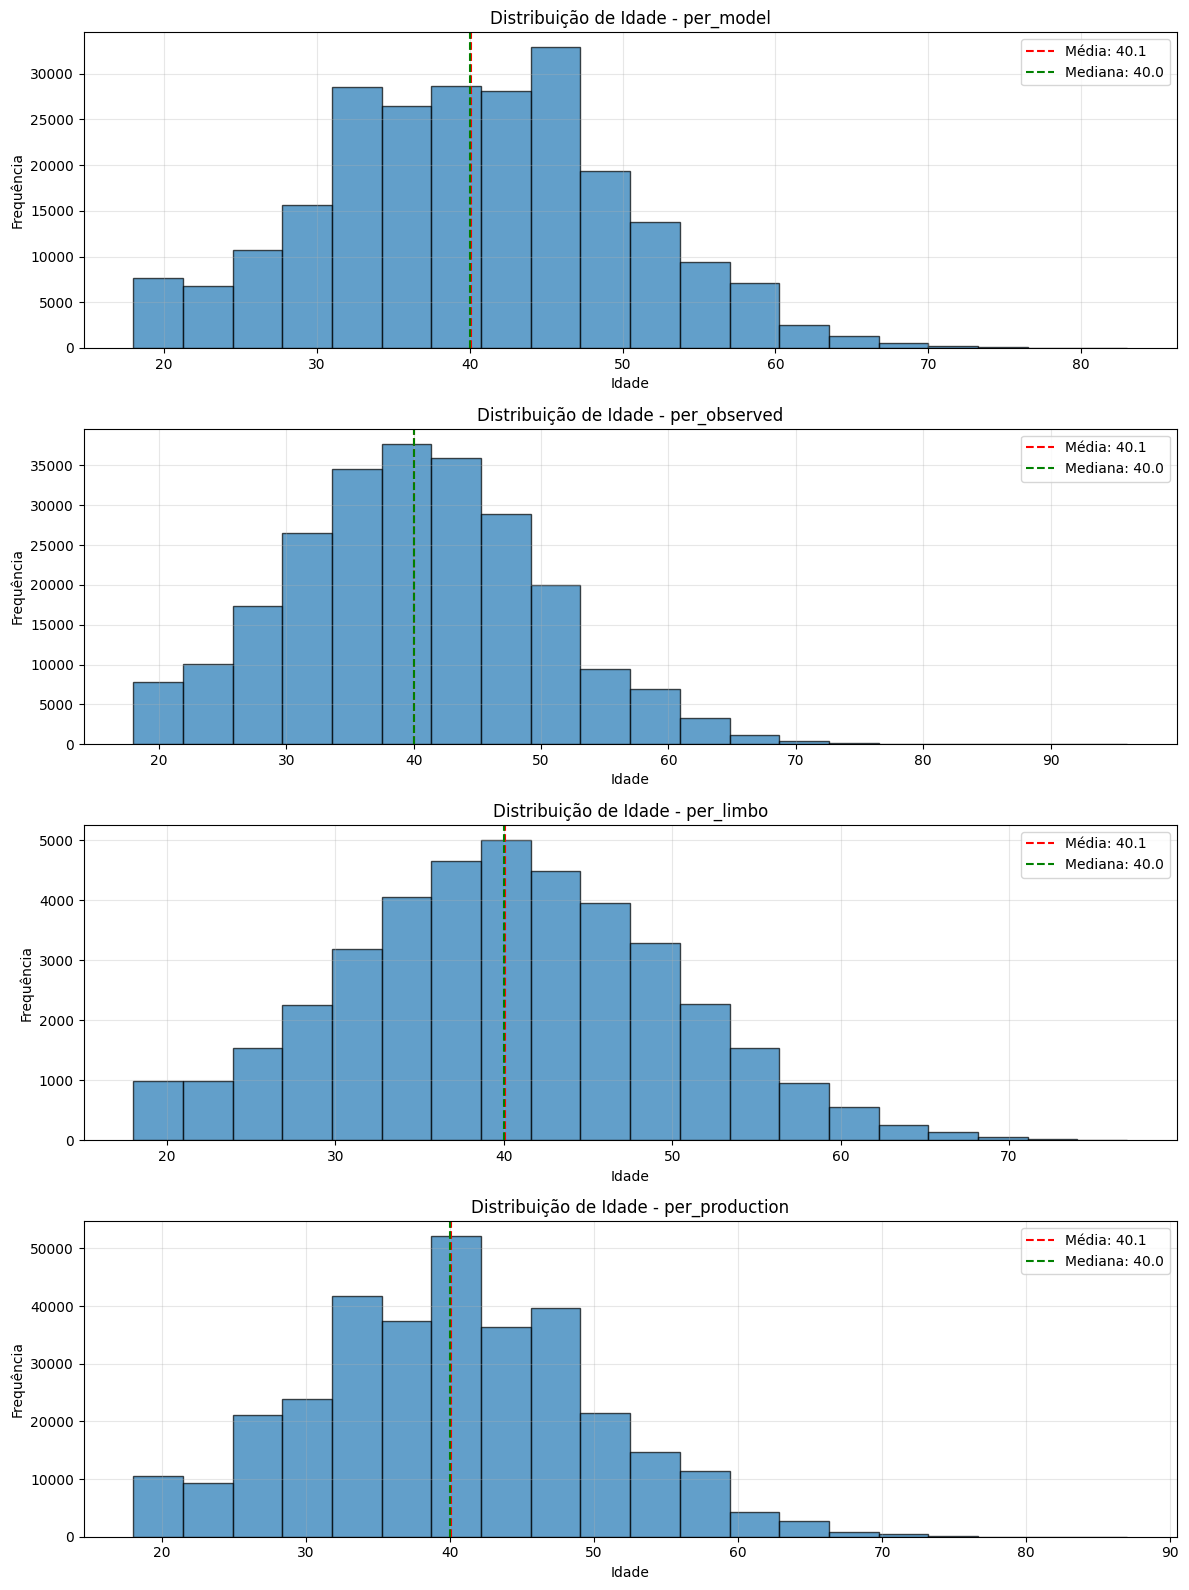

In [63]:
n_periodos = len(flags)

# Criar subplots
fig, axes = plt.subplots(nrows=n_periodos, ncols=1, figsize=(12, 4*n_periodos))
if n_periodos == 1:
    axes = [axes]

for i, periodo in enumerate(flags):
    # CORREÇÃO: Filtrar linhas onde a coluna do período é 1 e pegar a idade
    dados_periodo = df[df[periodo] == 1]['idade'].dropna()
    
    # Criar histograma
    axes[i].hist(dados_periodo, bins=20, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribuição de Idade - {periodo}', fontsize=12)
    axes[i].set_xlabel('Idade')
    axes[i].set_ylabel('Frequência')
    axes[i].grid(True, alpha=0.3)
    
    # Adicionar estatísticas (com verificação se há dados)
    if len(dados_periodo) > 0:
        media = dados_periodo.mean()
        mediana = dados_periodo.median()
        axes[i].axvline(media, color='red', linestyle='--', label=f'Média: {media:.1f}')
        axes[i].axvline(mediana, color='green', linestyle='--', label=f'Mediana: {mediana:.1f}')
        axes[i].legend()
    else:
        axes[i].text(0.5, 0.5, 'Sem dados para este período', 
                    transform=axes[i].transAxes, ha='center')

plt.tight_layout()
plt.show()

#### <span style="color:purple">Nota</span>
- Nada de muito suspeito aqui, parece que a idade está bem distribuida entre os períodos.

### Var: `estado_civil`

In [64]:
univariate_missing_analysis(df, 'estado_civil')

# missing_var_when_flag_1(df, 'estado_civil', flags)

Missing Value Analysis for: estado_civil
Category  Count Percentage
 Missing      0      0.00%
 Present 848001    100.00%
   Total 848001       100%


Categorical variable describe:


,count,unique,top,freq
estado_civil,848001,4,casado,338642


Frequency table of categorical variable (with percentage and total):


,estado_civil,Frequency,Percentage (%)
0,casado,338642,39.93
1,solteiro,254872,30.06
2,divorciado,169654,20.01
3,viuvo,84833,10.00
4,Total,848001,100.00


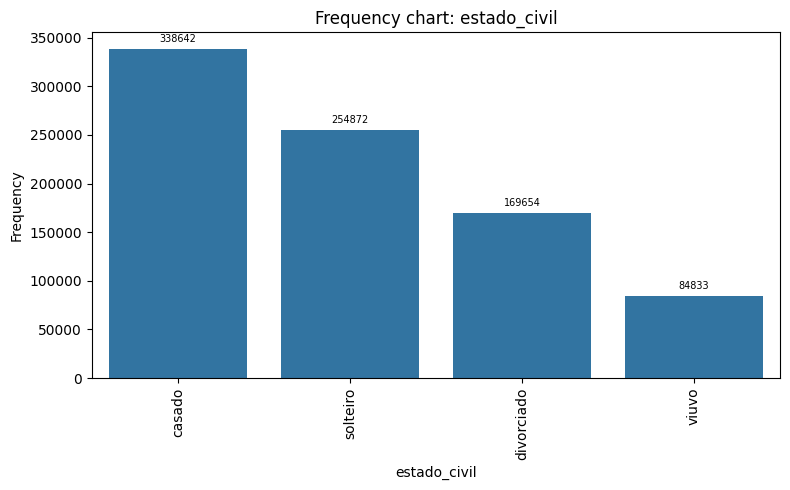

In [65]:
univariate_categorical_variable(df, 'estado_civil')

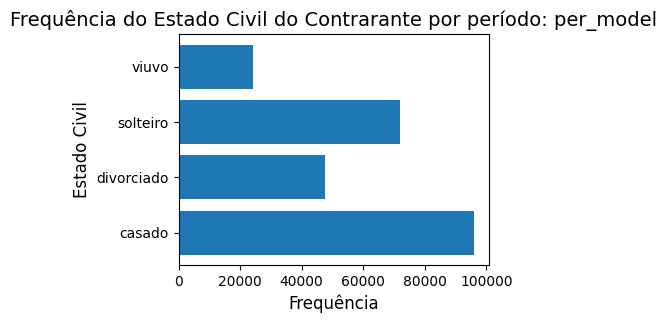

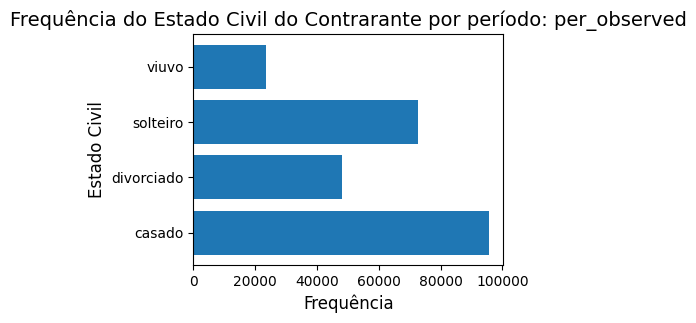

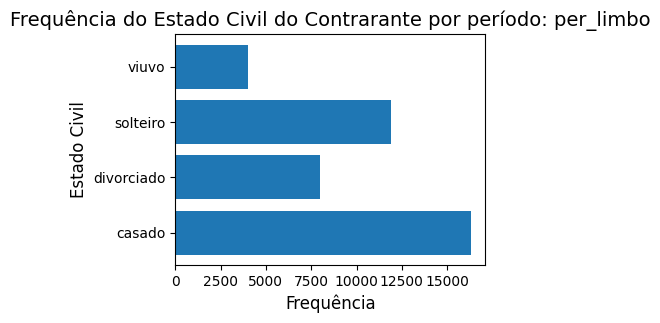

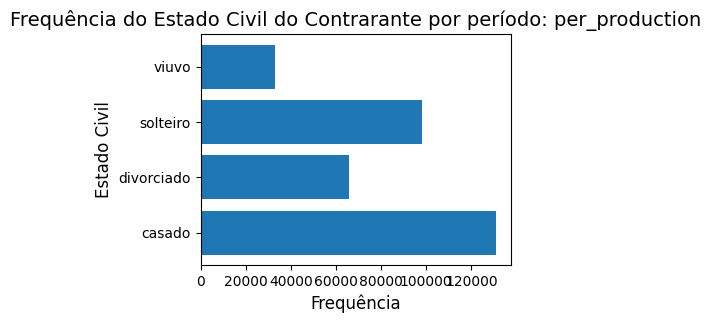

In [66]:
# Per period
dfG6 = df.groupby('estado_civil')[['per_model', 'per_observed', 'per_limbo', 'per_production']].sum().reset_index()
dfG6['total'] = dfG6[['per_model', 'per_observed', 'per_limbo', 'per_production']].sum(axis=1)

col_totals = dfG6[['per_model', 'per_observed', 'per_limbo', 'per_production', 'total']].sum()

dfG6_f = pd.concat([
    dfG6,
    pd.DataFrame([col_totals], index=['COLUMN_TOTAL']),

])

for flag in flags:

    plt.figure(figsize=(4, 3))
    plt.barh(dfG6['estado_civil'].astype(str), dfG6[flag])

    plt.xlabel('Frequência', fontsize=12)
    plt.ylabel('Estado Civil', fontsize=12)
    plt.title(f"Frequência do Estado Civil do Contrarante por período: {flag}", fontsize=14)

    plt.show()

#### <span style="color:purple">Nota</span>
- Nada de muito discrepante aqui

### Var: `qt_restr`

In [67]:
univariate_missing_analysis(df, 'qt_restr')

# missing_var_when_flag_1(df, 'qt_restr', flags)

Missing Value Analysis for: qt_restr
Category  Count Percentage
 Missing      0      0.00%
 Present 848001    100.00%
   Total 848001       100%


Categorical variable describe:


,count,unique,top,freq
qt_restr,848001,4,0,537826


Frequency table of categorical variable (with percentage and total):


,qt_restr,Frequency,Percentage (%)
0,0,537826,63.42
1,>2,148887,17.56
2,1,83049,9.79
3,2,78239,9.23
4,Total,848001,100.00


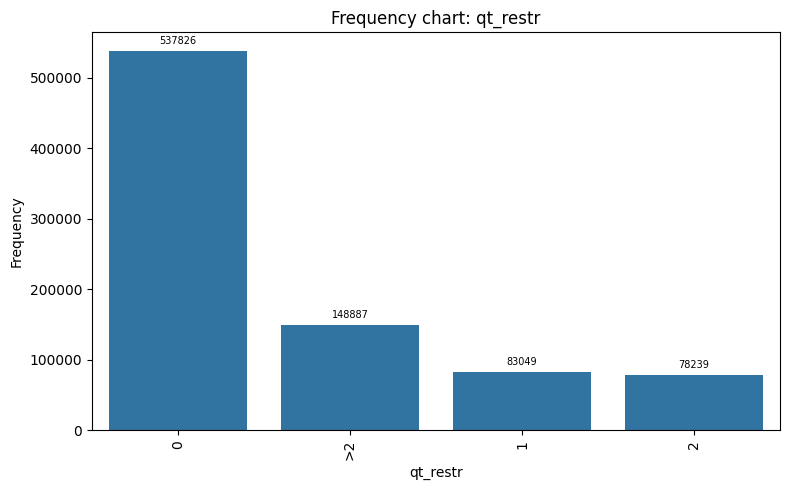

In [68]:
univariate_categorical_variable(df, 'qt_restr')

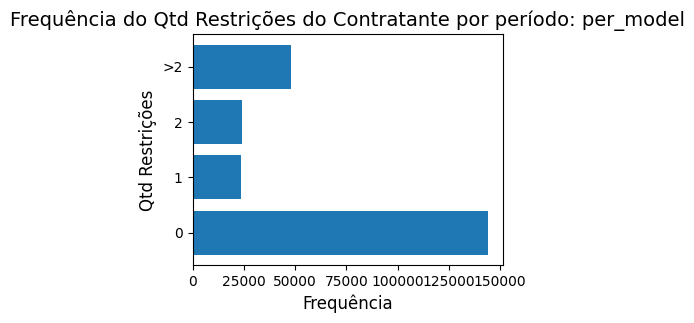

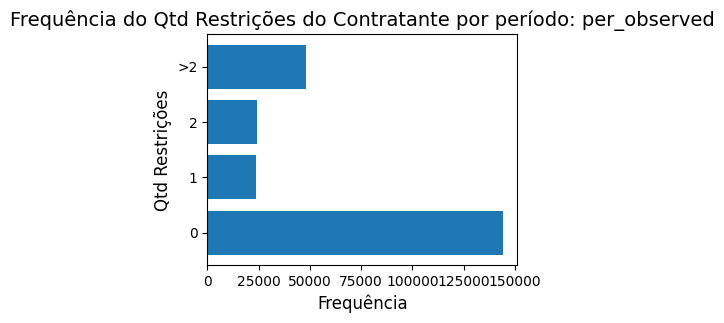

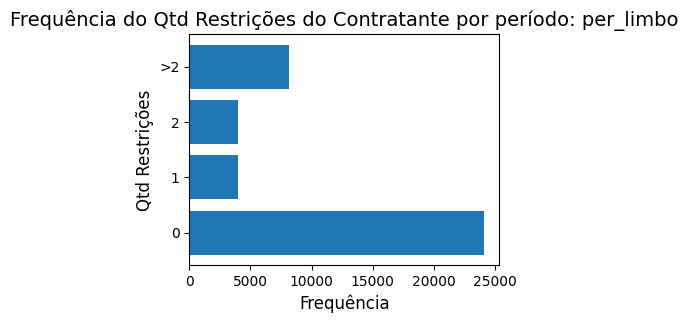

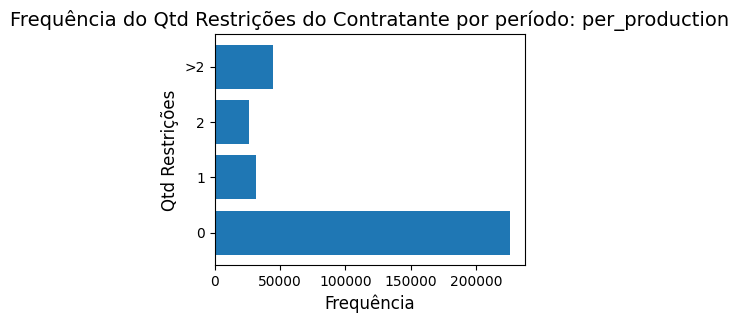

In [69]:
# Per period
dfG6 = df.groupby('qt_restr')[['per_model', 'per_observed', 'per_limbo', 'per_production']].sum().reset_index()
dfG6['total'] = dfG6[['per_model', 'per_observed', 'per_limbo', 'per_production']].sum(axis=1)

col_totals = dfG6[['per_model', 'per_observed', 'per_limbo', 'per_production', 'total']].sum()

dfG6_f = pd.concat([
    dfG6,
    pd.DataFrame([col_totals], index=['COLUMN_TOTAL']),

])

for flag in flags:

    plt.figure(figsize=(4, 3))
    plt.barh(dfG6['qt_restr'].astype(str), dfG6[flag])

    plt.xlabel('Frequência', fontsize=12)
    plt.ylabel('Qtd Restrições', fontsize=12)
    plt.title(f"Frequência do Qtd Restrições do Contratante por período: {flag}", fontsize=14)

    plt.show()

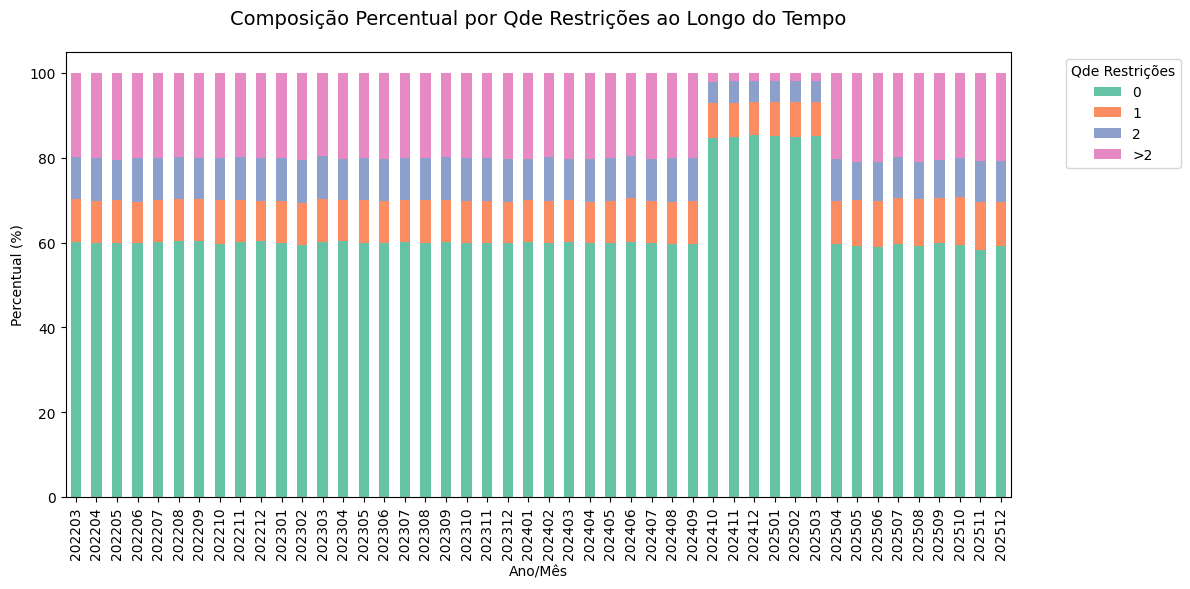

In [70]:
# Preparar os dados
# Calcular a contagem de veículos por mês e marca
dfG7 = df.groupby(['ano_mes', 'qt_restr']).size().reset_index(name='contagem')

# Calcular o total de veículos por mês
total_mes = df.groupby('ano_mes').size().reset_index(name='total')

# Juntar os dados e calcular a porcentagem
dfG7 = dfG7.merge(total_mes, on='ano_mes')
dfG7['percentual'] = (dfG7['contagem'] / dfG7['total']) * 100

# Ordenar por ano_mês
dfG7 = dfG7.sort_values('ano_mes')

# Opção 2: Gráfico de barras empilhadas (mostra a composição total)
pivot_df = dfG7.pivot(index='ano_mes', columns='qt_restr', values='percentual')

cores_pastel = sns.color_palette("Set2", n_colors=len(pivot_df.columns))

pivot_df.plot(kind='bar', stacked=True, figsize=(12, 6), color=cores_pastel)

plt.title('Composição Percentual por Qde Restrições ao Longo do Tempo', fontsize=14, pad=20)
plt.xlabel('Ano/Mês')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=90)
plt.legend(title='Qde Restrições', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [71]:
df.groupby('qt_restr')[flags].sum()


,per_model,per_observed,per_limbo,per_production
qt_restr,,,,
0,143994,143938,24143,225751
1,23821,23880,3960,31388
2,23943,24080,3985,26231
>2,48131,48042,8149,44565


In [72]:
dfG7[(dfG7['ano_mes'] >= 202405) & (dfG7['ano_mes'] <= 202505) ]

,ano_mes,qt_restr,contagem,total,percentual
104,202405,0,12101,20172,59.989094
105,202405,1,1971,20172,9.770970
106,202405,2,2078,20172,10.301408
107,202405,>2,4022,20172,19.938529
108,202406,0,11838,19717,60.039560
109,202406,1,2050,19717,10.397119
110,202406,2,1976,19717,10.021809
111,202406,>2,3853,19717,19.541512
112,202407,0,12020,20064,59.908293
113,202407,1,1979,20064,9.863437


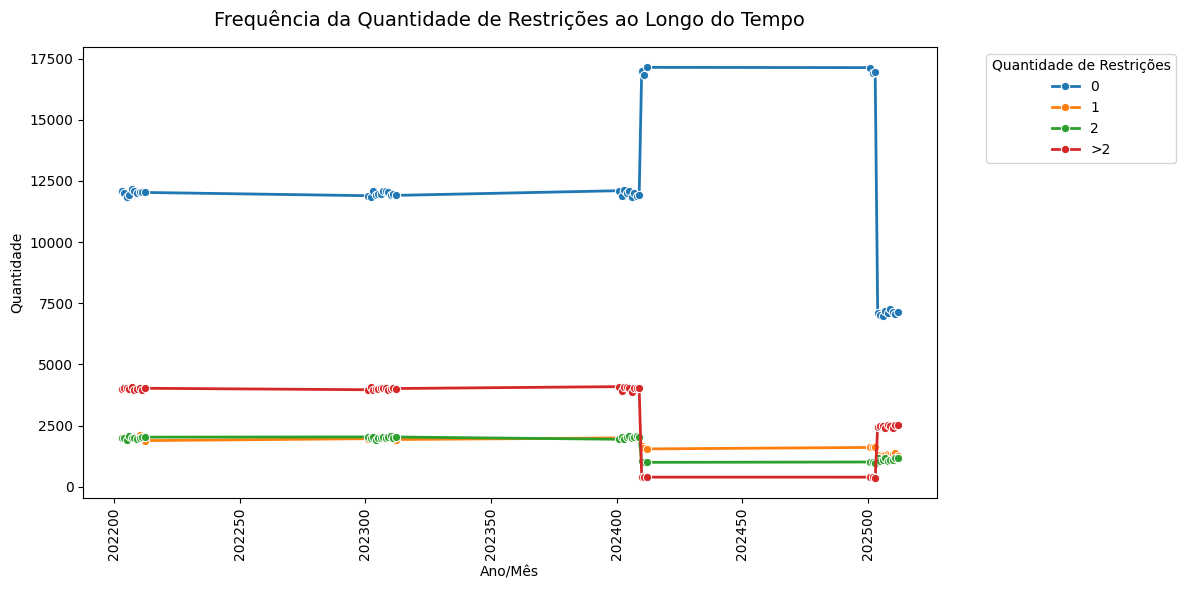

In [73]:
dfG7j = dfG7[['ano_mes', 'qt_restr', 'contagem']]

# Using seaborn which has built-in hue functionality
plt.figure(figsize=(12, 6))

sns.lineplot(data=dfG7j, x='ano_mes', y='contagem', hue='qt_restr', 
             marker='o', linewidth=2)

plt.title('Frequência da Quantidade de Restrições ao Longo do Tempo', fontsize=14, pad=15)
plt.xlabel('Ano/Mês')
plt.ylabel('Quantidade')
plt.xticks(rotation=90)

# Adjust legend
plt.legend(title='Quantidade de Restrições', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()



Data for stacked bar:
qt_restr      0     1     2    >2
ano_mes                          
202203    12094  2037  1978  3986
202204    12017  1989  1995  4036
202205    11823  1979  1896  4035
202206    11930  1958  2065  3986
202207    12186  2038  2009  4067


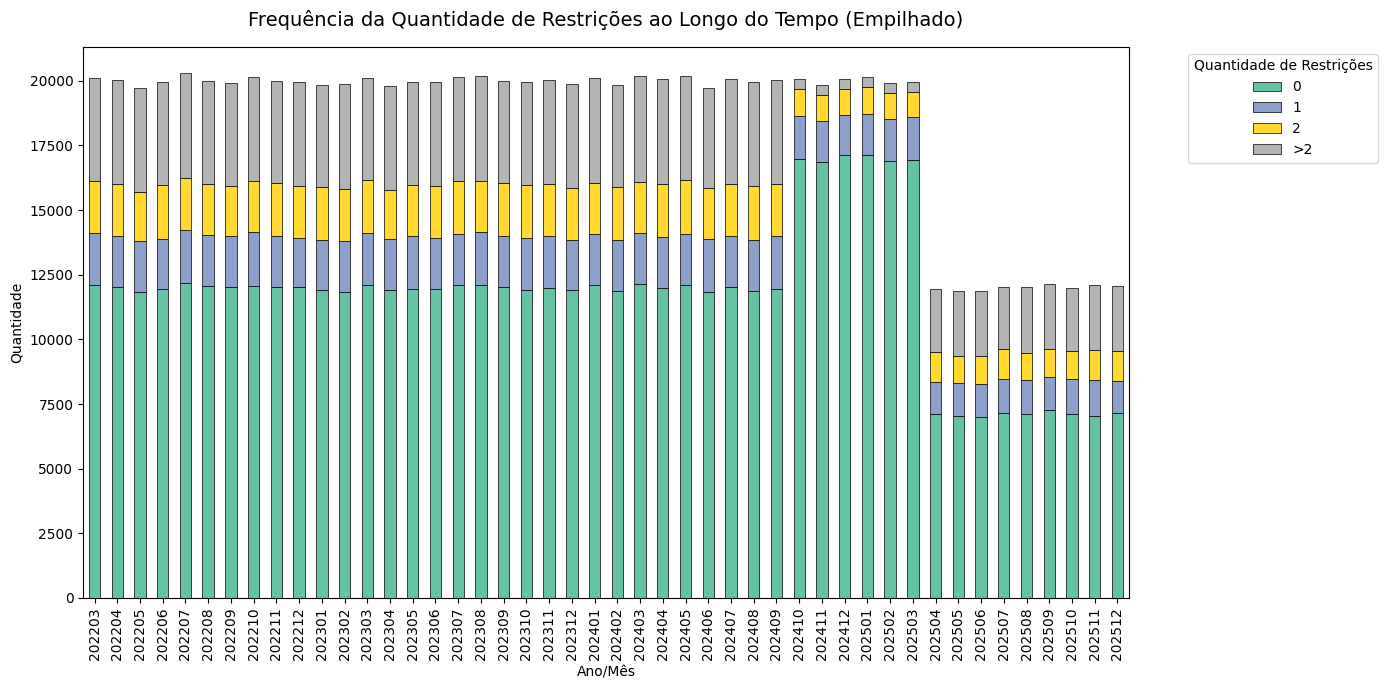

In [74]:
# Pivot the data to have qt_restr as columns
df_pivot = dfG7j.pivot(index='ano_mes', columns='qt_restr', values='contagem').fillna(0)

# Sort by date to ensure chronological order
df_pivot = df_pivot.sort_index()

print("Data for stacked bar:")
print(df_pivot.head())

# Create stacked bar plot
ax = df_pivot.plot(kind='bar', stacked=True, figsize=(14, 7), 
                   colormap='Set2', edgecolor='black', linewidth=0.5)

plt.title('Frequência da Quantidade de Restrições ao Longo do Tempo (Empilhado)', 
          fontsize=14, pad=15)
plt.xlabel('Ano/Mês')
plt.ylabel('Quantidade')
plt.xticks(rotation=90)

# Add legend with better positioning
plt.legend(title='Quantidade de Restrições', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add value labels on bars (optional)
# for container in ax.containers:
    # ax.bar_label(container, label_type='center', fontsize=8, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

#### <span style="color:purple">Nota</span>
- A mudança é radical em poucos meses, indicando possível alteração de política de crédito, ajuste em consulta de restritivos, mudança no parceiro de dados ou até erro no processo ETL.

### Var: `renda`

In [75]:
univariate_missing_analysis(df, 'renda')

# missing_var_when_flag_1(df, 'renda', flags)

Missing Value Analysis for: renda
Category  Count Percentage
 Missing      0      0.00%
 Present 848001    100.00%
   Total 848001       100%


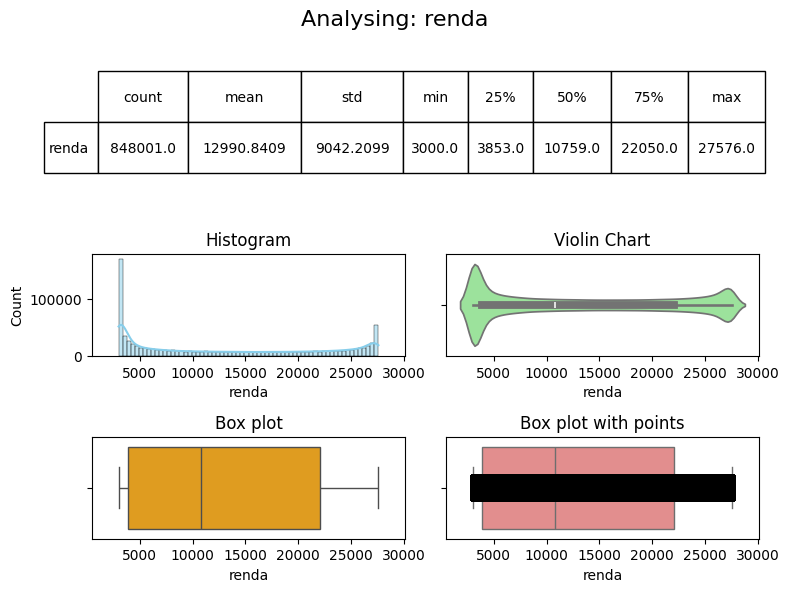

In [76]:
univariate_numeric_variable(df, 'renda')

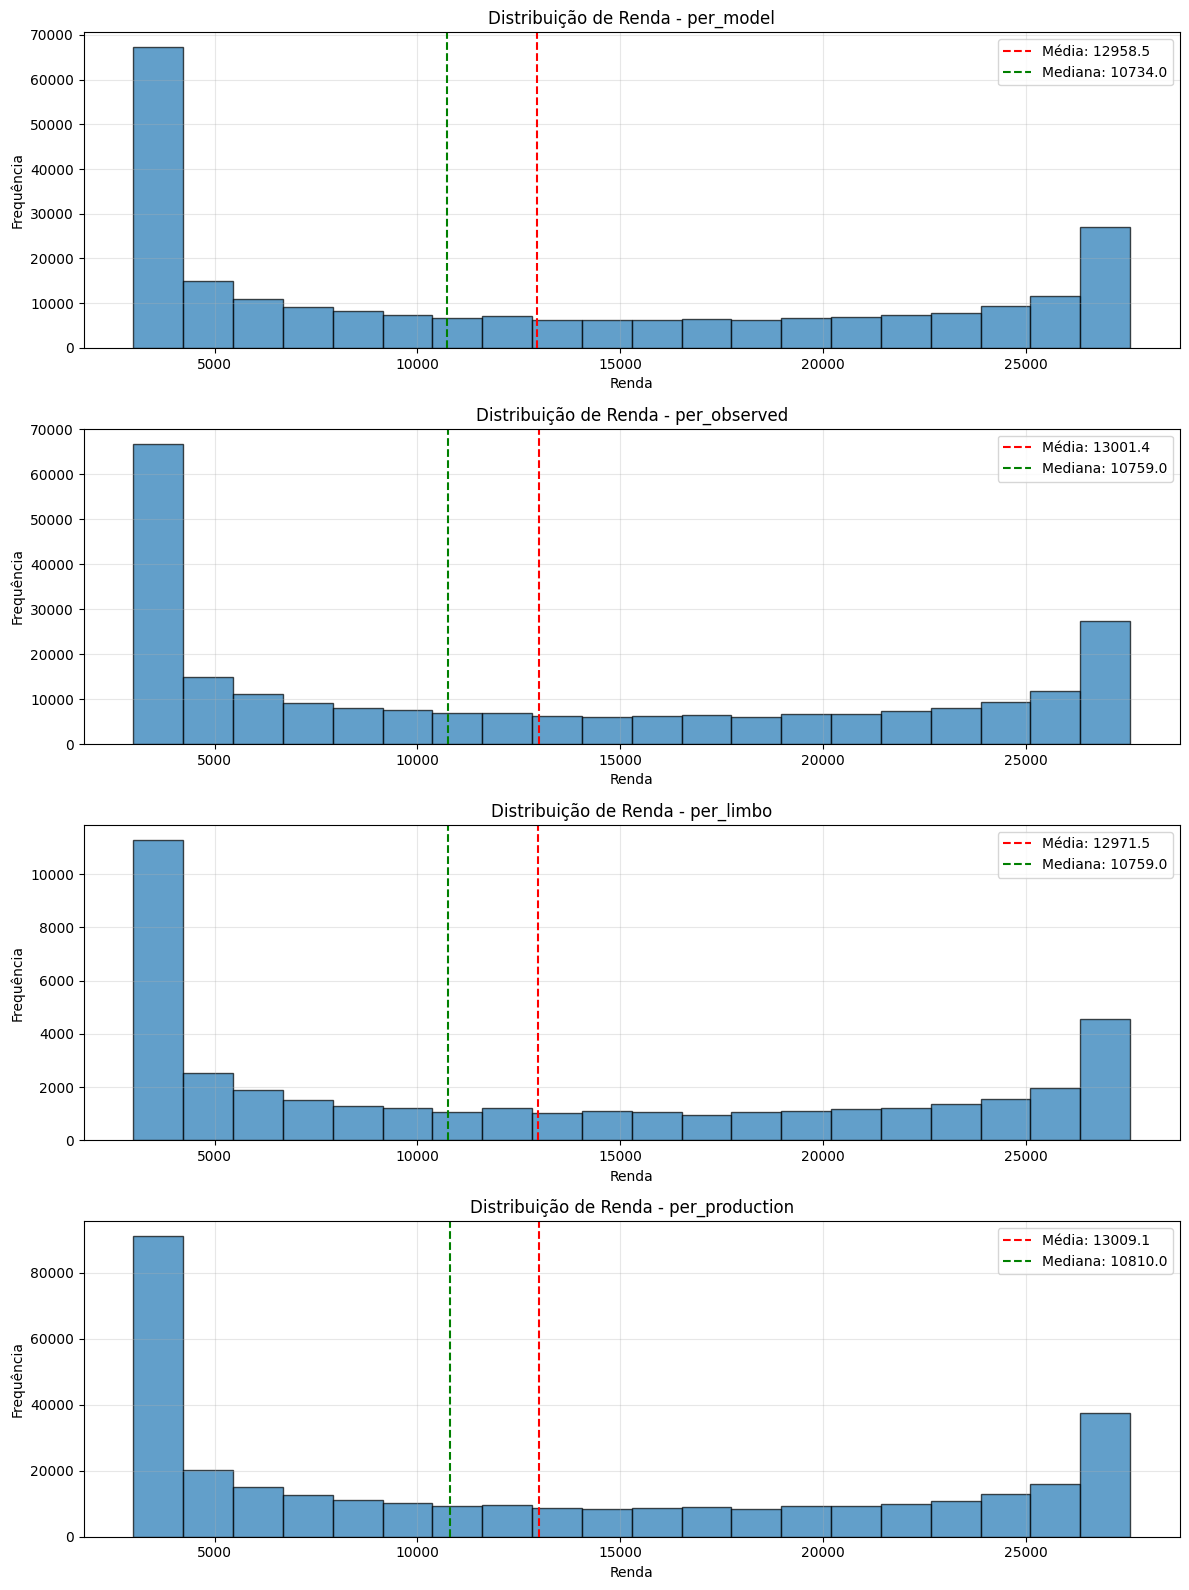

In [77]:
n_periodos = len(flags)

# Criar subplots
fig, axes = plt.subplots(nrows=n_periodos, ncols=1, figsize=(12, 4*n_periodos))
if n_periodos == 1:
    axes = [axes]

for i, periodo in enumerate(flags):
    # CORREÇÃO: Filtrar linhas onde a coluna do período é 1 e pegar a renda
    dados_periodo = df[df[periodo] == 1]['renda'].dropna()
    
    # Criar histograma
    axes[i].hist(dados_periodo, bins=20, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribuição de Renda - {periodo}', fontsize=12)
    axes[i].set_xlabel('Renda')
    axes[i].set_ylabel('Frequência')
    axes[i].grid(True, alpha=0.3)
    
    # Adicionar estatísticas (com verificação se há dados)
    if len(dados_periodo) > 0:
        media = dados_periodo.mean()
        mediana = dados_periodo.median()
        axes[i].axvline(media, color='red', linestyle='--', label=f'Média: {media:.1f}')
        axes[i].axvline(mediana, color='green', linestyle='--', label=f'Mediana: {mediana:.1f}')
        axes[i].legend()
    else:
        axes[i].text(0.5, 0.5, 'Sem dados para este período', 
                    transform=axes[i].transAxes, ha='center')

plt.tight_layout()
plt.show()

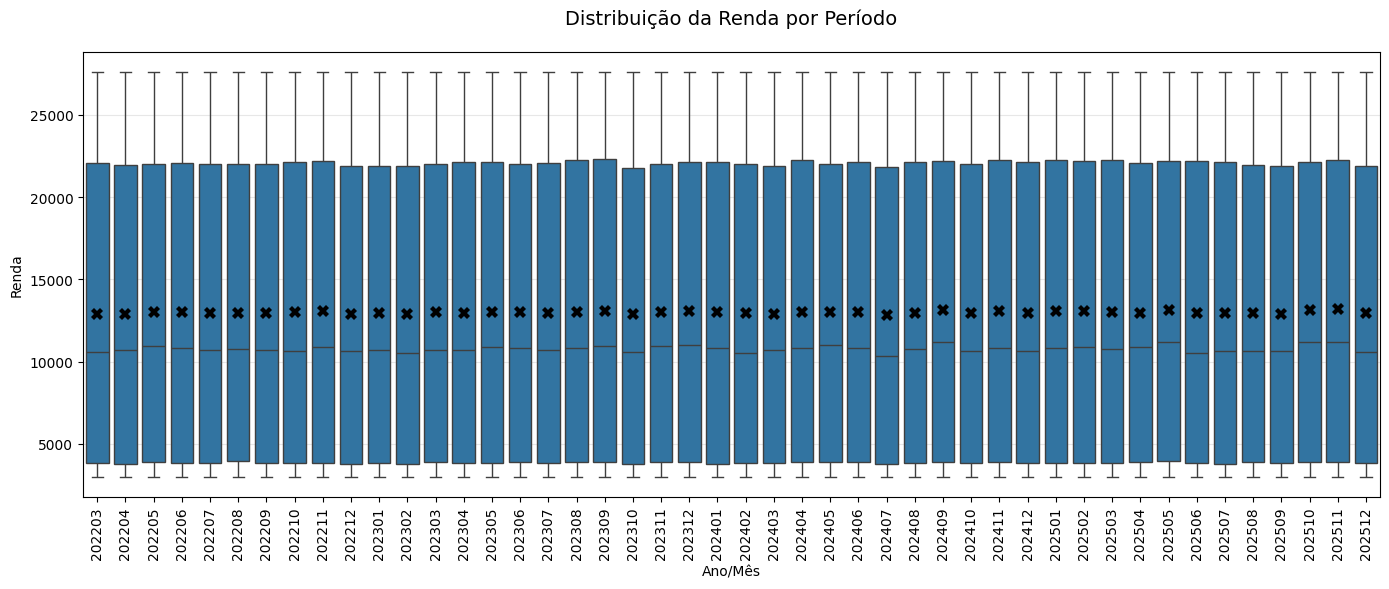

In [78]:
# Preparar os dados
df_box = df[['ano_mes', 'renda']].dropna()
df_box = df_box.sort_values('ano_mes')
df_box['ano_mes'] = df_box['ano_mes'].astype(str)



plt.figure(figsize=(14, 6))

# Boxplot com média como "X"
sns.boxplot(data=df_box, x='ano_mes', y='renda', 
            # palette='pastel',
            showmeans=True,           # Mostrar média
            meanprops={
                'marker': 'X',         # Formato do marcador
                'markerfacecolor': 'black',  # Cor interna
                'markeredgecolor': 'black',  # Cor da borda
                'markersize': 8,       # Tamanho do marcador
                'markeredgewidth': 0.01   # Espessura da borda
            })

plt.title('Distribuição da Renda por Período', fontsize=14, pad=20)
plt.xlabel('Ano/Mês')
plt.ylabel('Renda')
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

C:\Users\kel_m\AppData\Local\Temp\ipykernel_29148\3648278443.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




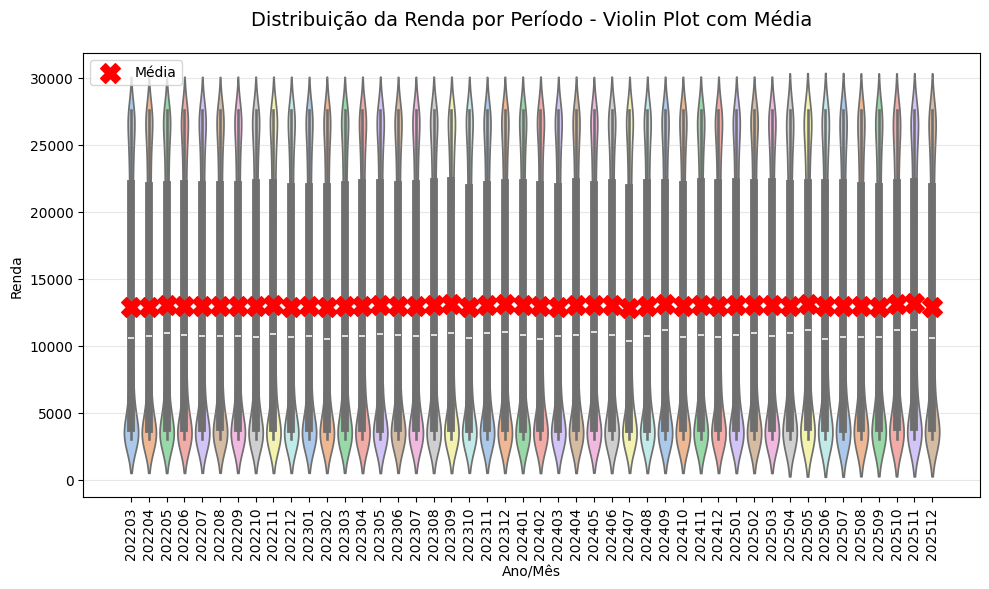

In [79]:
# Preparar os dados
df_violin = df[['ano_mes', 'renda']].dropna()
df_violin = df_violin.sort_values('ano_mes')
df_violin['ano_mes'] = df_violin['ano_mes'].astype(str)

plt.figure(figsize=(10, 6))

# Violin plot com boxplot interno e média
sns.violinplot(data=df_violin, x='ano_mes', y='renda', 
               palette='pastel',
               inner='box',           # Mostra boxplot dentro
               density_norm='width')   # Largura proporcional ao número de pontos

# Adicionar média como 'X'
medias = df_violin.groupby('ano_mes')['renda'].mean().values
periodos = sorted(df_violin['ano_mes'].unique())

for i, media in enumerate(medias):
    plt.scatter(i, media, marker='X', s=200, color='red', zorder=10, 
               label='Média' if i == 0 else '')

plt.title('Distribuição da Renda por Período - Violin Plot com Média', fontsize=14, pad=20)
plt.xlabel('Ano/Mês')
plt.ylabel('Renda')
plt.xticks(rotation=90)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

#### <span style="color:purple">Nota</span>
- nada de muito anormal aqui

### Var: `Regiao` 

In [80]:
univariate_missing_analysis(df, 'Regiao')

# missing_var_when_flag_1(df, 'Regiao', flags)

Missing Value Analysis for: Regiao
Category  Count Percentage
 Missing      0      0.00%
 Present 848001    100.00%
   Total 848001       100%


Categorical variable describe:


,count,unique,top,freq
Regiao,848001,5,SE,258127


Frequency table of categorical variable (with percentage and total):


,Regiao,Frequency,Percentage (%)
0,SE,258127,30.44
1,CO,234606,27.67
2,S,120739,14.24
3,NE,118613,13.99
4,N,115916,13.67
5,Total,848001,100.00


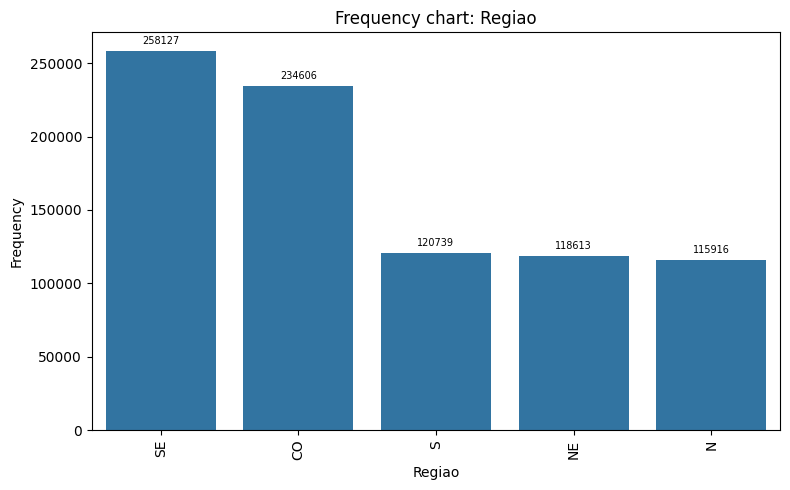

In [81]:
univariate_categorical_variable(df, 'Regiao')

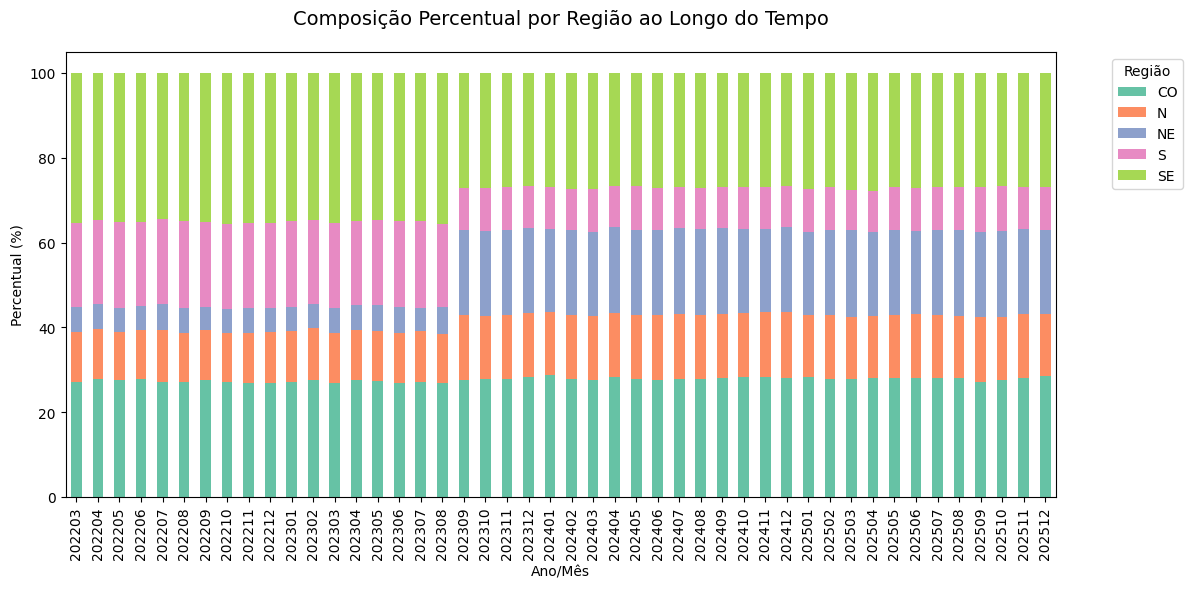

In [82]:
# Preparar os dados
# Calcular a contagem de veículos por mês e marca
dfG8 = df.groupby(['ano_mes', 'Regiao']).size().reset_index(name='contagem')

# Calcular o total de veículos por mês
total_mes = df.groupby('ano_mes').size().reset_index(name='total')

# Juntar os dados e calcular a porcentagem
dfG8 = dfG8.merge(total_mes, on='ano_mes')
dfG8['percentual'] = (dfG8['contagem'] / dfG8['total']) * 100

# Ordenar por ano_mês
dfG8 = dfG8.sort_values('ano_mes')

# Opção 2: Gráfico de barras empilhadas (mostra a composição total)
pivot_df = dfG8.pivot(index='ano_mes', columns='Regiao', values='percentual')

cores_pastel = sns.color_palette("Set2", n_colors=len(pivot_df.columns))

pivot_df.plot(kind='bar', stacked=True, figsize=(12, 6), color=cores_pastel)

plt.title('Composição Percentual por Região ao Longo do Tempo', fontsize=14, pad=20)
plt.xlabel('Ano/Mês')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=90)
plt.legend(title='Região', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [83]:
dfG8[(dfG8['ano_mes'] >= 202305) & (dfG8['ano_mes'] <= 202401)]

,ano_mes,Regiao,contagem,total,percentual
70,202305,CO,5456,19950,27.348371
71,202305,N,2354,19950,11.799499
72,202305,NE,1217,19950,6.100251
73,202305,S,4015,19950,20.125313
74,202305,SE,6908,19950,34.626566
75,202306,CO,5386,19954,26.992082
76,202306,N,2323,19954,11.641776
77,202306,NE,1221,19954,6.119074
78,202306,S,4058,19954,20.336775
79,202306,SE,6966,19954,34.910294


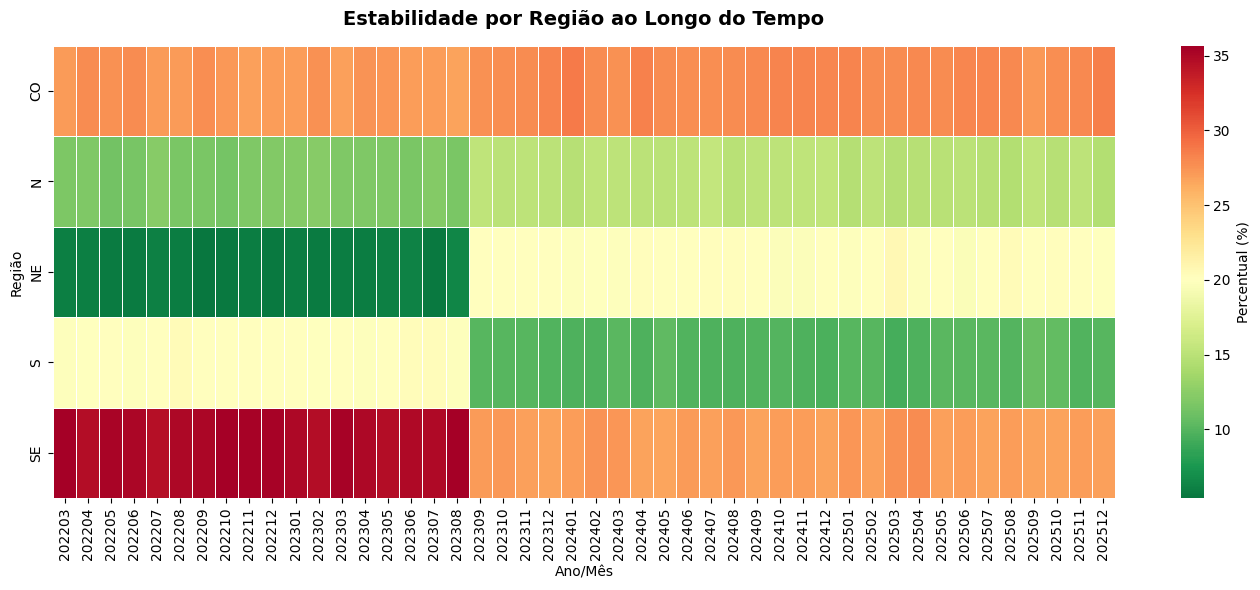

In [84]:
# Pivot the data to create a matrix with Regiao as rows and ano_mes as columns
heatmap_dfG8 = dfG8.pivot(index='Regiao', columns='ano_mes', values='percentual')

# Sort regions if needed (custom order)
# heatmap_dfG8 = heatmap_dfG8.reindex(['N', 'NE', 'CO', 'SE', 'S'])  # Example order

# Sort dates chronologically
heatmap_dfG8 = heatmap_dfG8.sort_index(axis=1)

# print("Heatmap data shape:", heatmap_dfG8.shape)
# print(heatmap_dfG8.head())

# Create the heatmap
plt.figure(figsize=(14, 6))

# Using seaborn for better heatmaps
sns.heatmap(heatmap_dfG8, 
            annot=False,           # Show values in cells
            fmt='.1f',            # Format as 1 decimal place
            cmap='RdYlGn_r',        # Color scheme (Red-Yellow-Green)
            center=20,            # Center the colormap at 20%
            linewidths=0.5,       # Add lines between cells
            linecolor='white',     # Line color
            cbar_kws={'label': 'Percentual (%)'})  # Colorbar label

plt.title('Estabilidade por Região ao Longo do Tempo', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Ano/Mês')
plt.ylabel('Região')

# Adjust x-axis labels for better readability
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

#### <span style="color:purple">Nota</span>
- Mudança repentina e significativa no perfil regional dos proponentes.
- **Possíveis causas:**
    - Redirecionamento comercial (novas campanhas ou parceiros no NE).
    - Mudança em políticas de aprovação regional.
    - Alteração na estratégia de distribuição das propostas.
    - Erro ou ajuste em sistemas de origem dos dados.
- **Riscos:** O modelo pode ficar enviesado se a base de treinamento não refletir a nova distribuição, ou pode perder performance em regiões que passaram a ser menos representadas.

### Var: `Profissao`

In [85]:
univariate_missing_analysis(df, 'Profissao')

# missing_var_when_flag_1(df, 'Profissao', flags)

Missing Value Analysis for: Profissao
Category  Count Percentage
 Missing      0      0.00%
 Present 848001    100.00%
   Total 848001       100%


Categorical variable describe:


,count,unique,top,freq
Profissao,848001,7,prof_serv,254691


Frequency table of categorical variable (with percentage and total):


,Profissao,Frequency,Percentage (%)
0,prof_serv,254691,30.03
1,assalariados,211999,25.00
2,autonomos,127241,15.00
3,consignados,126930,14.97
4,empresarios,59360,7.00
5,liberais,59205,6.98
6,agropecuaria,8575,1.01
7,Total,848001,100.00


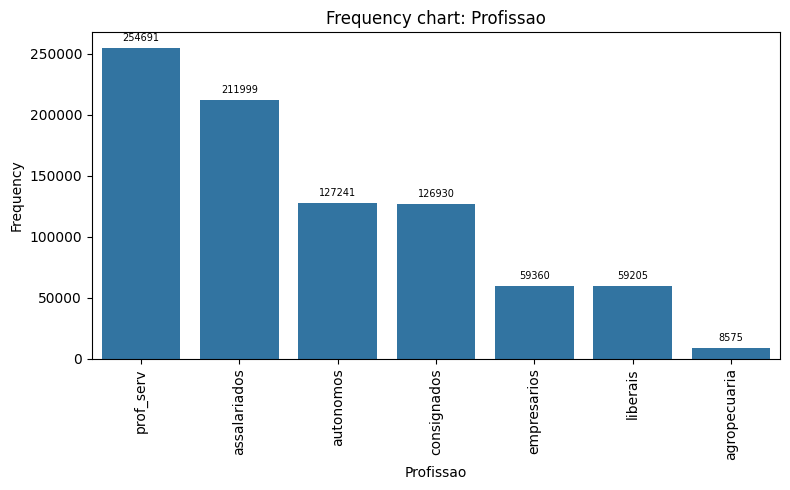

In [86]:
univariate_categorical_variable(df, 'Profissao')

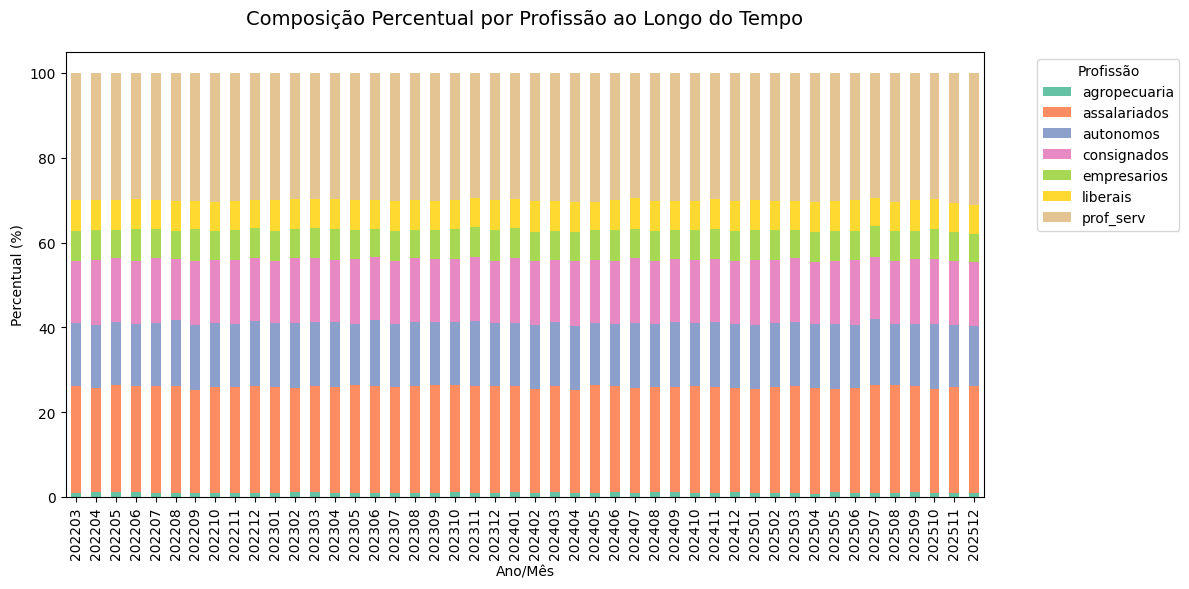

In [87]:
# Preparar os dados
# Calcular a contagem de veículos por mês e marca
dfG9 = df.groupby(['ano_mes', 'Profissao']).size().reset_index(name='contagem')

# Calcular o total de veículos por mês
total_mes = df.groupby('ano_mes').size().reset_index(name='total')

# Juntar os dados e calcular a porcentagem
dfG9 = dfG9.merge(total_mes, on='ano_mes')
dfG9['percentual'] = (dfG9['contagem'] / dfG9['total']) * 100

# Ordenar por ano_mês
dfG9 = dfG9.sort_values('ano_mes')

# Opção 2: Gráfico de barras empilhadas (mostra a composição total)
pivot_df = dfG9.pivot(index='ano_mes', columns='Profissao', values='percentual')

cores_pastel = sns.color_palette("Set2", n_colors=len(pivot_df.columns))

pivot_df.plot(kind='bar', stacked=True, figsize=(12, 6), color=cores_pastel)

plt.title('Composição Percentual por Profissão ao Longo do Tempo', fontsize=14, pad=20)
plt.xlabel('Ano/Mês')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=90)
plt.legend(title='Profissão', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### <span style="color:purple">Nota</span>
- Nada anormal por aqui, as profissões apresentam um percentual estático na base

### Var: `entrada`

In [88]:
univariate_missing_analysis(df, 'entrada')

# missing_var_when_flag_1(df, 'entrada', flags)

Missing Value Analysis for: entrada
Category  Count Percentage
 Missing      0      0.00%
 Present 848001    100.00%
   Total 848001       100%


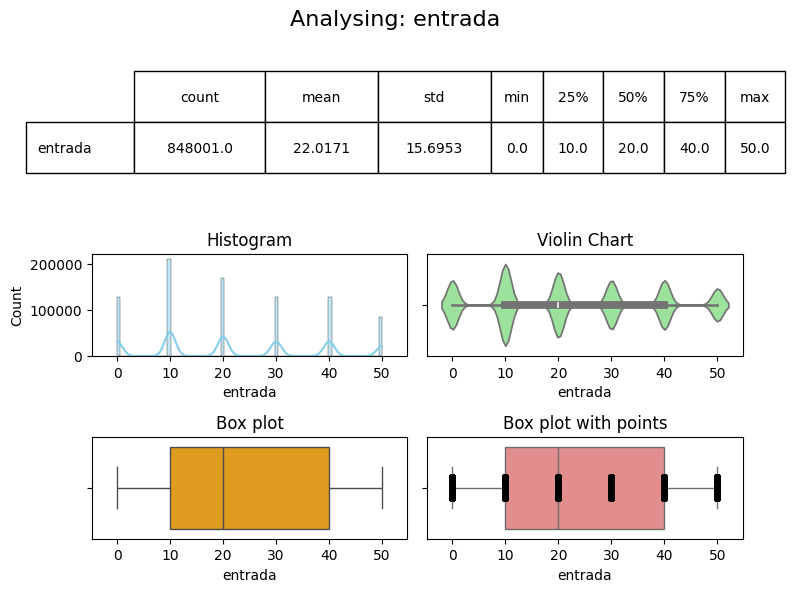

In [89]:
univariate_numeric_variable(df, 'entrada')

Categorical variable describe:


,count,mean,std,min,25%,50%,75%,max
entrada,848001.0,22.01712,15.695303,0.0,10.0,20.0,40.0,50.0


Frequency table of categorical variable (with percentage and total):


,entrada,Frequency,Percentage (%)
0,10,211272,24.91
1,20,169807,20.02
2,40,127479,15.03
3,0,127411,15.02
4,30,126954,14.97
5,50,85078,10.03
6,Total,848001,100.00


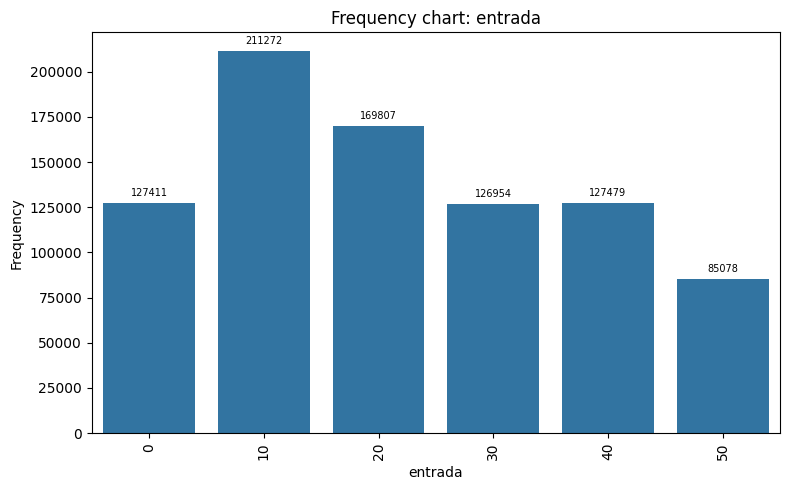

In [90]:
univariate_categorical_variable(df, 'entrada')

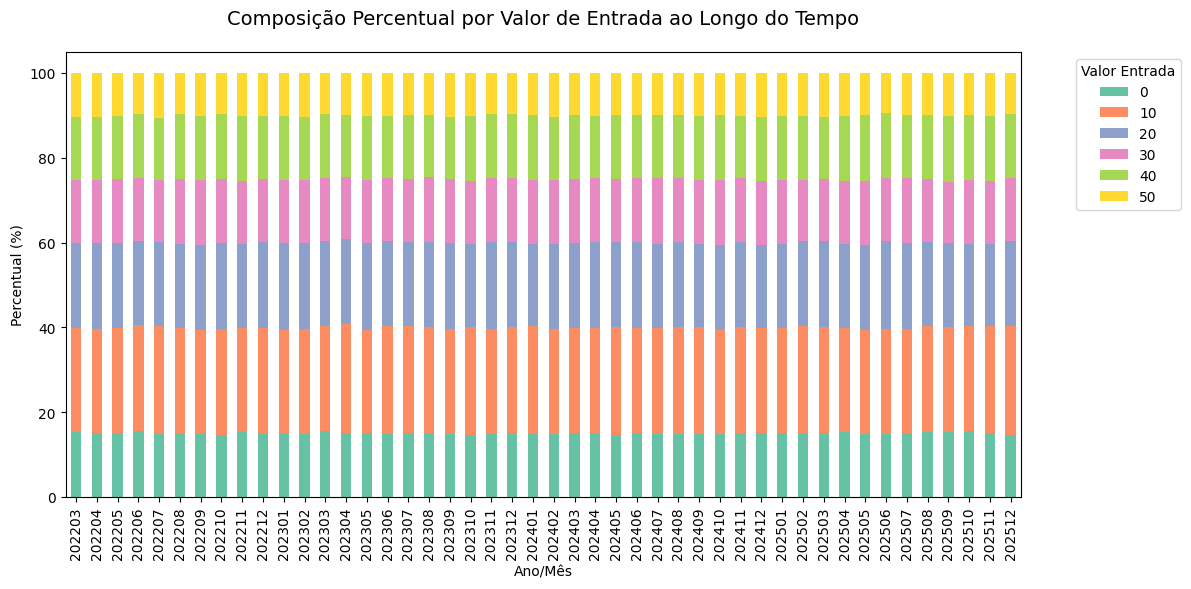

In [91]:
# Preparar os dados
# Calcular a contagem de veículos por mês e variavel
dfG9 = df.groupby(['ano_mes', 'entrada']).size().reset_index(name='contagem')

# Calcular o total de veículos por mês
total_mes = df.groupby('ano_mes').size().reset_index(name='total')

# Juntar os dados e calcular a porcentagem
dfG9 = dfG9.merge(total_mes, on='ano_mes')
dfG9['percentual'] = (dfG9['contagem'] / dfG9['total']) * 100

# Ordenar por ano_mês
dfG9 = dfG9.sort_values('ano_mes')

# Opção 2: Gráfico de barras empilhadas (mostra a composição total)
pivot_df = dfG9.pivot(index='ano_mes', columns='entrada', values='percentual')

cores_pastel = sns.color_palette("Set2", n_colors=len(pivot_df.columns))

pivot_df.plot(kind='bar', stacked=True, figsize=(12, 6), color=cores_pastel)

plt.title('Composição Percentual por Valor de Entrada ao Longo do Tempo', fontsize=14, pad=20)
plt.xlabel('Ano/Mês')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=90)
plt.legend(title='Valor Entrada', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### <span style="color:purple">Nota</span>
- Distribuição parece estável nos períodos.

### Var: `prazo`

In [92]:
univariate_missing_analysis(df, 'prazo')

# missing_var_when_flag_1(df, 'prazo', flags)

Missing Value Analysis for: prazo
Category  Count Percentage
 Missing      0      0.00%
 Present 848001    100.00%
   Total 848001       100%


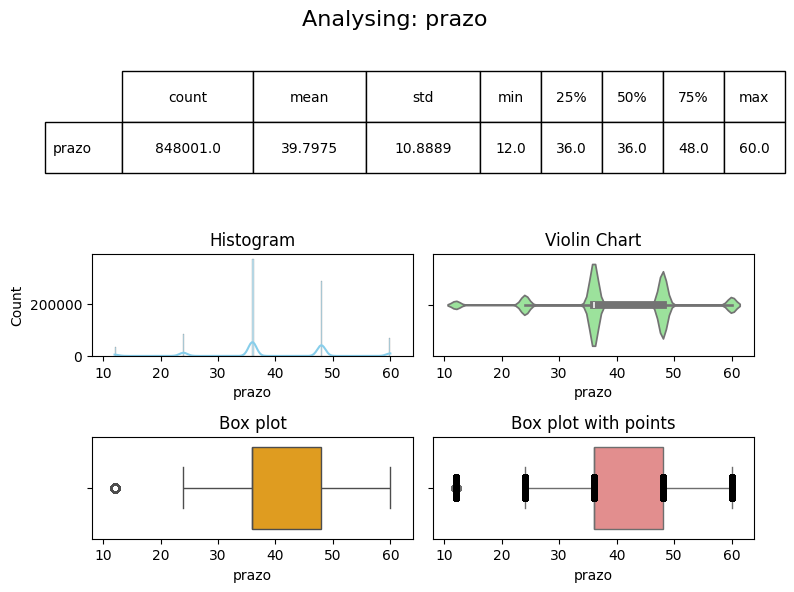

In [93]:
univariate_numeric_variable(df, "prazo")

Categorical variable describe:


,count,mean,std,min,25%,50%,75%,max
prazo,848001.0,39.7975,10.888858,12.0,36.0,36.0,48.0,60.0


Frequency table of categorical variable (with percentage and total):


,prazo,Frequency,Percentage (%)
0,36,372351,43.91
1,48,287990,33.96
2,24,85159,10.04
3,60,67632,7.98
4,12,34869,4.11
5,Total,848001,100.00


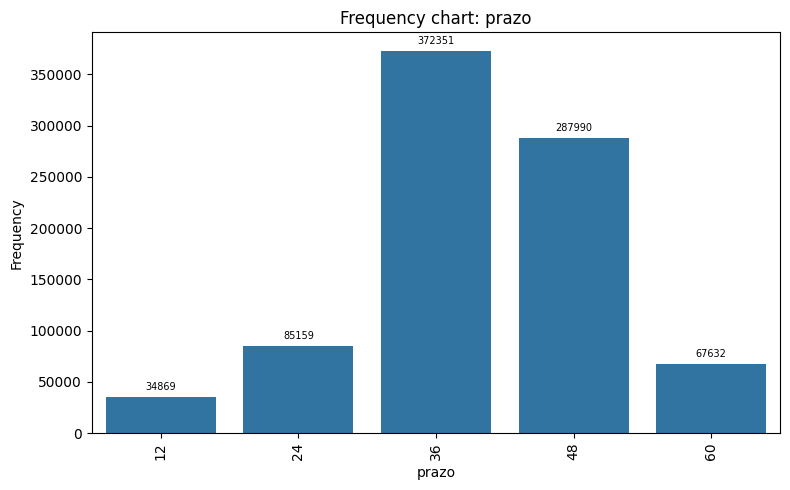

In [94]:
univariate_categorical_variable(df, 'prazo')

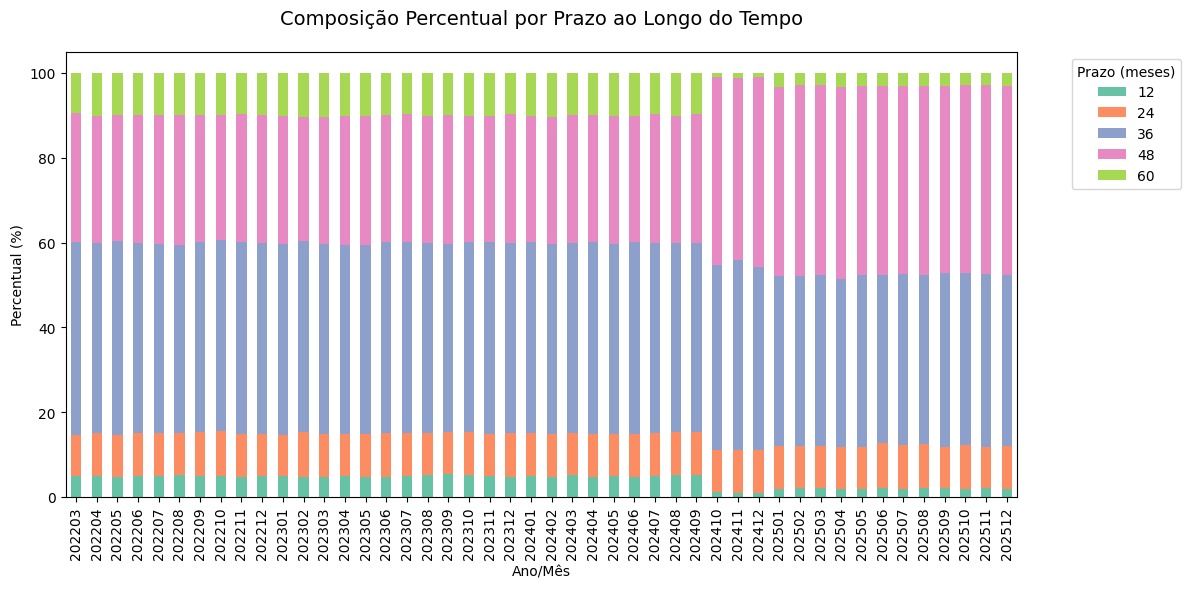

In [95]:
# Preparar os dados
# Calcular a contagem de veículos por mês e variavel
dfG10 = df.groupby(['ano_mes', 'prazo']).size().reset_index(name='contagem')

# Calcular o total de veículos por mês
total_mes = df.groupby('ano_mes').size().reset_index(name='total')

# Juntar os dados e calcular a porcentagem
dfG10 = dfG10.merge(total_mes, on='ano_mes')
dfG10['percentual'] = (dfG10['contagem'] / dfG10['total']) * 100

# Ordenar por ano_mês
dfG10 = dfG10.sort_values('ano_mes')

# Opção 2: Gráfico de barras empilhadas (mostra a composição total)
pivot_df = dfG10.pivot(index='ano_mes', columns='prazo', values='percentual')

cores_pastel = sns.color_palette("Set2", n_colors=len(pivot_df.columns))

pivot_df.plot(kind='bar', stacked=True, figsize=(12, 6), color=cores_pastel)

plt.title('Composição Percentual por Prazo ao Longo do Tempo', fontsize=14, pad=20)
plt.xlabel('Ano/Mês')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=90)
plt.legend(title='Prazo (meses)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [96]:
dfG10[(dfG10['ano_mes'] >= 202405) & (dfG10['ano_mes'] <= 202502)]

,ano_mes,prazo,contagem,total,percentual
130,202405,12,1003,20172,4.972239
131,202405,24,1973,20172,9.780884
132,202405,36,9036,20172,44.794765
133,202405,48,6136,20172,30.418402
134,202405,60,2024,20172,10.033710
135,202406,12,941,19717,4.772531
136,202406,24,1983,19717,10.057311
137,202406,36,8921,19717,45.245220
138,202406,48,5877,19717,29.806766
139,202406,60,1995,19717,10.118172


#### <span style="color:purple">Nota</span>
- Mudança em Set/2024 onde a quantidade de parcelas 12 e 60 (meses) cai e há um aumento nas de 48 (meses.)

### Var: `pmt`

In [97]:
univariate_missing_analysis(df, 'pmt')

# missing_var_when_flag_1(df, 'pmt', flags)

Missing Value Analysis for: pmt
Category  Count Percentage
 Missing      0      0.00%
 Present 848001    100.00%
   Total 848001       100%


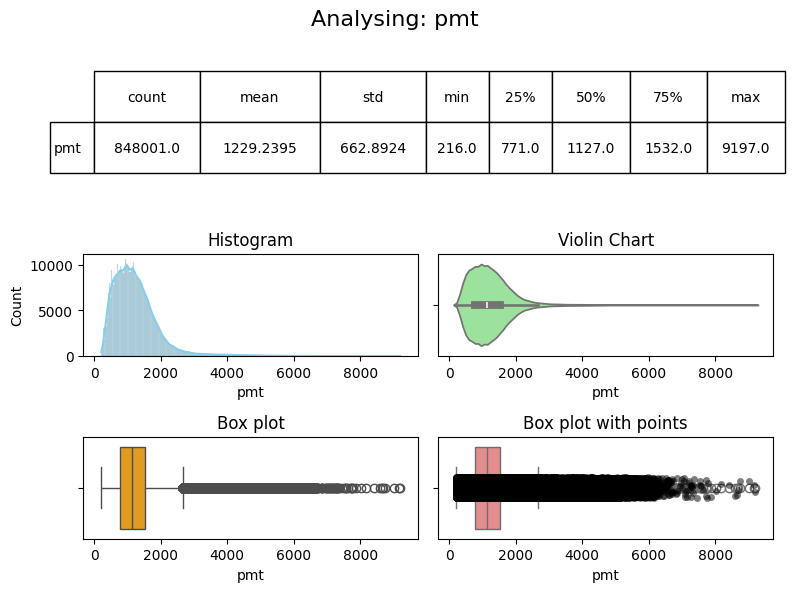

In [98]:
univariate_numeric_variable(df, 'pmt')

C:\Users\kel_m\AppData\Local\Temp\ipykernel_29148\3208365063.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




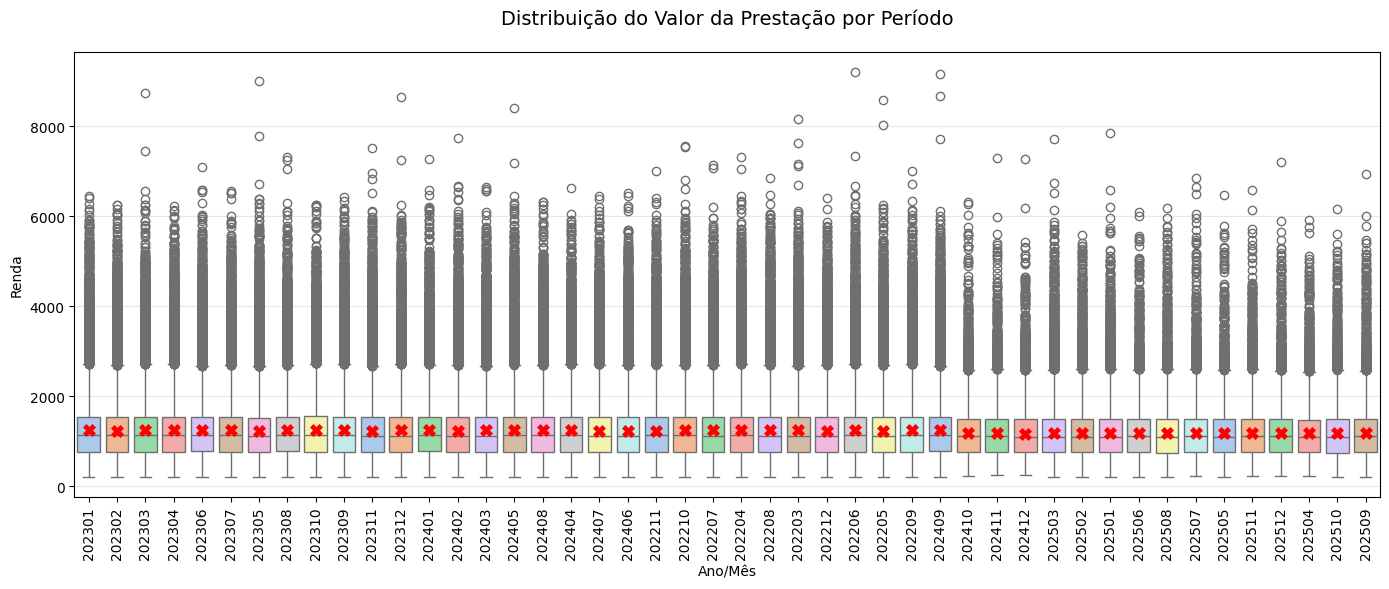

In [99]:
# Preparar os dados
df_box = df[['ano_mes', 'pmt']].dropna()
df_box['ano_mes'] = df_box['ano_mes'].astype(str)

plt.figure(figsize=(14, 6))

# Boxplot com média como "X"
sns.boxplot(data=df_box, x='ano_mes', y='pmt', 
            palette='pastel',
            showmeans=True,           # Mostrar média
            meanprops={
                'marker': 'X',         # Formato do marcador
                'markerfacecolor': 'red',  # Cor interna
                'markeredgecolor': 'red',  # Cor da borda
                'markersize': 8,       # Tamanho do marcador
                'markeredgewidth': 0.5   # Espessura da borda
            })

plt.title('Distribuição do Valor da Prestação por Período', fontsize=14, pad=20)
plt.xlabel('Ano/Mês')
plt.ylabel('Renda')
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

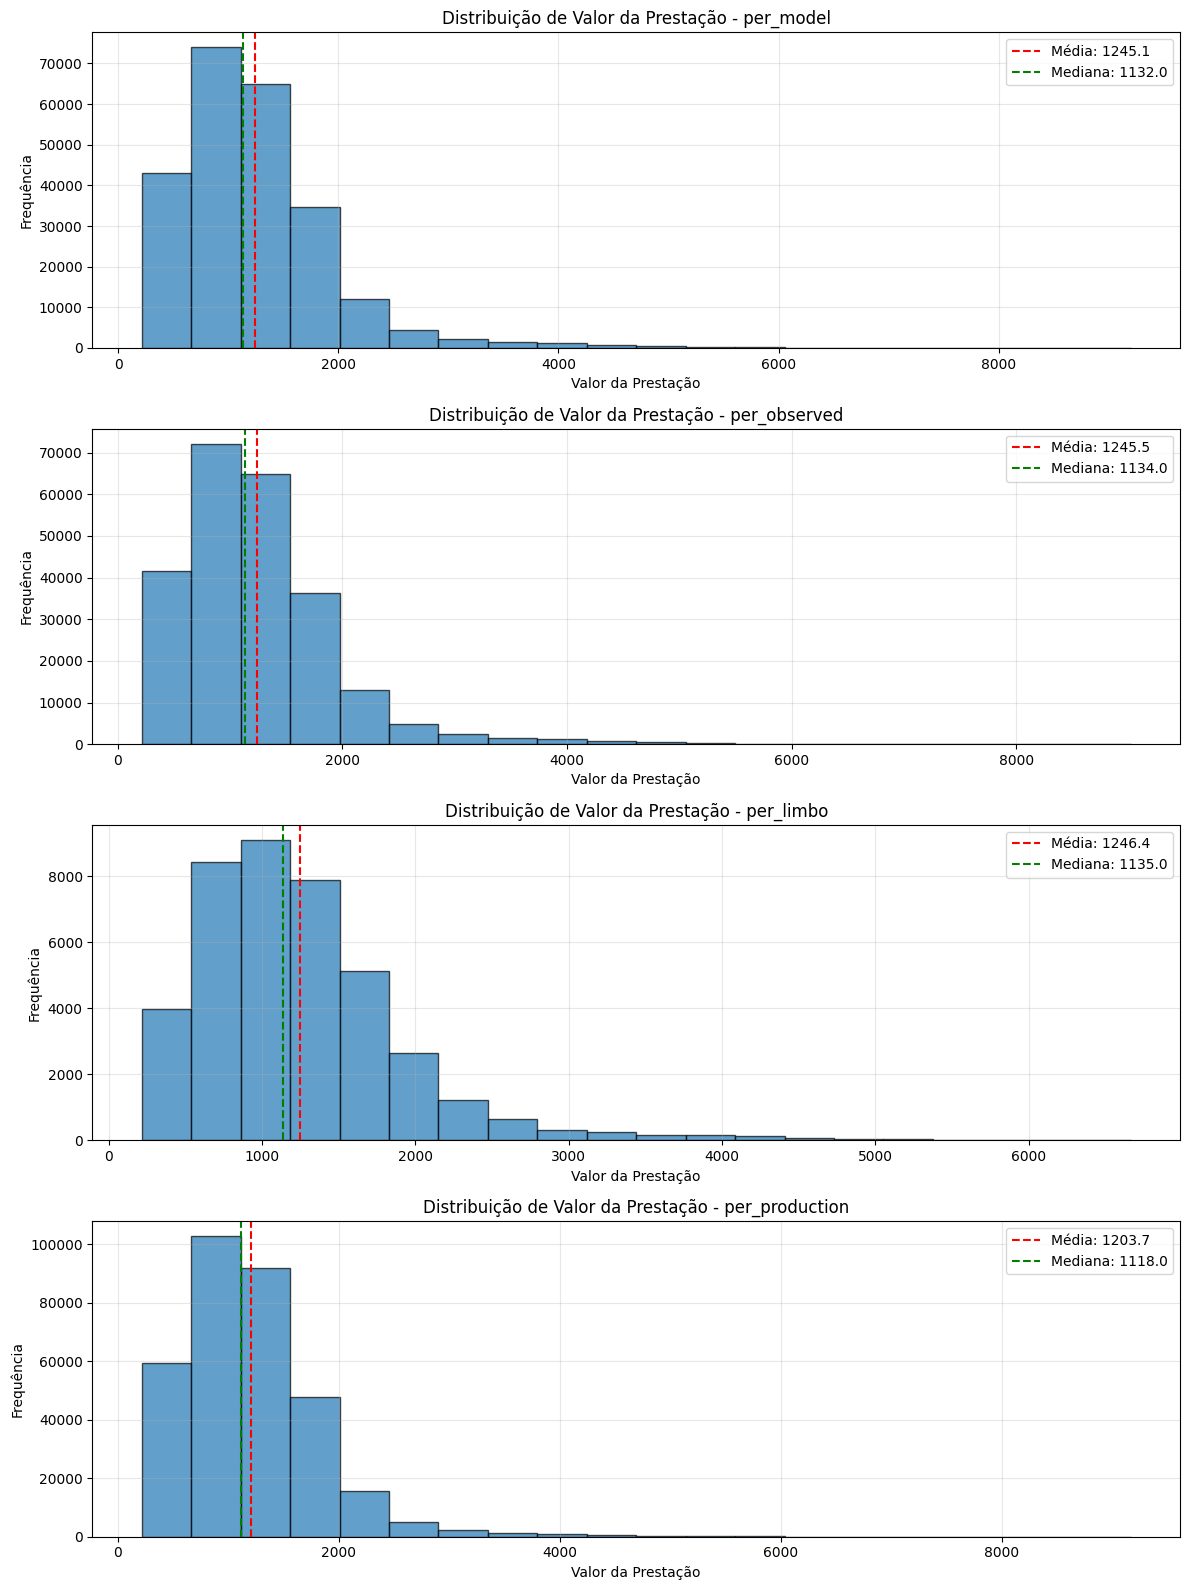

In [100]:
n_periodos = len(flags)

# Criar subplots
fig, axes = plt.subplots(nrows=n_periodos, ncols=1, figsize=(12, 4*n_periodos))
if n_periodos == 1:
    axes = [axes]

for i, periodo in enumerate(flags):
    # CORREÇÃO: Filtrar linhas onde a coluna do período é 1 e pegar a variavel
    dados_periodo = df[df[periodo] == 1]['pmt'].dropna()
    
    # Criar histograma
    axes[i].hist(dados_periodo, bins=20, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribuição de Valor da Prestação - {periodo}', fontsize=12)
    axes[i].set_xlabel('Valor da Prestação')
    axes[i].set_ylabel('Frequência')
    axes[i].grid(True, alpha=0.3)
    
    # Adicionar estatísticas (com verificação se há dados)
    if len(dados_periodo) > 0:
        media = dados_periodo.mean()
        mediana = dados_periodo.median()
        axes[i].axvline(media, color='red', linestyle='--', label=f'Média: {media:.1f}')
        axes[i].axvline(mediana, color='green', linestyle='--', label=f'Mediana: {mediana:.1f}')
        axes[i].legend()
    else:
        axes[i].text(0.5, 0.5, 'Sem dados para este período', 
                    transform=axes[i].transAxes, ha='center')

plt.tight_layout()
plt.show()

#### <span style="color:purple">Nota</span>
- distribuição assimetrica
- valor da mediana em 1,127 e da média de 1,229

### Var: `FPD`

In [101]:
univariate_missing_analysis(df, 'FPD')

missing_var_when_flag_1(df, 'FPD', flags)

Missing Value Analysis for: FPD
Category  Count Percentage
 Missing 192550     22.71%
 Present 655451     77.29%
   Total 848001       100%

 MISSING VALUES IN 'var' WHEN FLAG = 1
   Flag_Column Rows_When_Flag_1 var_Missing var_Present Missing_% vs_Overall
     per_model          239,889      57,829     182,060    24.11%     +1.40%
  per_observed          239,940      58,482     181,458    24.37%     +1.67%
     per_limbo           40,237       9,915      30,322    24.64%     +1.94%
per_production          327,935      66,324     261,611    20.22%     -2.48%

📊 OVERALL (all rows):
   Total rows: 848,001
   var missing: 192,550 (22.71%)
   var present: 655,451 (77.29%)


,Flag_Column,Rows_When_Flag_1,var_Missing,var_Present,Missing_%,vs_Overall
0,per_model,"239,889","57,829","182,060",24.11%,+1.40%
1,per_observed,"239,940","58,482","181,458",24.37%,+1.67%
2,per_limbo,"40,237","9,915","30,322",24.64%,+1.94%
3,per_production,"327,935","66,324","261,611",20.22%,-2.48%


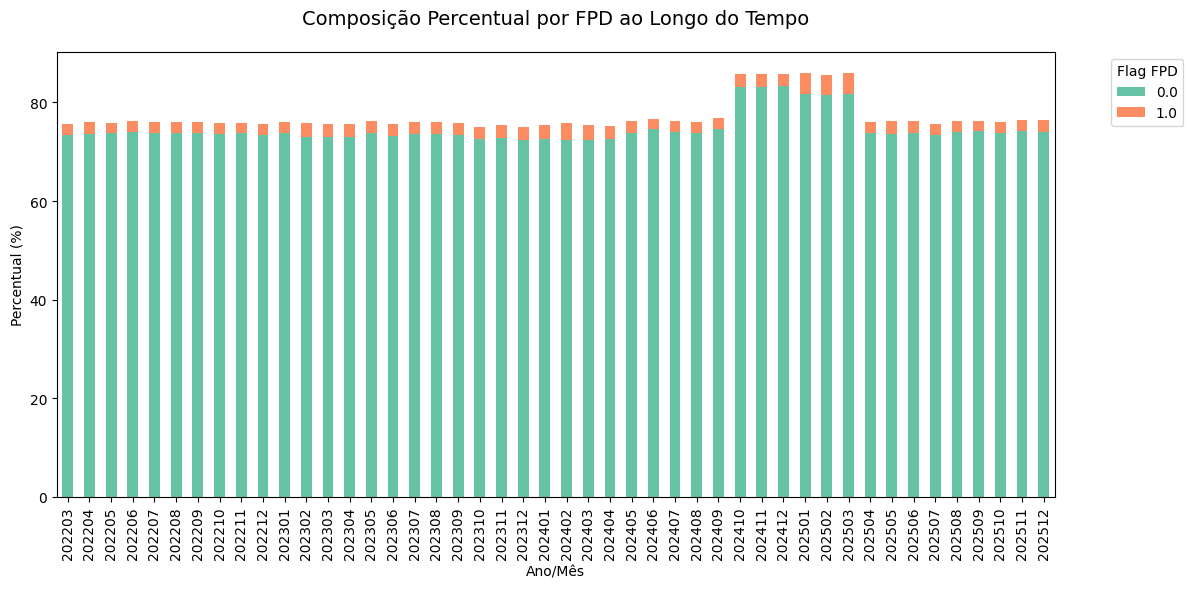

In [102]:
# Preparar os dados
# Calcular a contagem de veículos por mês e variavel
dfG11 = df.groupby(['ano_mes', 'FPD']).size().reset_index(name='contagem')

# Calcular o total de veículos por mês
total_mes = df.groupby('ano_mes').size().reset_index(name='total')

# Juntar os dados e calcular a porcentagem
dfG11 = dfG11.merge(total_mes, on='ano_mes')
dfG11['percentual'] = (dfG11['contagem'] / dfG11['total']) * 100

# Ordenar por ano_mês
dfG11 = dfG11.sort_values('ano_mes')

# Opção 2: Gráfico de barras empilhadas (mostra a composição total)
pivot_df = dfG11.pivot(index='ano_mes', columns='FPD', values='percentual')

cores_pastel = sns.color_palette("Set2", n_colors=len(pivot_df.columns))

pivot_df.plot(kind='bar', stacked=True, figsize=(12, 6), color=cores_pastel)

plt.title('Composição Percentual por FPD ao Longo do Tempo', fontsize=14, pad=20)
plt.xlabel('Ano/Mês')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=90)
plt.legend(title='Flag FPD', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

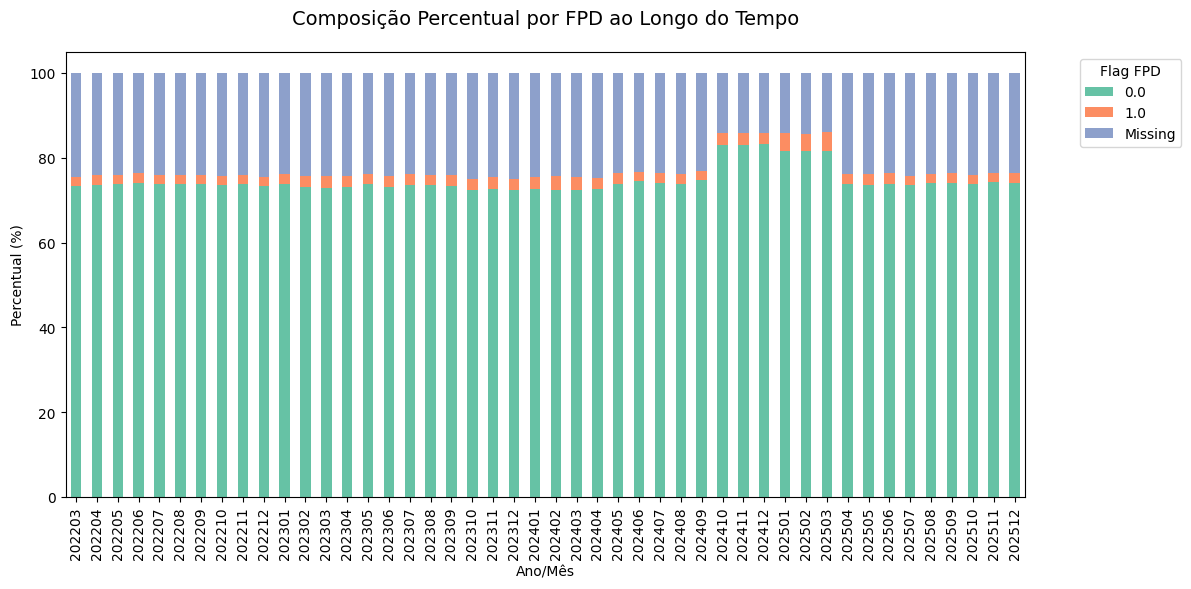

In [103]:
# Primeiro, criar uma cópia da coluna tratando os missing
df['FPD_categoria'] = df['FPD'].fillna('Missing').astype(str)

# Agora fazer o groupby com a nova coluna
dfG11a = df.groupby(['ano_mes', 'FPD_categoria']).size().reset_index(name='contagem')

# Calcular o total de veículos por mês
total_mes = df.groupby('ano_mes').size().reset_index(name='total')

# Juntar os dados e calcular a porcentagem
dfG11a = dfG11a.merge(total_mes, on='ano_mes')
dfG11a['percentual'] = (dfG11a['contagem'] / dfG11a['total']) * 100

# Ordenar por ano_mês
dfG11a = dfG11a.sort_values('ano_mes')

dfG11a

# Opção 2: Gráfico de barras empilhadas (mostra a composição total)
pivot_df = dfG11a.pivot(index='ano_mes', columns='FPD_categoria', values='percentual')

cores_pastel = sns.color_palette("Set2", n_colors=len(pivot_df.columns))

pivot_df.plot(kind='bar', stacked=True, figsize=(12, 6), color=cores_pastel)

plt.title('Composição Percentual por FPD ao Longo do Tempo', fontsize=14, pad=20)
plt.xlabel('Ano/Mês')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=90)
plt.legend(title='Flag FPD', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [104]:
dfG11a[(dfG11a['ano_mes'] >= 202407) & (dfG11a['ano_mes'] <= 202504)]

,ano_mes,FPD_categoria,contagem,total,percentual
84,202407,0.0,14855,20064,74.038078
85,202407,1.0,457,20064,2.277711
86,202407,Missing,4752,20064,23.684211
87,202408,0.0,14725,19951,73.805824
88,202408,1.0,454,19951,2.275575
89,202408,Missing,4772,19951,23.918601
90,202409,0.0,14958,20031,74.674255
91,202409,1.0,442,20031,2.206580
92,202409,Missing,4631,20031,23.119165
93,202410,0.0,16681,20085,83.052029


#### <span style="color:purple">Nota</span>
- tenho 22.7% de missing
- Percentual de missing depois que o modelo é colocado em produção (Maio/2024), cai 2% e no periodo de observação era de 24.3%


### Var: `score` 

In [105]:
univariate_missing_analysis(df, 'score')

# missing_var_when_flag_1(df, 'score', flags)

Missing Value Analysis for: score
Category  Count Percentage
 Missing      0      0.00%
 Present 848001    100.00%
   Total 848001       100%


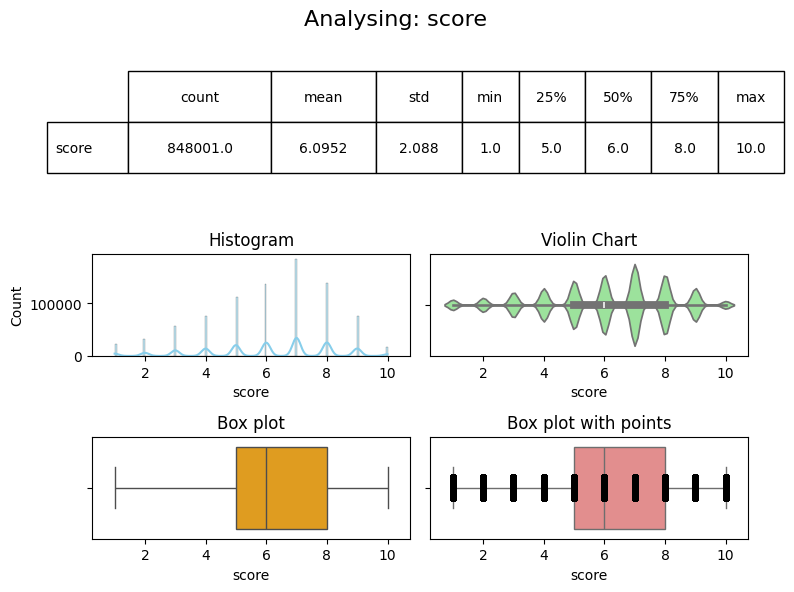

In [106]:
univariate_numeric_variable(df, "score")

Categorical variable describe:


,count,mean,std,min,25%,50%,75%,max
score,848001.0,6.095159,2.087986,1.0,5.0,6.0,8.0,10.0


Frequency table of categorical variable (with percentage and total):


,score,Frequency,Percentage (%)
0,7,183947,21.69
1,8,137592,16.23
2,6,136073,16.05
3,5,110561,13.04
4,9,75867,8.95
5,4,74875,8.83
6,3,56918,6.71
7,2,31635,3.73
8,1,23396,2.76
9,10,17137,2.02


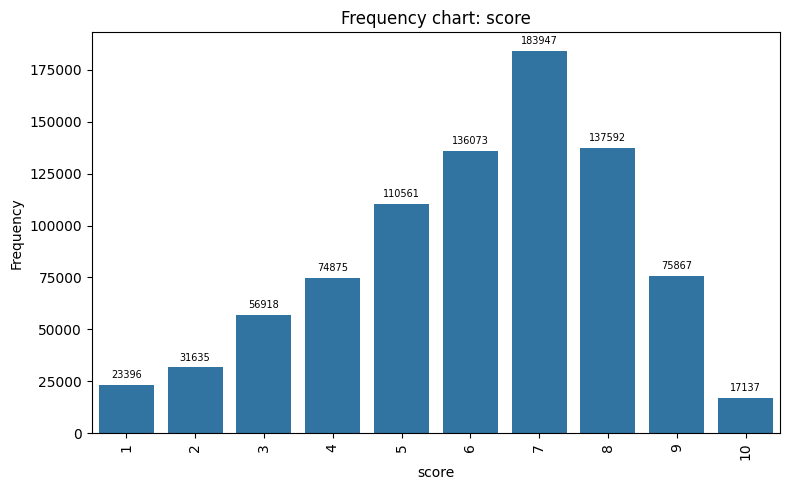

In [107]:
univariate_categorical_variable(df, 'score')

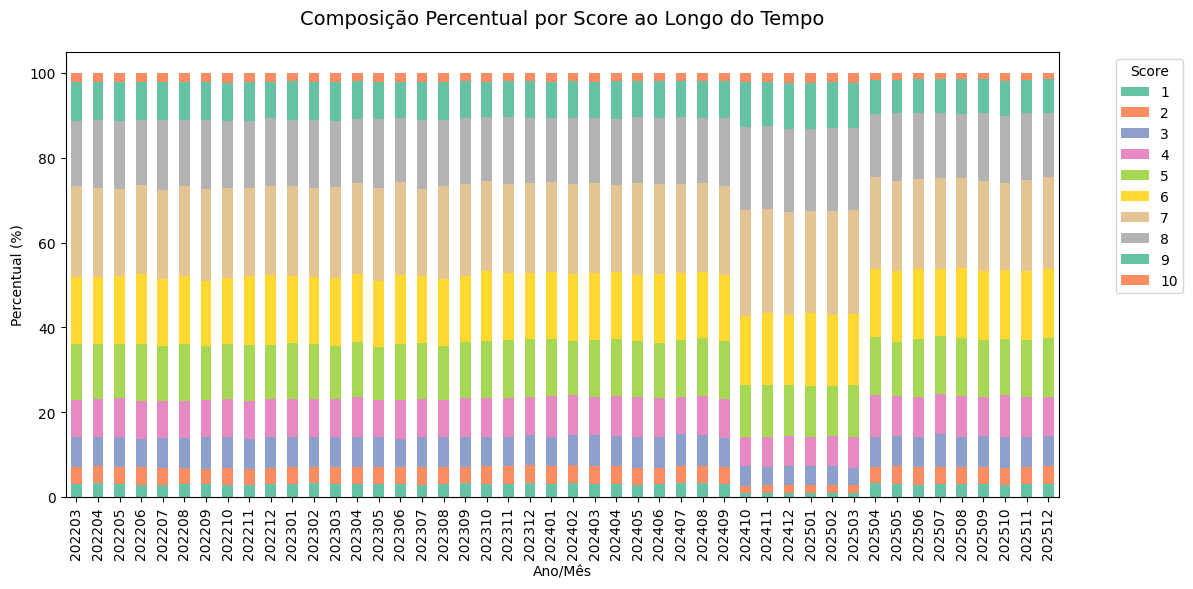

In [108]:
# Preparar os dados
# Calcular a contagem de veículos por mês e variavel
dfG12 = df.groupby(['ano_mes', 'score']).size().reset_index(name='contagem')

# Calcular o total de veículos por mês
total_mes = df.groupby('ano_mes').size().reset_index(name='total')

# Juntar os dados e calcular a porcentagem
dfG12 = dfG12.merge(total_mes, on='ano_mes')
dfG12['percentual'] = (dfG12['contagem'] / dfG12['total']) * 100

# Ordenar por ano_mês
dfG12 = dfG12.sort_values('ano_mes')

# Opção 2: Gráfico de barras empilhadas (mostra a composição total)
pivot_df = dfG12.pivot(index='ano_mes', columns='score', values='percentual')

cores_pastel = sns.color_palette("Set2", n_colors=len(pivot_df.columns))

pivot_df.plot(kind='bar', stacked=True, figsize=(12, 6), color=cores_pastel)

plt.title('Composição Percentual por Score ao Longo do Tempo', fontsize=14, pad=20)
plt.xlabel('Ano/Mês')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=90)
plt.legend(title='Score', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [109]:
dfG12[(dfG12['ano_mes'] >= 202411) & (dfG12['ano_mes'] <= 202504)]

,ano_mes,score,contagem,total,percentual
320,202411,1,174,19844,0.876839
321,202411,2,390,19844,1.965330
322,202411,3,851,19844,4.288450
323,202411,4,1415,19844,7.130619
324,202411,5,2405,19844,12.119532
325,202411,6,3382,19844,17.042935
326,202411,7,4879,19844,24.586777
327,202411,8,3867,19844,19.486999
328,202411,9,2069,19844,10.426325
329,202411,10,412,19844,2.076194


#### <span style="color:purple">Nota</span>
- Redução dos scores 1 até 4 no periodo de Set/2024 a Fev/2025


### Var: `contratado`

In [110]:
univariate_missing_analysis(df, 'contratado')

missing_var_when_flag_1(df, 'contratado', flags)

Missing Value Analysis for: contratado
Category  Count Percentage
 Missing      0      0.00%
 Present 848001    100.00%
   Total 848001       100%

 MISSING VALUES IN 'var' WHEN FLAG = 1
   Flag_Column Rows_When_Flag_1 var_Missing var_Present Missing_% vs_Overall
     per_model          239,889           0     239,889     0.00%     +0.00%
  per_observed          239,940           0     239,940     0.00%     +0.00%
     per_limbo           40,237           0      40,237     0.00%     +0.00%
per_production          327,935           0     327,935     0.00%     +0.00%

📊 OVERALL (all rows):
   Total rows: 848,001
   var missing: 0 (0.00%)
   var present: 848,001 (100.00%)


,Flag_Column,Rows_When_Flag_1,var_Missing,var_Present,Missing_%,vs_Overall
0,per_model,"239,889",0,"239,889",0.00%,+0.00%
1,per_observed,"239,940",0,"239,940",0.00%,+0.00%
2,per_limbo,"40,237",0,"40,237",0.00%,+0.00%
3,per_production,"327,935",0,"327,935",0.00%,+0.00%


In [111]:
df[pd.isna(df['contratado'])]

,id,ano_mes,idade_veiculo,marca,vl_bem,idade,estado_civil,qt_restr,renda,Regiao,...,nacionalidade,id_duplicado,flg_restr,per_model,per_observed,per_limbo,per_production,per_observed2,target_categoria,FPD_categoria


#### <span style="color:purple">Nota</span>
- 1 missing aqui represnta o caso com o vl_bem é a categoria com somente 1 observaçao
- como parece ser um erro pode ser removido da base.

### Var: `comp_renda`

In [112]:
univariate_missing_analysis(df, 'comp_renda')

# missing_var_when_flag_1(df, 'comp_renda', flags)

Missing Value Analysis for: comp_renda
Category  Count Percentage
 Missing      0      0.00%
 Present 848001    100.00%
   Total 848001       100%


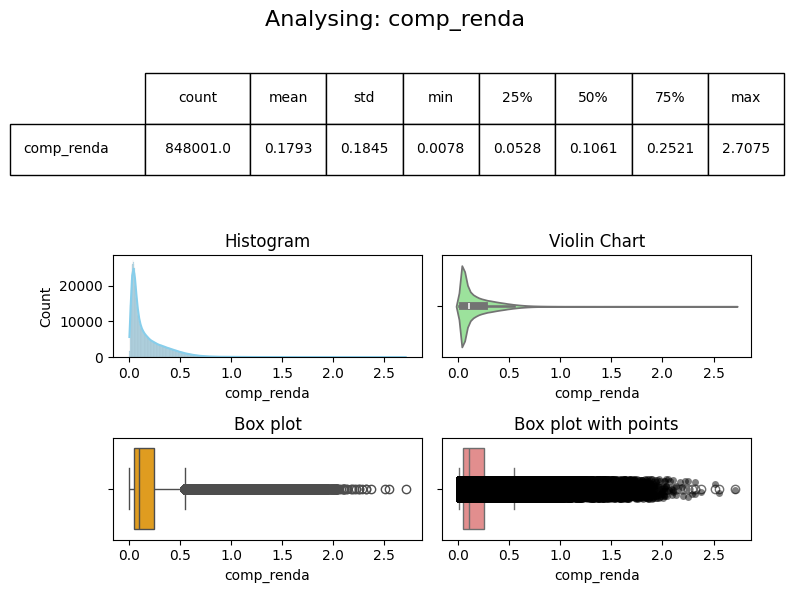

In [113]:
univariate_numeric_variable(df, 'comp_renda')

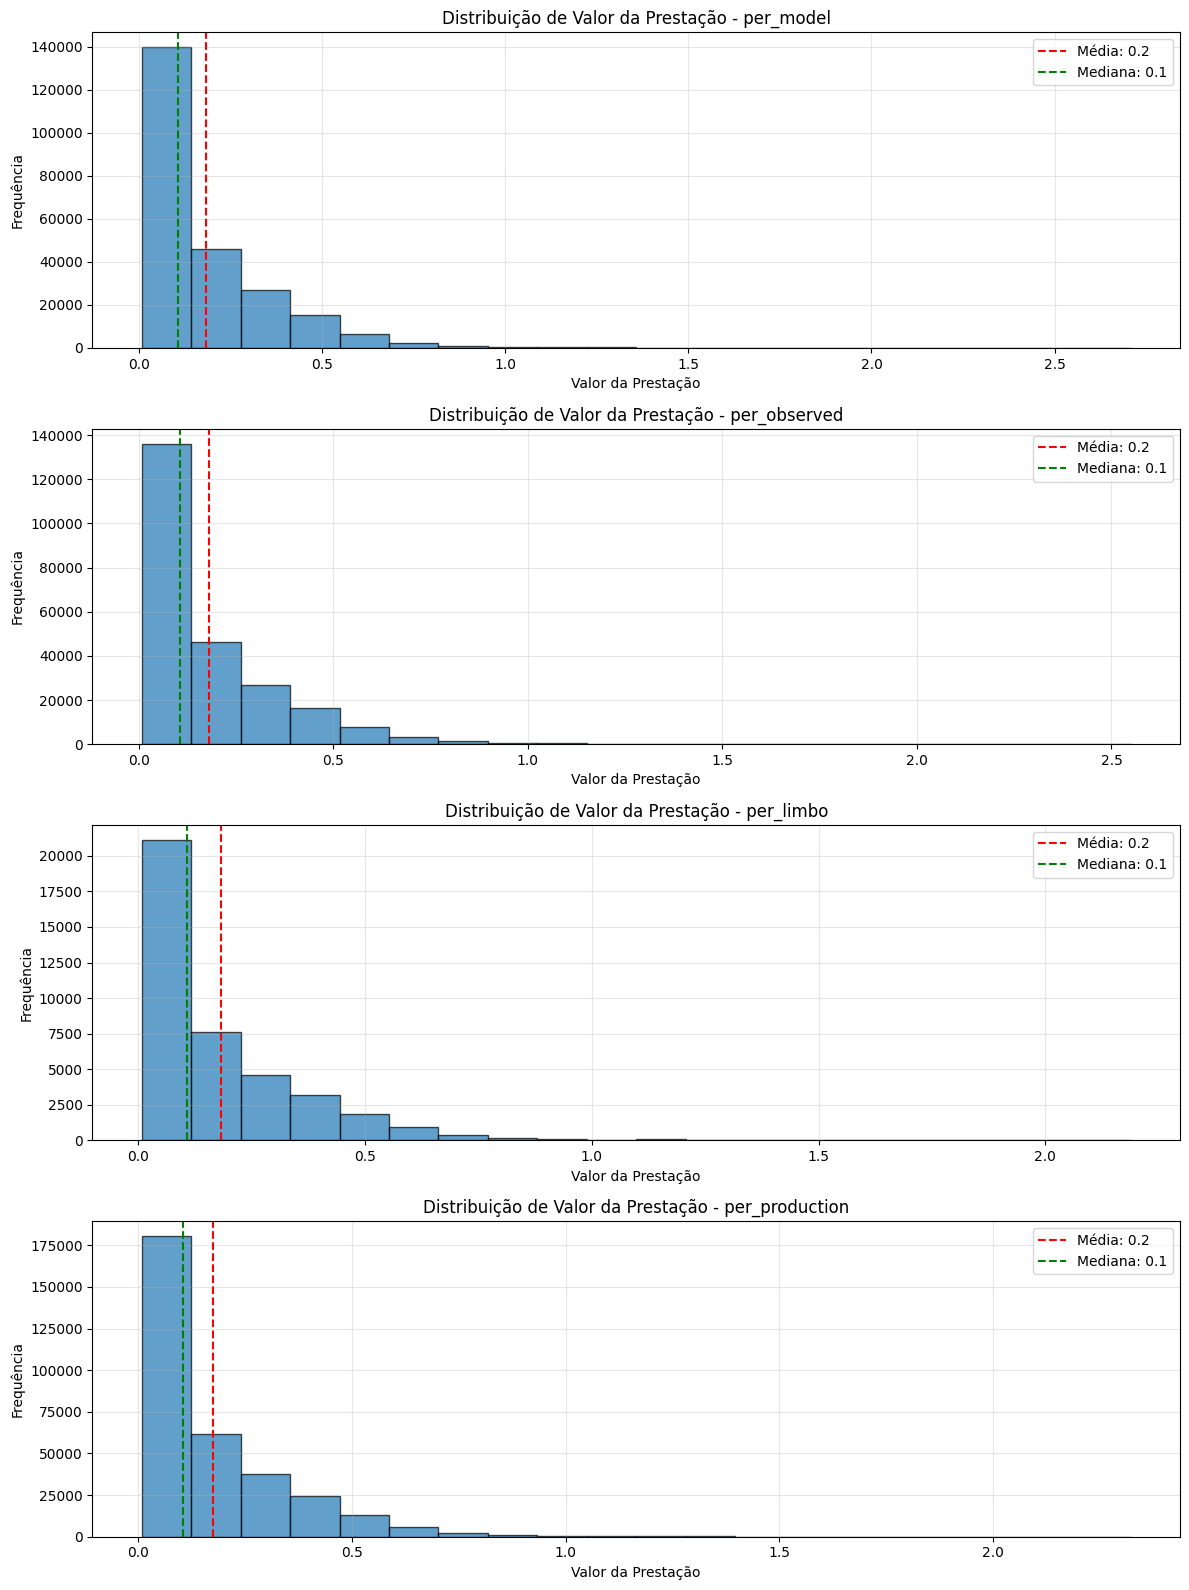

In [114]:
n_periodos = len(flags)

# Criar subplots
fig, axes = plt.subplots(nrows=n_periodos, ncols=1, figsize=(12, 4*n_periodos))
if n_periodos == 1:
    axes = [axes]

for i, periodo in enumerate(flags):
    # CORREÇÃO: Filtrar linhas onde a coluna do período é 1 e pegar a variavel
    dados_periodo = df[df[periodo] == 1]['comp_renda'].dropna()
    
    # Criar histograma
    axes[i].hist(dados_periodo, bins=20, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribuição de Valor da Prestação - {periodo}', fontsize=12)
    axes[i].set_xlabel('Valor da Prestação')
    axes[i].set_ylabel('Frequência')
    axes[i].grid(True, alpha=0.3)
    
    # Adicionar estatísticas (com verificação se há dados)
    if len(dados_periodo) > 0:
        media = dados_periodo.mean()
        mediana = dados_periodo.median()
        axes[i].axvline(media, color='red', linestyle='--', label=f'Média: {media:.1f}')
        axes[i].axvline(mediana, color='green', linestyle='--', label=f'Mediana: {mediana:.1f}')
        axes[i].legend()
    else:
        axes[i].text(0.5, 0.5, 'Sem dados para este período', 
                    transform=axes[i].transAxes, ha='center')

plt.tight_layout()
plt.show()

C:\Users\kel_m\AppData\Local\Temp\ipykernel_29148\3557724484.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




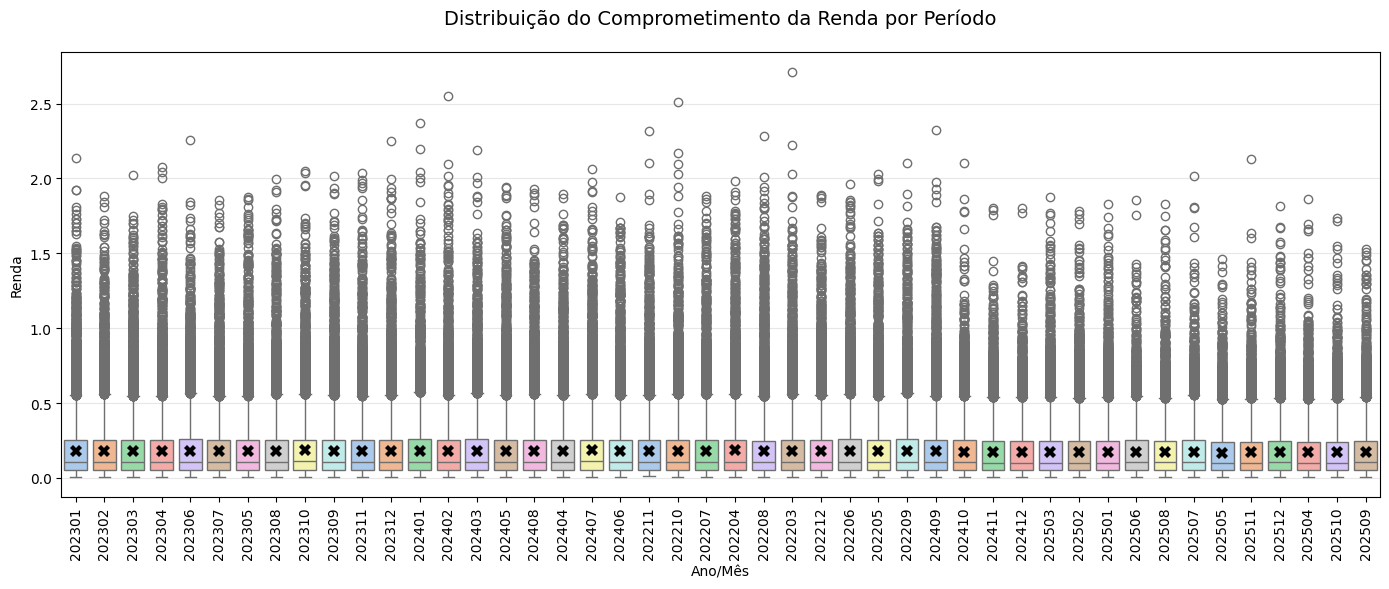

In [115]:
# Preparar os dados
df_box = df[['ano_mes', 'comp_renda']].dropna()
df_box['ano_mes'] = df_box['ano_mes'].astype(str)

plt.figure(figsize=(14, 6))

# Boxplot com média como "X"
sns.boxplot(data=df_box, x='ano_mes', y='comp_renda', 
            palette='pastel',
            showmeans=True,           # Mostrar média
            meanprops={
                'marker': 'X',         # Formato do marcador
                'markerfacecolor': 'black',  # Cor interna
                'markeredgecolor': 'black',  # Cor da borda
                'markersize': 8,       # Tamanho do marcador
                'markeredgewidth': 0.01   # Espessura da borda
            })

plt.title('Distribuição do Comprometimento da Renda por Período', fontsize=14, pad=20)
plt.xlabel('Ano/Mês')
plt.ylabel('Renda')
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

#### <span style="color:purple">Nota</span>
- parece ok

### Var: `nacionalidade`

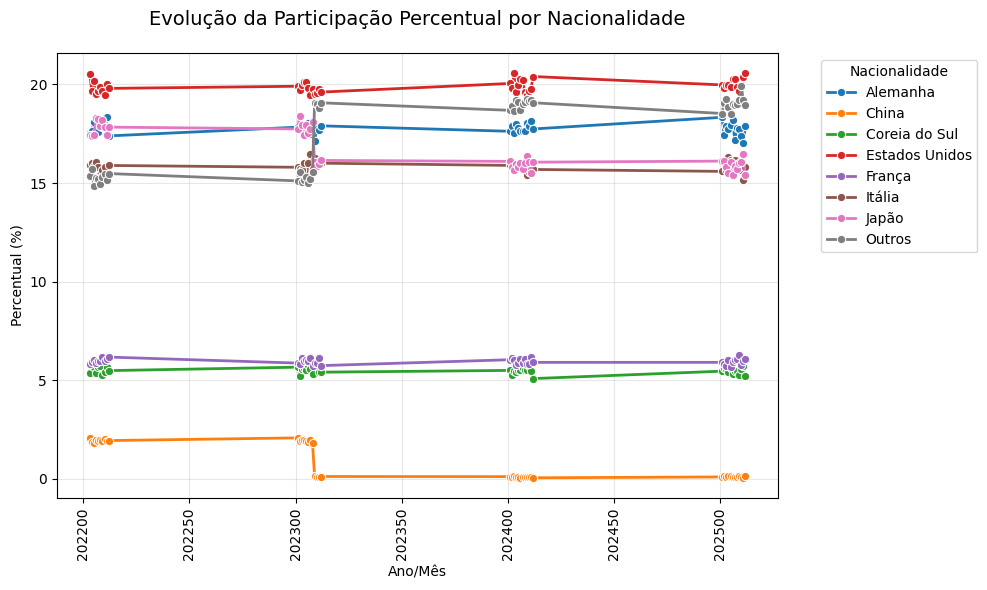

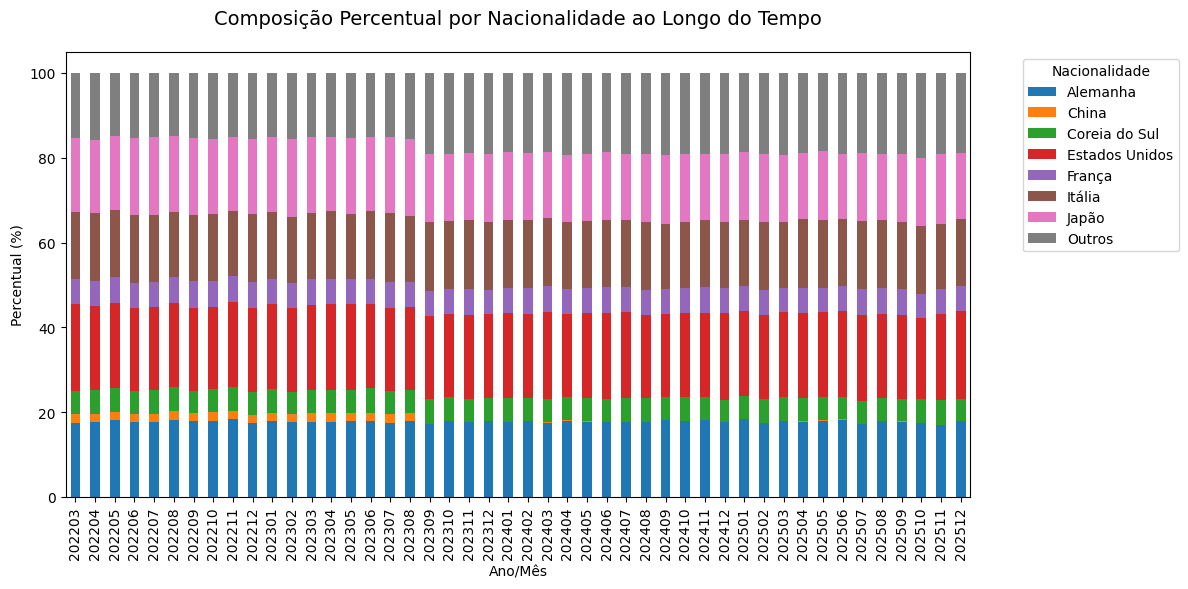

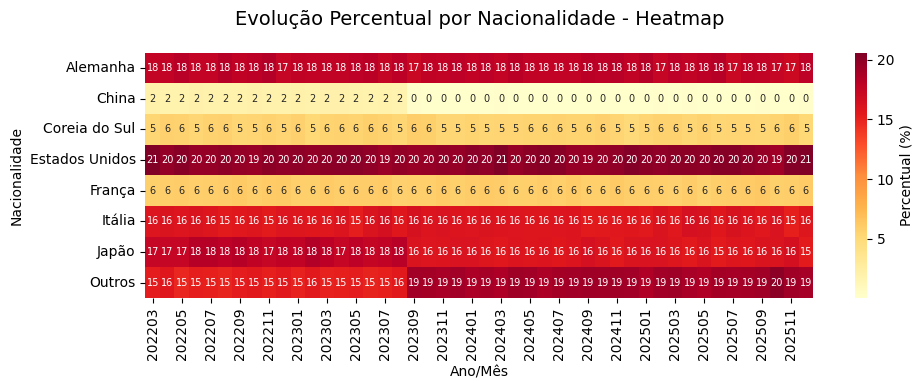

In [116]:
# Preparar os dados
# Calcular a contagem de veículos por mês e marca
nacionalidade_mes = df.groupby(['ano_mes', 'nacionalidade']).size().reset_index(name='contagem')

# Calcular o total de veículos por mês
total_mes = df.groupby('ano_mes').size().reset_index(name='total')

# Juntar os dados e calcular a porcentagem
nacionalidade_mes = nacionalidade_mes.merge(total_mes, on='ano_mes')
nacionalidade_mes['percentual'] = (nacionalidade_mes['contagem'] / nacionalidade_mes['total']) * 100

# Ordenar por ano_mês
nacionalidade_mes = nacionalidade_mes.sort_values('ano_mes')

# Criar o gráfico
plt.figure(figsize=(10, 6))

# Opção 1: Gráfico de linhas (melhor para visualizar tendências)
sns.lineplot(data=nacionalidade_mes, x='ano_mes', y='percentual', 
             hue='nacionalidade', marker='o', linewidth=2)

plt.title('Evolução da Participação Percentual por Nacionalidade', fontsize=14, pad=20)
plt.xlabel('Ano/Mês')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=90)
plt.legend(title='Nacionalidade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Opção 2: Gráfico de barras empilhadas (mostra a composição total)
pivot_df = nacionalidade_mes.pivot(index='ano_mes', columns='nacionalidade', values='percentual')

pivot_df.plot(kind='bar', stacked=True, figsize=(12, 6))

plt.title('Composição Percentual por Nacionalidade ao Longo do Tempo', fontsize=14, pad=20)
plt.xlabel('Ano/Mês')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=90)
plt.legend(title='Nacionalidade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Opção 3: Heatmap da evolução
pivot_heatmap = nacionalidade_mes.pivot(index='nacionalidade', columns='ano_mes', values='percentual')

plt.figure(figsize=(10, len(pivot_heatmap) * 0.5))
sns.heatmap(pivot_heatmap, annot=True, fmt='.0f', cmap='YlOrRd', 
            cbar_kws={'label': 'Percentual (%)'},
            annot_kws={'size': 7})

plt.title('Evolução Percentual por Nacionalidade - Heatmap', fontsize=14, pad=20)
plt.xlabel('Ano/Mês')
plt.ylabel('Nacionalidade')
plt.tight_layout()
plt.show()

#### <span style="color:purple">Nota</span>
- Saída de Jac (China) e Nissan (Japão) fazendo que que essas nacionalidades sejam reduzidas. O Japão ainda se sustenta com a Toyota
- Aumento nos "outros", contudo JAC e Nissan ainda aparecem como Marcas e não foram incluidas em "Outros"

## EDA - Bivariada

### Todas Contra a target

ANÁLISE BIVARIADA POR PERÍODO - ESCALA PADRONIZADA

1. DISTRIBUIÇÃO POR PERÍODO:
periodo
Produção (Mai/24 em diante)    327935
Observação (Mar/23-Fev/24)     280177
Modelagem (Mar/22-Fev/23)      239889
Name: count, dtype: int64

Percentuais:
periodo
Produção (Mai/24 em diante)    38.67
Observação (Mar/23-Fev/24)     33.04
Modelagem (Mar/22-Fev/23)      28.29
Name: proportion, dtype: float64

2. ANÁLISE DA VARIÁVEL TARGET POR PERÍODO

Estatísticas do target por período:
                              count    mean     std  min  max  median
periodo                                                              
Modelagem (Mar/22-Fev/23)    182060  0.1214  0.3266  0.0  1.0     0.0
Observação (Mar/23-Fev/24)   211780  0.1430  0.3500  0.0  1.0     0.0
Produção (Mai/24 em diante)  261611  0.0592  0.2360  0.0  1.0     0.0

Teste ANOVA - diferença entre períodos:
F-statistic: 4931.7581
p-value: 0.0000
Há diferença significativa: Sim

4. ANÁLISE DAS VARIÁVEIS CATEGÓRICAS

ANÁLISE: estado_civil vs

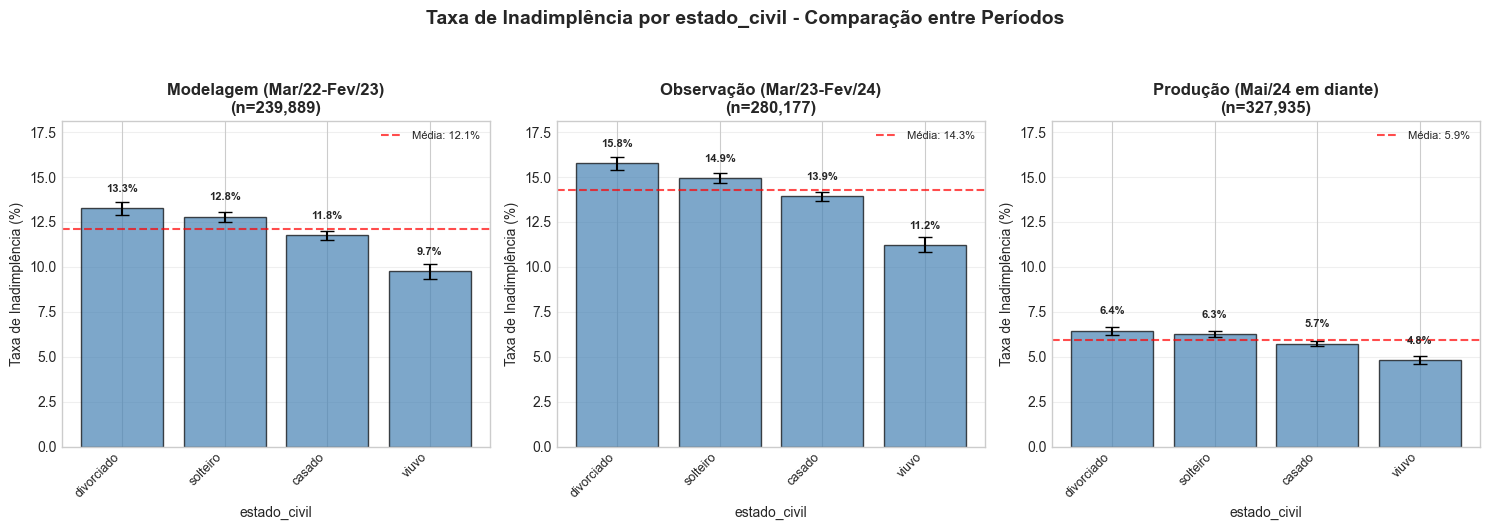


RESUMO POR PERÍODO:

--- Modelagem (Mar/22-Fev/23) ---
Top 5 maiores taxas de inadimplência:
  divorciado: 13.27% (4647/35024)
  solteiro: 12.80% (6867/53654)
  casado: 11.76% (8661/73673)
  viuvo: 9.75% (1921/19709)

--- Observação (Mar/23-Fev/24) ---
Top 5 maiores taxas de inadimplência:
  divorciado: 15.77% (6489/41160)
  solteiro: 14.95% (9357/62594)
  casado: 13.92% (11906/85533)
  viuvo: 11.23% (2525/22493)

--- Produção (Mai/24 em diante) ---
Top 5 maiores taxas de inadimplência:
  divorciado: 6.44% (3213/49873)
  solteiro: 6.26% (4781/76317)
  casado: 5.72% (6091/106435)
  viuvo: 4.82% (1397/28986)

ANÁLISE: Regiao vs target POR PERÍODO


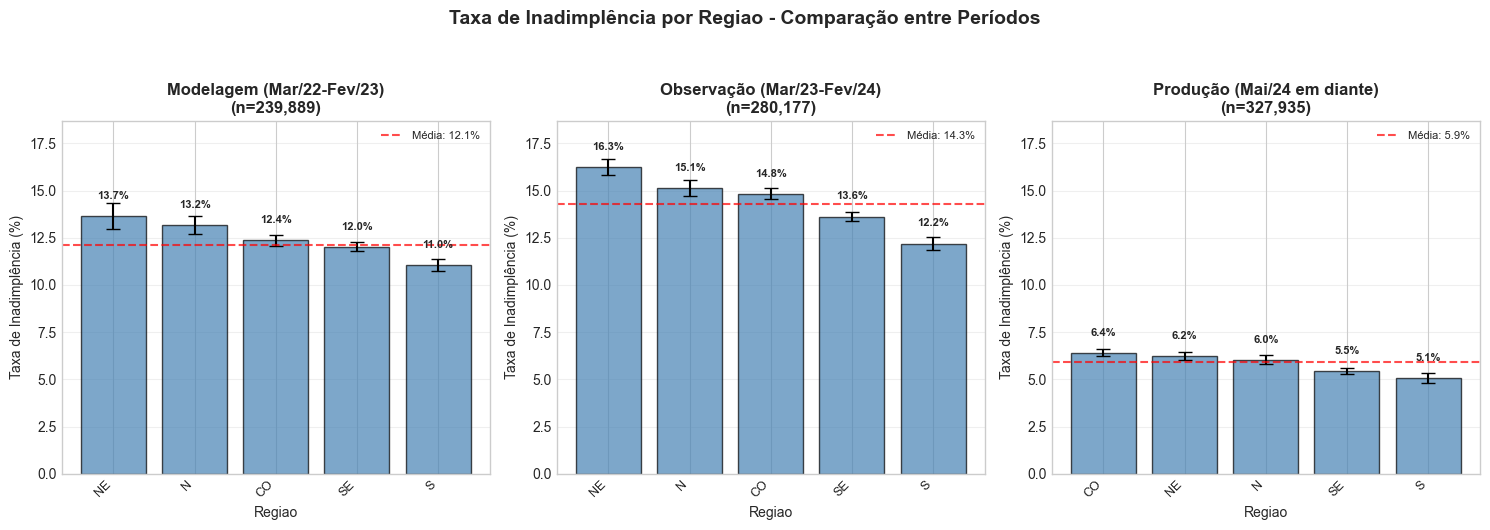


RESUMO POR PERÍODO:

--- Modelagem (Mar/22-Fev/23) ---
Top 5 maiores taxas de inadimplência:
  NE: 13.66% (1380/10106)
  N: 13.18% (2703/20501)
  CO: 12.37% (6148/49696)
  SE: 12.03% (7690/63939)
  S: 11.04% (4175/37818)

--- Observação (Mar/23-Fev/24) ---
Top 5 maiores taxas de inadimplência:
  NE: 16.25% (4649/28607)
  N: 15.12% (4241/28047)
  CO: 14.82% (8707/58749)
  SE: 13.62% (8844/64913)
  S: 12.19% (3836/31464)

--- Produção (Mai/24 em diante) ---
Top 5 maiores taxas de inadimplência:
  CO: 6.42% (4750/74031)
  NE: 6.22% (3128/50292)
  N: 6.05% (2295/37954)
  SE: 5.45% (3910/71727)
  S: 5.07% (1399/27607)

ANÁLISE: Profissao vs target POR PERÍODO


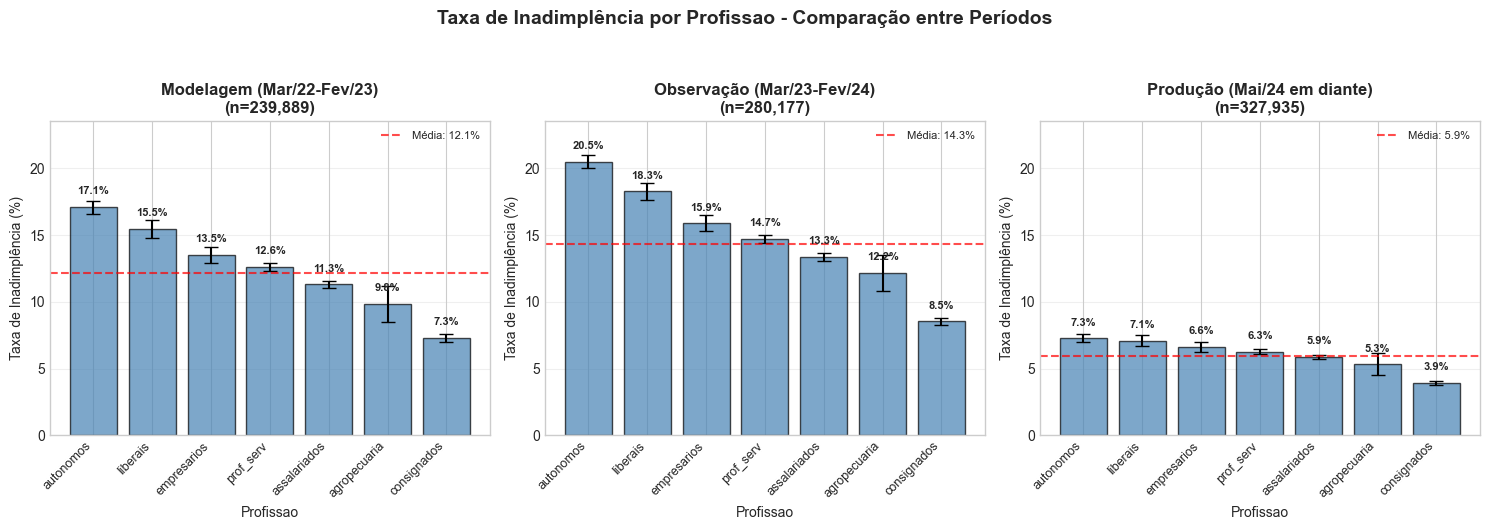


RESUMO POR PERÍODO:

--- Modelagem (Mar/22-Fev/23) ---
Top 5 maiores taxas de inadimplência:
  autonomos: 17.09% (3990/23347)
  liberais: 15.47% (1792/11586)
  empresarios: 13.50% (1663/12320)
  prof_serv: 12.60% (6843/54304)
  assalariados: 11.30% (5327/47146)

--- Observação (Mar/23-Fev/24) ---
Top 5 maiores taxas de inadimplência:
  autonomos: 20.48% (5514/26923)
  liberais: 18.28% (2465/13488)
  empresarios: 15.87% (2239/14110)
  prof_serv: 14.71% (9312/63316)
  assalariados: 13.34% (7339/54998)

--- Produção (Mai/24 em diante) ---
Top 5 maiores taxas de inadimplência:
  autonomos: 7.27% (2187/30096)
  liberais: 7.08% (1117/15774)
  empresarios: 6.64% (1152/17340)
  prof_serv: 6.26% (4964/79278)
  assalariados: 5.87% (4066/69287)

ANÁLISE: marca vs target POR PERÍODO


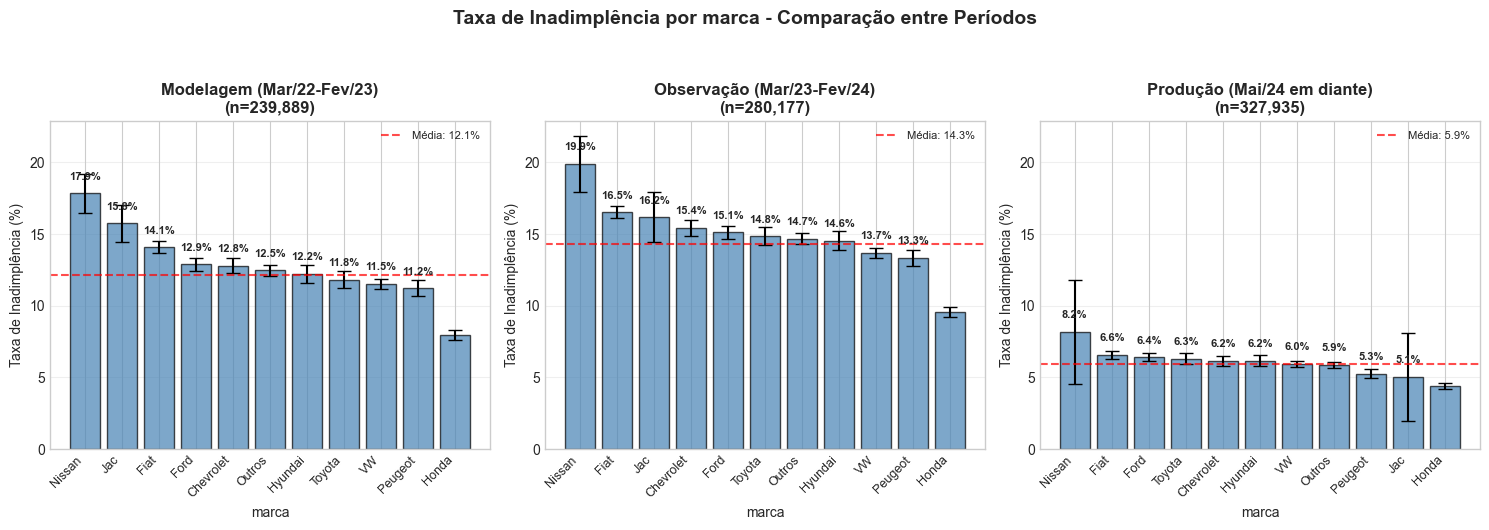


RESUMO POR PERÍODO:

--- Modelagem (Mar/22-Fev/23) ---
Top 5 maiores taxas de inadimplência:
  Nissan: 17.85% (543/3042)
  Jac: 15.75% (497/3155)
  Fiat: 14.09% (3817/27090)
  Ford: 12.89% (2722/21111)
  Chevrolet: 12.80% (1822/14231)

--- Observação (Mar/23-Fev/24) ---
Top 5 maiores taxas de inadimplência:
  Nissan: 19.91% (323/1622)
  Fiat: 16.53% (5249/31763)
  Jac: 16.18% (272/1681)
  Chevrolet: 15.43% (2541/16464)
  Ford: 15.13% (3739/24717)

--- Produção (Mai/24 em diante) ---
Top 5 maiores taxas de inadimplência:
  Nissan: 8.18% (18/220)
  Fiat: 6.58% (2465/37490)
  Ford: 6.42% (1951/30375)
  Toyota: 6.31% (989/15669)
  Chevrolet: 6.16% (1240/20115)

ANÁLISE: idade_veiculo vs target POR PERÍODO


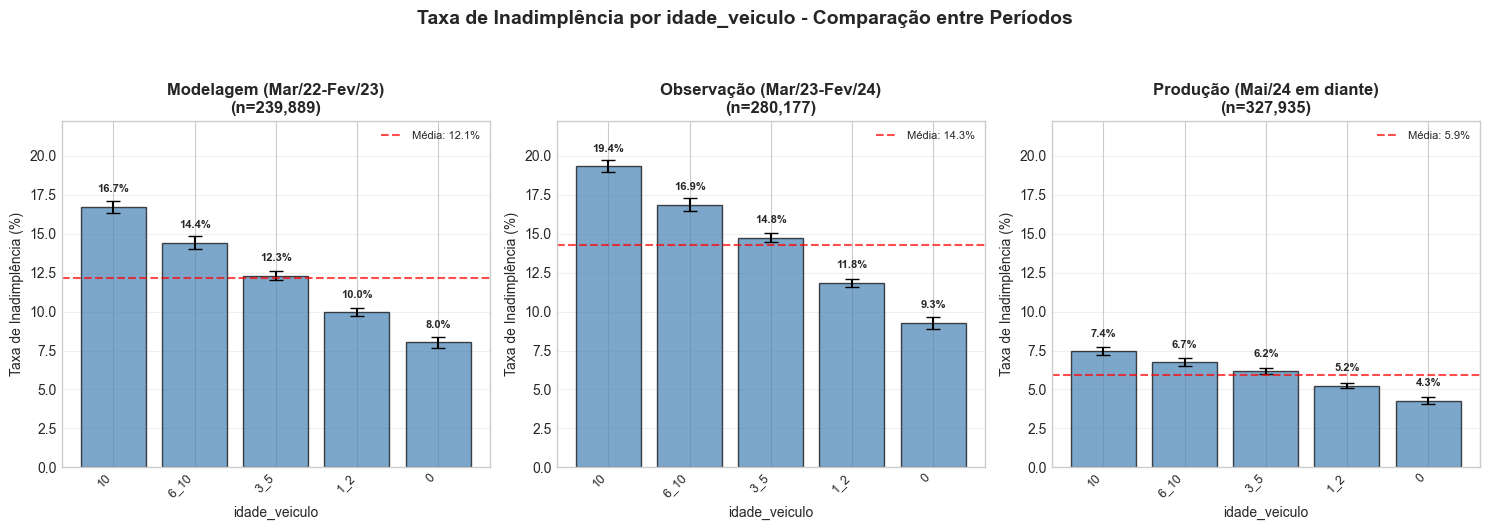


RESUMO POR PERÍODO:

--- Modelagem (Mar/22-Fev/23) ---
Top 5 maiores taxas de inadimplência:
  10: 16.73% (5287/31611)
  6_10: 14.42% (3725/25826)
  3_5: 12.30% (5563/45219)
  1_2: 9.97% (5885/59012)
  0: 8.02% (1636/20392)

--- Observação (Mar/23-Fev/24) ---
Top 5 maiores taxas de inadimplência:
  10: 19.35% (7103/36704)
  6_10: 16.86% (5071/30080)
  3_5: 14.75% (7817/52982)
  1_2: 11.85% (8067/68104)
  0: 9.28% (2219/23910)

--- Produção (Mai/24 em diante) ---
Top 5 maiores taxas de inadimplência:
  10: 7.44% (3085/41448)
  6_10: 6.74% (2428/36001)
  3_5: 6.16% (4083/66263)
  1_2: 5.25% (4576/87162)
  0: 4.26% (1310/30737)

ANÁLISE: nacionalidade vs target POR PERÍODO


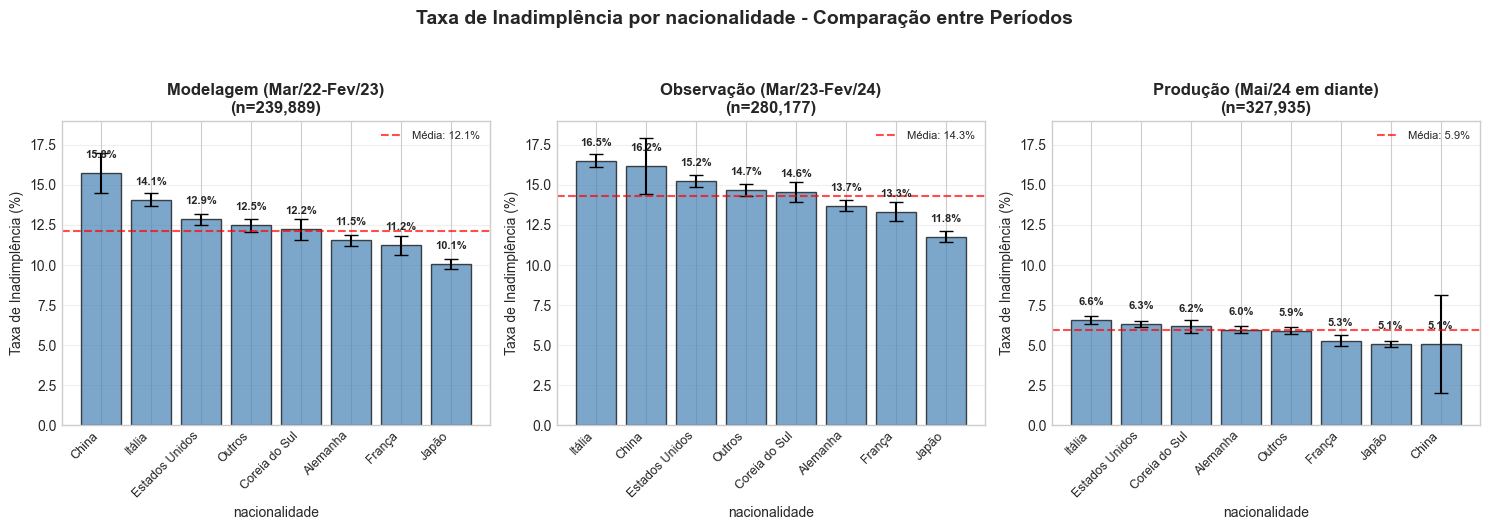


RESUMO POR PERÍODO:

--- Modelagem (Mar/22-Fev/23) ---
Top 5 maiores taxas de inadimplência:
  China: 15.75% (497/3155)
  Itália: 14.09% (3817/27090)
  Estados Unidos: 12.86% (4544/35342)
  Outros: 12.48% (3461/27728)
  Coreia do Sul: 12.23% (1229/10046)

--- Observação (Mar/23-Fev/24) ---
Top 5 maiores taxas de inadimplência:
  Itália: 16.53% (5249/31763)
  China: 16.18% (272/1681)
  Estados Unidos: 15.25% (6280/41181)
  Outros: 14.69% (5359/36470)
  Coreia do Sul: 14.55% (1705/11718)

--- Produção (Mai/24 em diante) ---
Top 5 maiores taxas de inadimplência:
  Itália: 6.58% (2465/37490)
  Estados Unidos: 6.32% (3191/50490)
  Coreia do Sul: 6.16% (882/14311)
  Alemanha: 5.96% (2832/47483)
  Outros: 5.90% (2917/49450)

ANÁLISE: FPD_categoria vs target POR PERÍODO


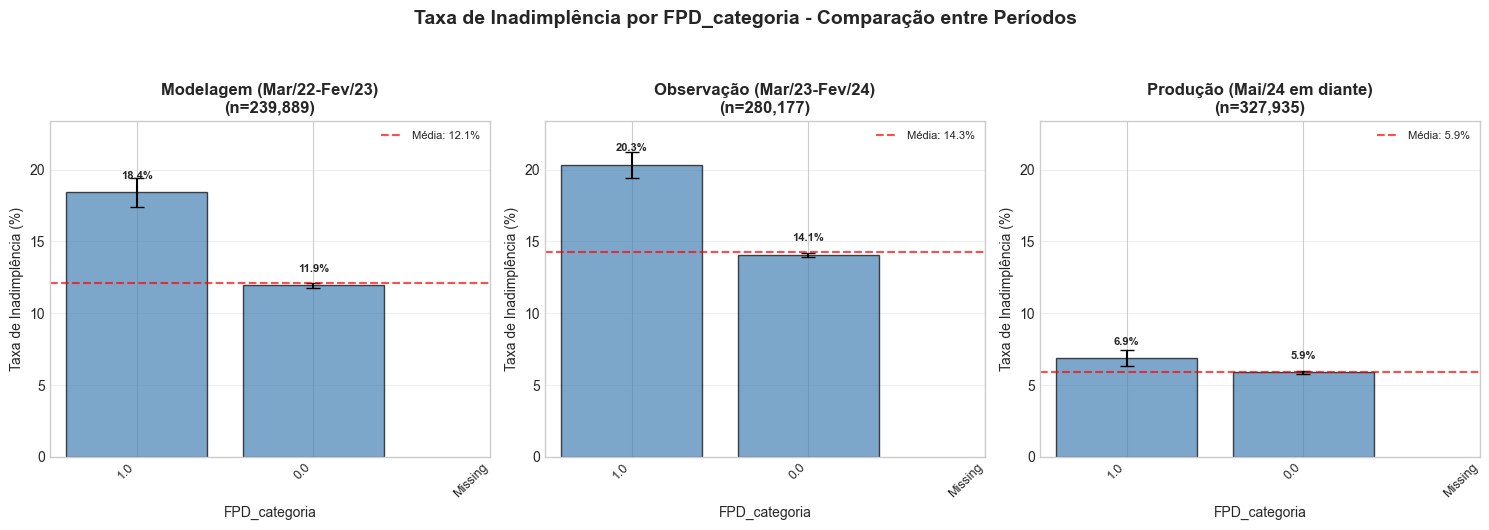


RESUMO POR PERÍODO:

--- Modelagem (Mar/22-Fev/23) ---
Top 5 maiores taxas de inadimplência:
  1.0: 18.42% (1004/5452)
  0.0: 11.94% (21092/176608)

--- Observação (Mar/23-Fev/24) ---
Top 5 maiores taxas de inadimplência:
  1.0: 20.35% (1523/7485)
  0.0: 14.07% (28754/204295)

--- Produção (Mai/24 em diante) ---
Top 5 maiores taxas de inadimplência:
  1.0: 6.88% (605/8791)
  0.0: 5.88% (14877/252820)

5. ANÁLISE DE VARIÁVEIS NUMÉRICAS

--- Análise: idade ---


C:\Users\kel_m\AppData\Local\Temp\ipykernel_29148\2610162613.py:196: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\kel_m\AppData\Local\Temp\ipykernel_29148\2610162613.py:214: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\kel_m\AppData\Local\Temp\ipykernel_29148\2610162613.py:214: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\kel_m\AppData\Local\Temp\ipykernel_29148\2610162613.py:214: FutureWarn

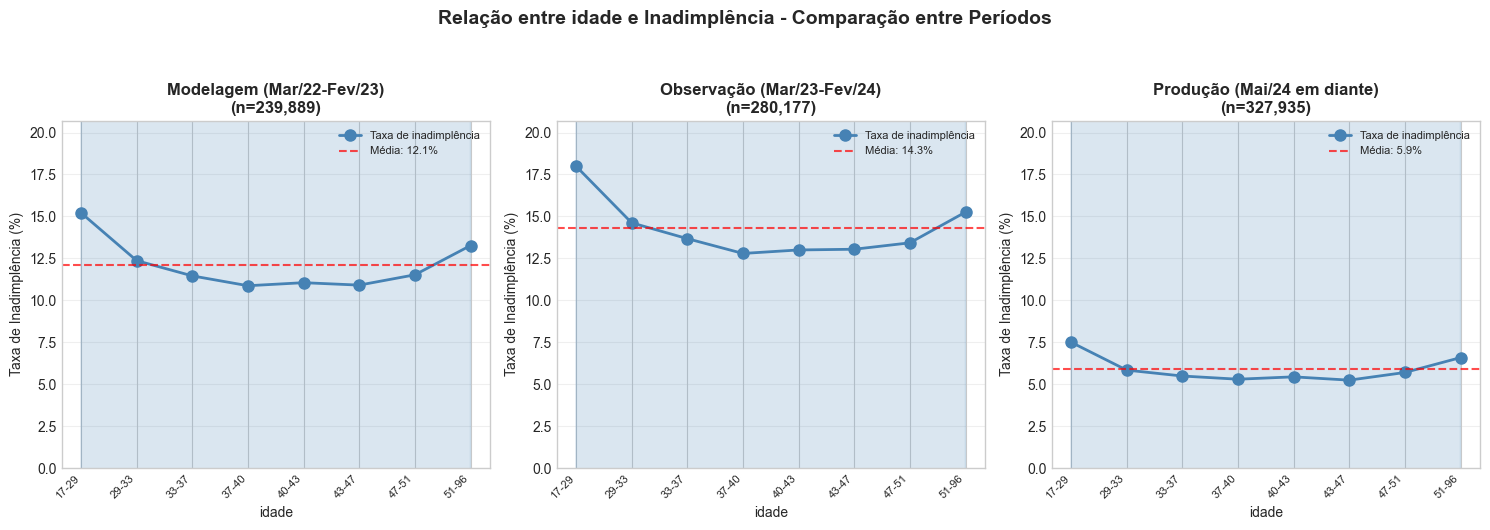


Estatísticas descritivas por período:

Modelagem (Mar/22-Fev/23):
  Correlação com target: -0.0176
  Média (não inadimplentes): 40.34
  Média (inadimplentes): 39.81
  Teste t (diferença de médias): p-value = 0.0000

Observação (Mar/23-Fev/24):
  Correlação com target: -0.0231
  Média (não inadimplentes): 40.38
  Média (inadimplentes): 39.73
  Teste t (diferença de médias): p-value = 0.0000

Produção (Mai/24 em diante):
  Correlação com target: -0.0102
  Média (não inadimplentes): 40.39
  Média (inadimplentes): 39.96
  Teste t (diferença de médias): p-value = 0.0000

--- Análise: renda ---


C:\Users\kel_m\AppData\Local\Temp\ipykernel_29148\2610162613.py:196: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\kel_m\AppData\Local\Temp\ipykernel_29148\2610162613.py:214: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\kel_m\AppData\Local\Temp\ipykernel_29148\2610162613.py:214: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\kel_m\AppData\Local\Temp\ipykernel_29148\2610162613.py:214: FutureWarn

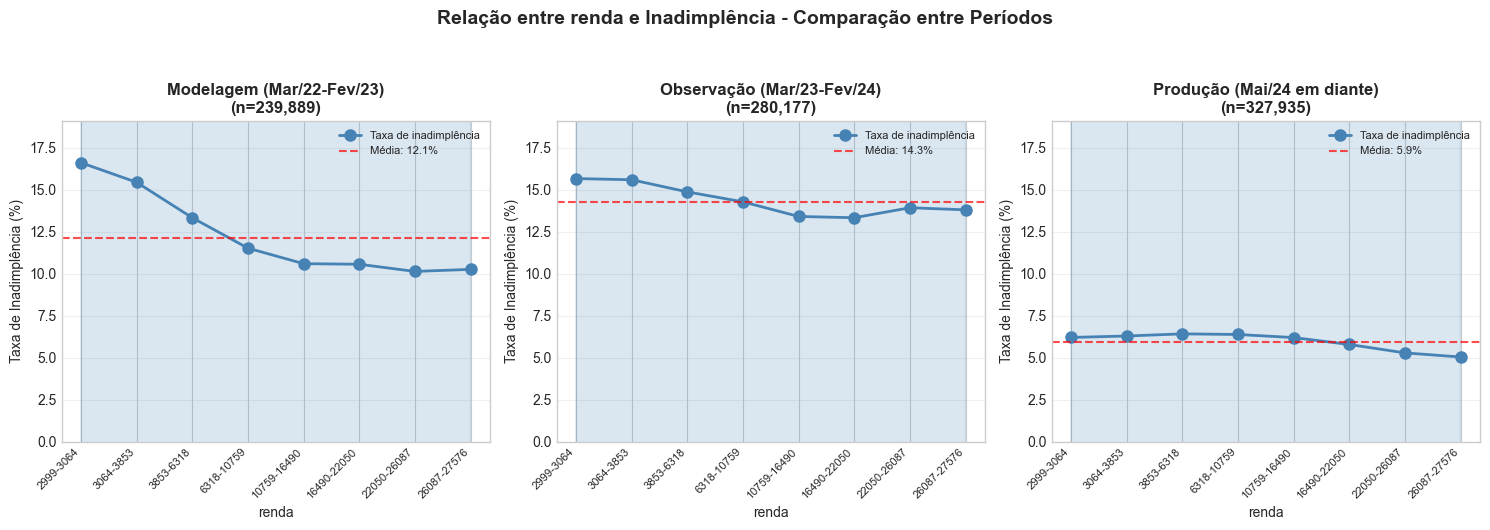


Estatísticas descritivas por período:

Modelagem (Mar/22-Fev/23):
  Correlação com target: -0.0591
  Média (não inadimplentes): 13754.83
  Média (inadimplentes): 12123.11
  Teste t (diferença de médias): p-value = 0.0000

Observação (Mar/23-Fev/24):
  Correlação com target: -0.0184
  Média (não inadimplentes): 13653.56
  Média (inadimplentes): 13178.37
  Teste t (diferença de médias): p-value = 0.0000

Produção (Mai/24 em diante):
  Correlação com target: -0.0200
  Média (não inadimplentes): 13960.22
  Média (inadimplentes): 13195.96
  Teste t (diferença de médias): p-value = 0.0000

--- Análise: entrada ---


C:\Users\kel_m\AppData\Local\Temp\ipykernel_29148\2610162613.py:196: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\kel_m\AppData\Local\Temp\ipykernel_29148\2610162613.py:214: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\kel_m\AppData\Local\Temp\ipykernel_29148\2610162613.py:214: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\kel_m\AppData\Local\Temp\ipykernel_29148\2610162613.py:214: FutureWarn

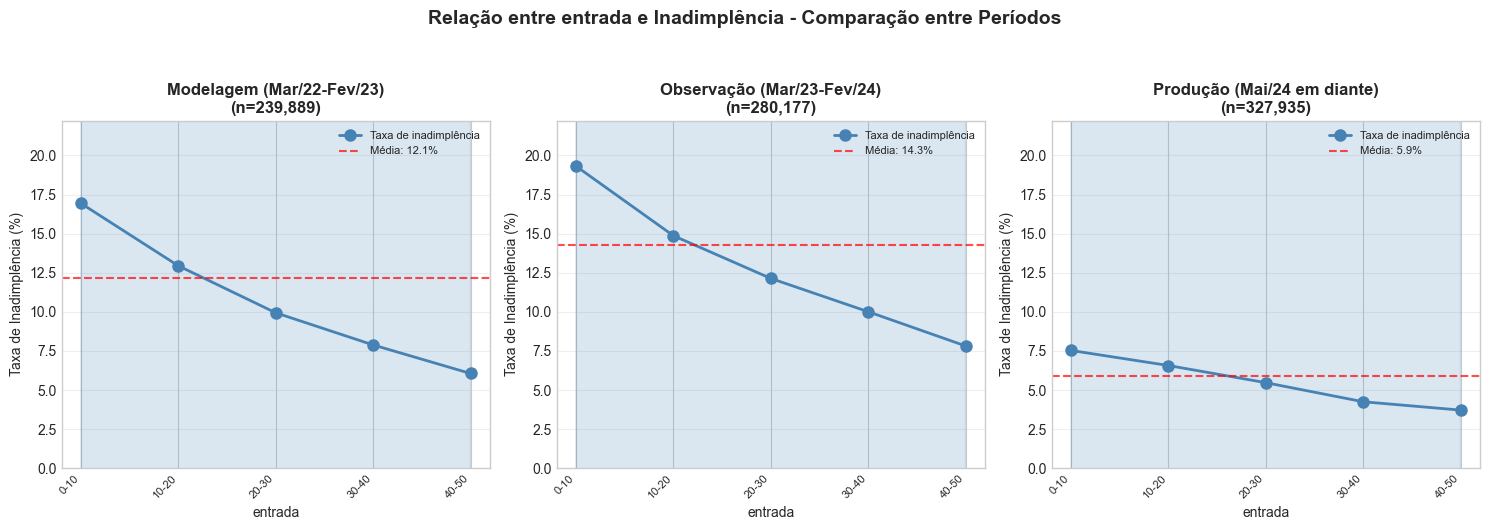


Estatísticas descritivas por período:

Modelagem (Mar/22-Fev/23):
  Correlação com target: -0.1272
  Média (não inadimplentes): 24.74
  Média (inadimplentes): 18.61
  Teste t (diferença de médias): p-value = 0.0000

Observação (Mar/23-Fev/24):
  Correlação com target: -0.1233
  Média (não inadimplentes): 24.74
  Média (inadimplentes): 19.20
  Teste t (diferença de médias): p-value = 0.0000

Produção (Mai/24 em diante):
  Correlação com target: -0.0614
  Média (não inadimplentes): 25.01
  Média (inadimplentes): 20.98
  Teste t (diferença de médias): p-value = 0.0000

--- Análise: prazo ---


C:\Users\kel_m\AppData\Local\Temp\ipykernel_29148\2610162613.py:196: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\kel_m\AppData\Local\Temp\ipykernel_29148\2610162613.py:214: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\kel_m\AppData\Local\Temp\ipykernel_29148\2610162613.py:214: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\kel_m\AppData\Local\Temp\ipykernel_29148\2610162613.py:214: FutureWarn

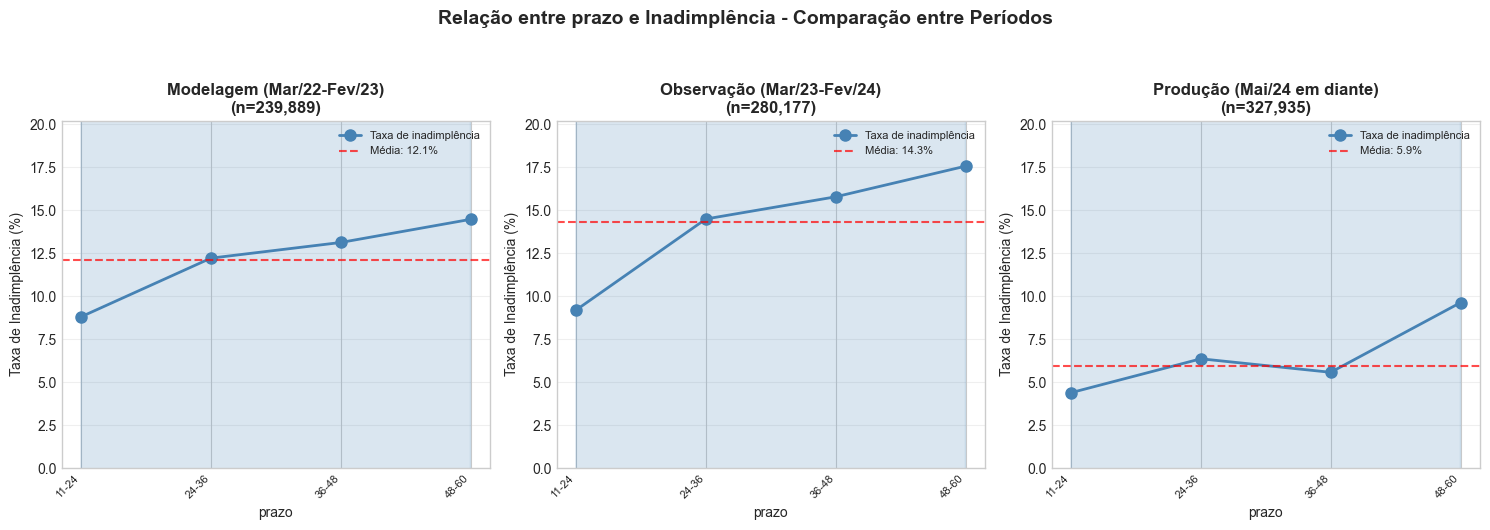


Estatísticas descritivas por período:

Modelagem (Mar/22-Fev/23):
  Correlação com target: 0.0486
  Média (não inadimplentes): 38.92
  Média (inadimplentes): 40.64
  Teste t (diferença de médias): p-value = 0.0000

Observação (Mar/23-Fev/24):
  Correlação com target: 0.0690
  Média (não inadimplentes): 38.83
  Média (inadimplentes): 41.12
  Teste t (diferença de médias): p-value = 0.0000

Produção (Mai/24 em diante):
  Correlação com target: 0.0235
  Média (não inadimplentes): 39.60
  Média (inadimplentes): 40.60
  Teste t (diferença de médias): p-value = 0.0000

--- Análise: pmt ---


C:\Users\kel_m\AppData\Local\Temp\ipykernel_29148\2610162613.py:196: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\kel_m\AppData\Local\Temp\ipykernel_29148\2610162613.py:214: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\kel_m\AppData\Local\Temp\ipykernel_29148\2610162613.py:214: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\kel_m\AppData\Local\Temp\ipykernel_29148\2610162613.py:214: FutureWarn

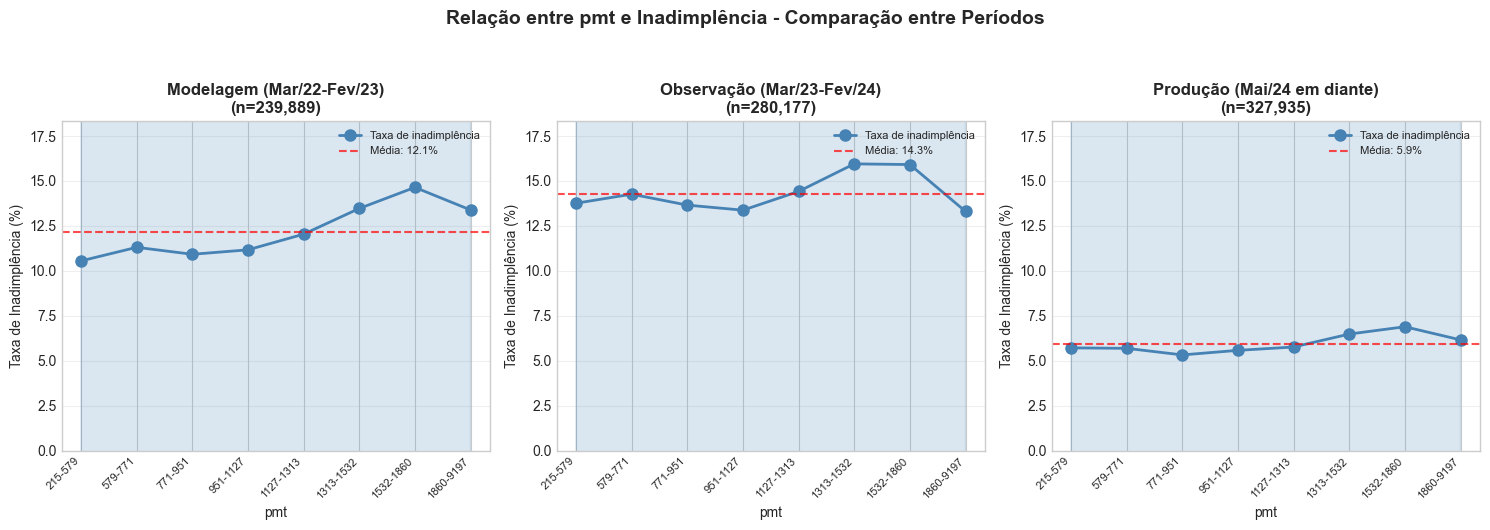


Estatísticas descritivas por período:

Modelagem (Mar/22-Fev/23):
  Correlação com target: 0.0247
  Média (não inadimplentes): 1215.10
  Média (inadimplentes): 1266.81
  Teste t (diferença de médias): p-value = 0.0000

Observação (Mar/23-Fev/24):
  Correlação com target: -0.0074
  Média (não inadimplentes): 1224.79
  Média (inadimplentes): 1210.32
  Teste t (diferença de médias): p-value = 0.0007

Produção (Mai/24 em diante):
  Correlação com target: 0.0082
  Média (não inadimplentes): 1160.94
  Média (inadimplentes): 1181.87
  Teste t (diferença de médias): p-value = 0.0000

--- Análise: comp_renda ---


C:\Users\kel_m\AppData\Local\Temp\ipykernel_29148\2610162613.py:196: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\kel_m\AppData\Local\Temp\ipykernel_29148\2610162613.py:214: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\kel_m\AppData\Local\Temp\ipykernel_29148\2610162613.py:214: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\kel_m\AppData\Local\Temp\ipykernel_29148\2610162613.py:214: FutureWarn

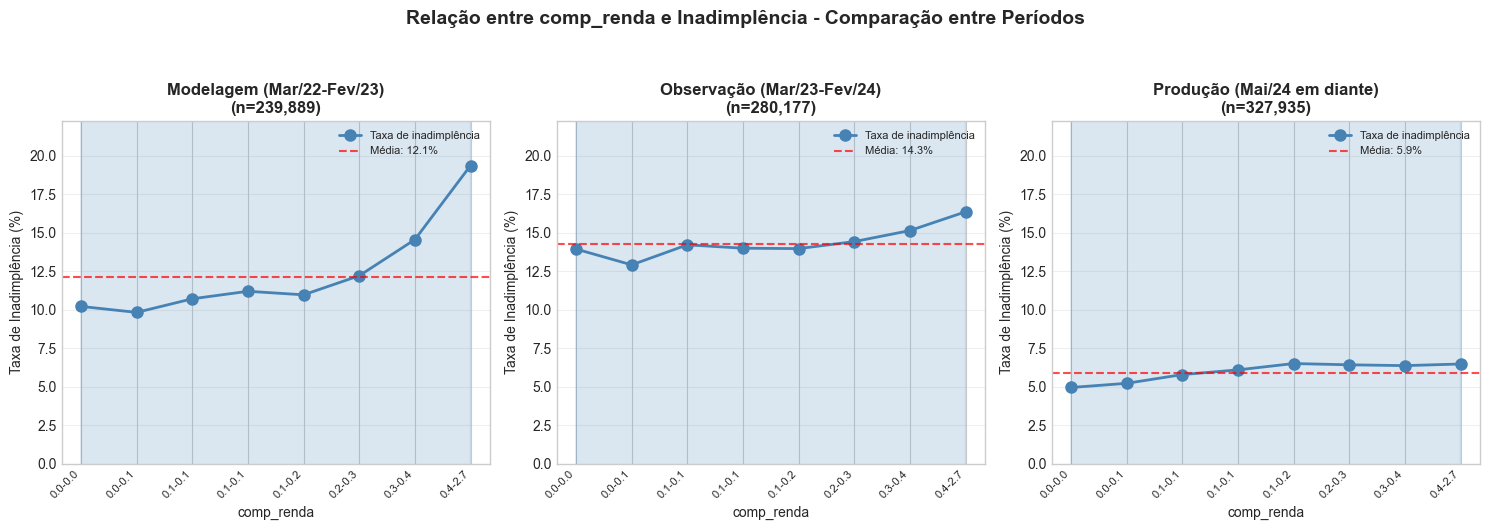


Estatísticas descritivas por período:

Modelagem (Mar/22-Fev/23):
  Correlação com target: 0.0884
  Média (não inadimplentes): 0.16
  Média (inadimplentes): 0.20
  Teste t (diferença de médias): p-value = 0.0000

Observação (Mar/23-Fev/24):
  Correlação com target: 0.0201
  Média (não inadimplentes): 0.16
  Média (inadimplentes): 0.17
  Teste t (diferença de médias): p-value = 0.0000

Produção (Mai/24 em diante):
  Correlação com target: 0.0139
  Média (não inadimplentes): 0.15
  Média (inadimplentes): 0.16
  Teste t (diferença de médias): p-value = 0.0000

--- Análise: score ---


C:\Users\kel_m\AppData\Local\Temp\ipykernel_29148\2610162613.py:196: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\kel_m\AppData\Local\Temp\ipykernel_29148\2610162613.py:214: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\kel_m\AppData\Local\Temp\ipykernel_29148\2610162613.py:214: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\kel_m\AppData\Local\Temp\ipykernel_29148\2610162613.py:214: FutureWarn

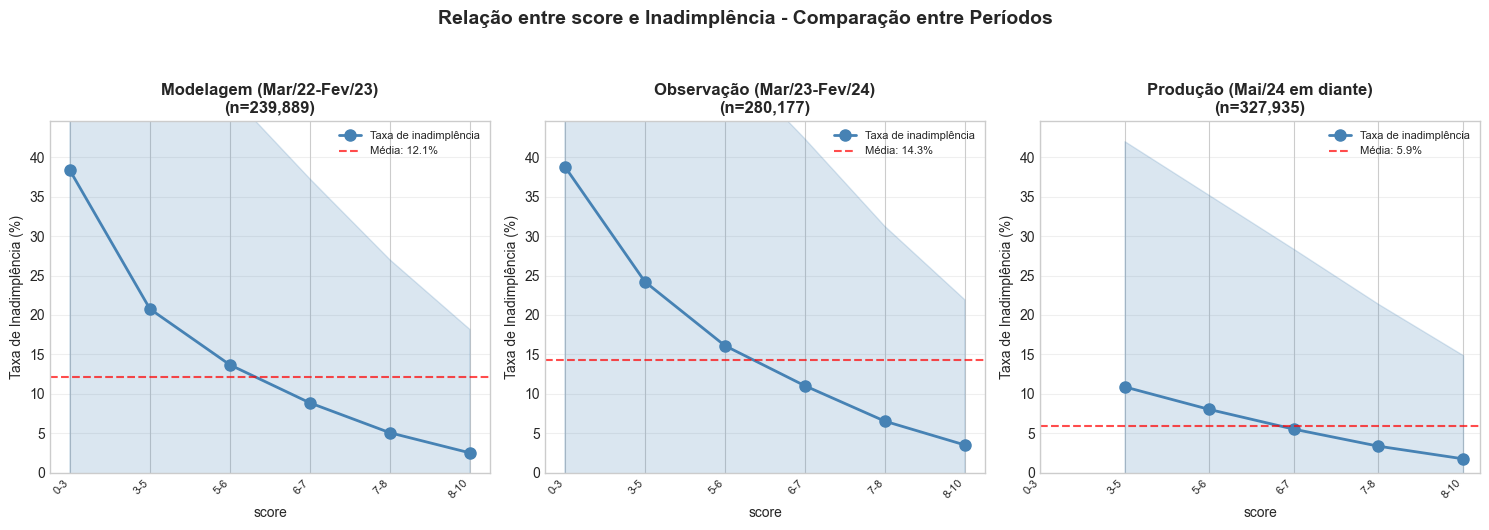


Estatísticas descritivas por período:

Modelagem (Mar/22-Fev/23):
  Correlação com target: -0.2803
  Média (não inadimplentes): 6.80
  Média (inadimplentes): 5.23
  Teste t (diferença de médias): p-value = 0.0000

Observação (Mar/23-Fev/24):
  Correlação com target: -0.2722
  Média (não inadimplentes): 6.79
  Média (inadimplentes): 5.36
  Teste t (diferença de médias): p-value = 0.0000

Produção (Mai/24 em diante):
  Correlação com target: -0.1241
  Média (não inadimplentes): 7.03
  Média (inadimplentes): 6.33
  Teste t (diferença de médias): p-value = 0.0000

6. MATRIZ DE CORRELAÇÃO POR PERÍODO


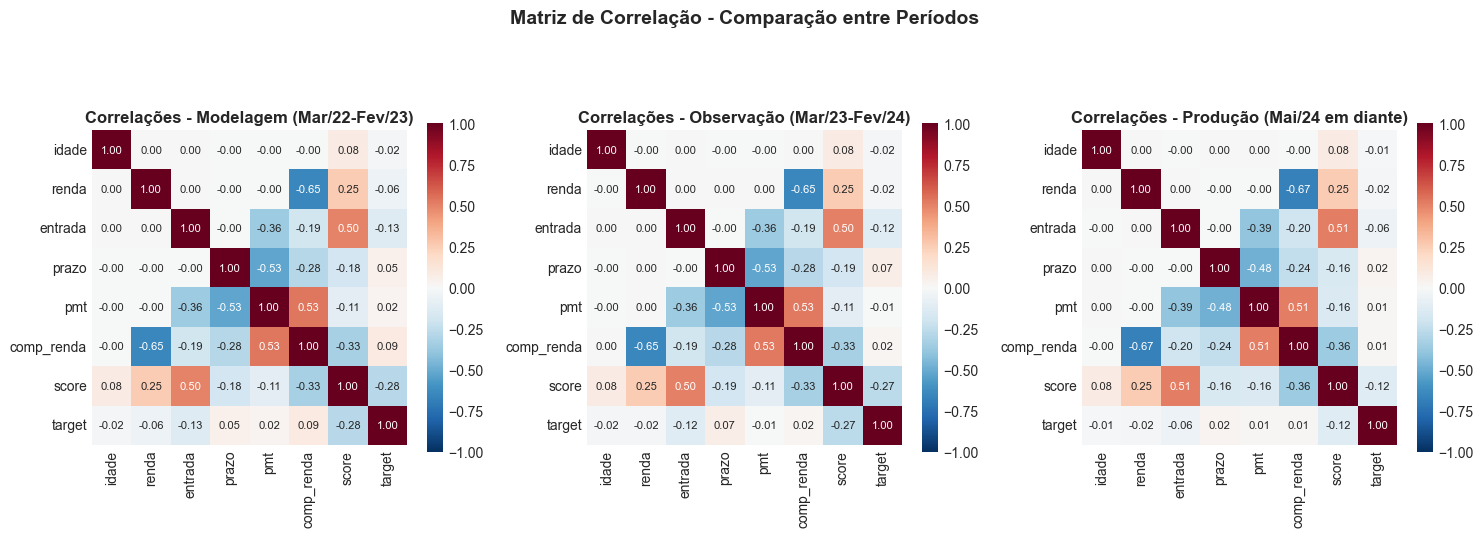


7. PRINCIPAIS INSIGHTS - COMPARAÇÃO ENTRE PERÍODOS

EVOLUÇÃO DA TAXA DE INADIMPLÊNCIA POR PERÍODO:
  Modelagem (Mar/22-Fev/23): 12.14%
  Observação (Mar/23-Fev/24): 14.30%
  Produção (Mai/24 em diante): 5.92%

VARIÁVEIS MAIS ESTÁVEIS (menor variação entre períodos):
  estado_civil: desvio padrão = 3.46%
  idade_veiculo: desvio padrão = 3.59%
  Regiao: desvio padrão = 3.66%

ANÁLISE CONCLUÍDA - 3 PERÍODOS LADO A LADO COM ESCALA PADRONIZADA


In [117]:
# Configurações de visualização
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

# 1. PREPARAÇÃO DOS DADOS
print("="*80)
print("ANÁLISE BIVARIADA POR PERÍODO - ESCALA PADRONIZADA")
print("="*80)

# Criar uma coluna de período consolidada
def classificar_periodo(row):
    if row['per_model'] == 1:
        return 'Modelagem (Mar/22-Fev/23)'
    elif row['per_observed'] == 1 or row['per_observed2'] == 1:
        return 'Observação (Mar/23-Fev/24)'
    elif row['per_production'] == 1:
        return 'Produção (Mai/24 em diante)'
    else:
        return 'Limbo'

df['periodo'] = df.apply(classificar_periodo, axis=1)

# Verificar distribuição por período
print("\n1. DISTRIBUIÇÃO POR PERÍODO:")
periodos_validos = [p for p in df['periodo'].unique() if p != 'Limbo']
print(df['periodo'].value_counts())
print("\nPercentuais:")
print(df['periodo'].value_counts(normalize=True).round(4) * 100)

# 2. ANÁLISE DA VARIÁVEL TARGET POR PERÍODO
print("\n" + "="*80)
print("2. ANÁLISE DA VARIÁVEL TARGET POR PERÍODO")
print("="*80)

# Estatísticas do target por período
target_stats = df.groupby('periodo')['target'].agg(['count', 'mean', 'std', 'min', 'max', 'median'])
print("\nEstatísticas do target por período:")
print(target_stats.round(4))

# Teste de diferença entre períodos (ANOVA)
target_por_periodo = [df[df['periodo'] == p]['target'].dropna() for p in periodos_validos]
f_stat, p_value = stats.f_oneway(*target_por_periodo)
print(f"\nTeste ANOVA - diferença entre períodos:")
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Há diferença significativa: {'Sim' if p_value < 0.05 else 'Não'}")

# 3. FUNÇÃO PARA ANÁLISE BIVARIADA POR PERÍODO COM ESCALA PADRONIZADA
def analise_bivariada_por_periodo(df, var_categorica, var_target='target'):
    """
    Realiza análise bivariada de uma variável categórica com o target, segmentada por período
    com ESCALA PADRONIZADA no eixo Y - 3 períodos lado a lado
    """
    print("\n" + "="*80)
    print(f"ANÁLISE: {var_categorica} vs {var_target} POR PERÍODO")
    print("="*80)
    
    # Períodos a analisar (excluindo Limbo)
    periodos_plot = periodos_validos
    
    # Calcular o valor máximo global da taxa de inadimplência para padronizar o eixo Y
    max_global = 0
    taxas_por_periodo = {}
    
    for periodo in periodos_plot:
        df_periodo = df[df['periodo'] == periodo].copy()
        if len(df_periodo) > 0:
            taxa_inad = df_periodo.groupby(var_categorica)[var_target].mean()
            if not taxa_inad.empty:
                max_periodo = taxa_inad.max() * 100
                max_global = max(max_global, max_periodo)
                taxas_por_periodo[periodo] = taxa_inad
    
    # Adicionar margem de 15% no topo
    y_max = max_global * 1.15
    if y_max == 0:
        y_max = 10  # valor default caso não haja dados
    
    # Criar figura com 1 linha e 3 colunas
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for idx, periodo in enumerate(periodos_plot):
        ax = axes[idx]
        
        # Filtrar dados do período
        df_periodo = df[df['periodo'] == periodo].copy()
        
        if len(df_periodo) > 0:
            # Calcular taxa de inadimplência por categoria
            taxa_inad = df_periodo.groupby(var_categorica)[var_target].agg(['mean', 'count', 'std'])
            taxa_inad = taxa_inad.sort_values('mean', ascending=False)
            taxa_inad['erro_padrao'] = taxa_inad['std'] / np.sqrt(taxa_inad['count'])
            
            # Gráfico de barras com intervalo de confiança
            x_pos = np.arange(len(taxa_inad))
            bars = ax.bar(x_pos, taxa_inad['mean'] * 100, 
                         yerr=taxa_inad['erro_padrao'] * 1.96 * 100,
                         capsize=5, alpha=0.7, color='steelblue', edgecolor='black')
            
            # Configurar eixo Y com a mesma escala para todos
            ax.set_ylim(0, y_max)
            
            # Adicionar linha de referência da média global do período
            media_periodo = df_periodo[var_target].mean() * 100
            ax.axhline(y=media_periodo, color='red', linestyle='--', linewidth=1.5, 
                      alpha=0.7, label=f'Média: {media_periodo:.1f}%')
            
            # Configurar labels e título
            ax.set_xlabel(var_categorica, fontsize=10)
            ax.set_ylabel('Taxa de Inadimplência (%)', fontsize=10)
            ax.set_title(f'{periodo}\n(n={len(df_periodo):,})', fontweight='bold')
            ax.set_xticks(x_pos)
            ax.set_xticklabels(taxa_inad.index, rotation=45, ha='right', fontsize=9)
            ax.grid(True, alpha=0.3, axis='y')
            ax.legend(loc='upper right', fontsize=8)
            
            # Adicionar valores nas barras (apenas para as 5 maiores se houver muitas categorias)
            for i, (idx_row, row) in enumerate(taxa_inad.head(10).iterrows()):
                valor = row['mean'] * 100
                if valor > y_max * 0.1:  # Só mostrar se for relevante
                    ax.text(i, valor + 0.8, f"{valor:.1f}%", 
                           ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    plt.suptitle(f'Taxa de Inadimplência por {var_categorica} - Comparação entre Períodos', 
                fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()
    
    # Tabela resumo
    print("\nRESUMO POR PERÍODO:")
    for periodo in periodos_plot:
        df_periodo = df[df['periodo'] == periodo]
        if len(df_periodo) > 0:
            tab = pd.crosstab(df_periodo[var_categorica], 
                             df_periodo[var_target],
                             margins=True, 
                             margins_name='Total')
            tab_pct = pd.crosstab(df_periodo[var_categorica], 
                                 df_periodo[var_target],
                                 normalize='index') * 100
            
            print(f"\n--- {periodo} ---")
            print("Top 5 maiores taxas de inadimplência:")
            if 1 in tab_pct.columns:
                top5 = tab_pct[1].sort_values(ascending=False).head(5)
                for cat, taxa in top5.items():
                    count_inad = tab.loc[cat, 1] if 1 in tab.columns else 0
                    count_total = tab.loc[cat, 'Total'] if 'Total' in tab.columns else 0
                    print(f"  {cat}: {taxa:.2f}% ({count_inad}/{count_total})")

# 4. ANÁLISE DAS PRINCIPAIS VARIÁVEIS CATEGÓRICAS
print("\n" + "="*80)
print("4. ANÁLISE DAS VARIÁVEIS CATEGÓRICAS")
print("="*80)

variaveis_categoricas = ['estado_civil', 'Regiao', 'Profissao', 'marca', 
                         'idade_veiculo', 'nacionalidade', 'FPD_categoria']

for var in variaveis_categoricas:
    if var in df.columns:
        analise_bivariada_por_periodo(df, var)

# 5. ANÁLISE DE VARIÁVEIS NUMÉRICAS COM ESCALA PADRONIZADA
print("\n" + "="*80)
print("5. ANÁLISE DE VARIÁVEIS NUMÉRICAS")
print("="*80)

variaveis_numericas = ['idade', 'renda', 'entrada', 'prazo', 'pmt', 
                       'comp_renda', 'score']

# Função para análise numérica com escala padronizada
def analise_numerica_bivariada(df, var_numerica, var_target='target', n_bins=8):
    """
    Analisa variável numérica vs target por período com ESCALA PADRONIZADA
    """
    print(f"\n--- Análise: {var_numerica} ---")
    
    # Preparar dados
    df_clean = df[df[var_numerica].notna()].copy()
    
    # Criar bins de forma mais robusta
    try:
        df_clean['bin'] = pd.qcut(df_clean[var_numerica], q=n_bins, duplicates='drop')
    except:
        # Se falhar, usa intervalos iguais
        df_clean['bin'] = pd.cut(df_clean[var_numerica], bins=n_bins)
    
    periodos_plot = periodos_validos
    
    # Calcular o valor máximo global da taxa de inadimplência
    max_global = 0
    for periodo in periodos_plot:
        df_periodo = df_clean[df_clean['periodo'] == periodo]
        if len(df_periodo) > 0:
            taxa_bin = df_periodo.groupby('bin')[var_target].mean()
            if not taxa_bin.empty:
                max_global = max(max_global, taxa_bin.max() * 100)
    
    y_max = max_global * 1.15
    if y_max == 0:
        y_max = 10
    
    # Criar subplots - 1 linha, 3 colunas
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for idx, periodo in enumerate(periodos_plot):
        ax = axes[idx]
        
        df_periodo = df_clean[df_clean['periodo'] == periodo]
        
        if len(df_periodo) > 0:
            # Calcular taxa de inadimplência por bin
            taxa_bin = df_periodo.groupby('bin')[var_target].agg(['mean', 'count', 'std'])
            taxa_bin = taxa_bin.sort_index()
            
            # Gráfico de linha
            x_pos = range(len(taxa_bin))
            line = ax.plot(x_pos, taxa_bin['mean'] * 100, marker='o', linewidth=2, 
                          markersize=8, color='steelblue', label='Taxa de inadimplência')
            
            # Adicionar banda de confiança (1 desvio padrão)
            ax.fill_between(x_pos, 
                           (taxa_bin['mean'] - taxa_bin['std']) * 100,
                           (taxa_bin['mean'] + taxa_bin['std']) * 100,
                           alpha=0.2, color='steelblue')
            
            # Configurar eixo Y com escala padronizada
            ax.set_ylim(0, y_max)
            
            # Adicionar linha da média global do período
            media_periodo = df_periodo[var_target].mean() * 100
            ax.axhline(y=media_periodo, color='red', linestyle='--', linewidth=1.5, 
                      alpha=0.7, label=f'Média: {media_periodo:.1f}%')
            
            ax.set_xlabel(f'{var_numerica}', fontsize=10)
            ax.set_ylabel('Taxa de Inadimplência (%)', fontsize=10)
            ax.set_title(f'{periodo}\n(n={len(df_periodo):,})', fontweight='bold')
            ax.grid(True, alpha=0.3, axis='y')
            ax.legend(loc='upper right', fontsize=8)
            
            # Configurar labels dos bins
            bin_labels = []
            for b in taxa_bin.index:
                if hasattr(b, 'left') and hasattr(b, 'right'):
                    if df_clean[var_numerica].dtype in ['int64']:
                        bin_labels.append(f"{int(b.left)}-{int(b.right)}")
                    else:
                        bin_labels.append(f"{b.left:.1f}-{b.right:.1f}")
                else:
                    bin_labels.append(str(b))
            
            ax.set_xticks(x_pos)
            ax.set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=8)
    
    plt.suptitle(f'Relação entre {var_numerica} e Inadimplência - Comparação entre Períodos', 
                fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()
    
    # Estatísticas por período
    print("\nEstatísticas descritivas por período:")
    for periodo in periodos_plot:
        df_periodo = df[df['periodo'] == periodo]
        if len(df_periodo) > 0:
            print(f"\n{periodo}:")
            correl = df_periodo[[var_numerica, var_target]].corr().iloc[0,1]
            print(f"  Correlação com target: {correl:.4f}")
            
            # Estatísticas para inadimplentes vs não inadimplentes
            stats_comp = df_periodo.groupby(var_target)[var_numerica].agg(['mean', 'median', 'std'])
            if 0 in stats_comp.index:
                print(f"  Média (não inadimplentes): {stats_comp.loc[0, 'mean']:.2f}")
            if 1 in stats_comp.index:
                print(f"  Média (inadimplentes): {stats_comp.loc[1, 'mean']:.2f}")
                
            # Teste t para diferença de médias
            inad = df_periodo[df_periodo[var_target] == 1][var_numerica]
            nao_inad = df_periodo[df_periodo[var_target] == 0][var_numerica]
            if len(inad) > 0 and len(nao_inad) > 0:
                t_stat, p_val = stats.ttest_ind(inad, nao_inad)
                print(f"  Teste t (diferença de médias): p-value = {p_val:.4f}")

# Analisar variáveis numéricas
for var in variaveis_numericas:
    if var in df.columns and df[var].dtype in ['int64', 'float64']:
        analise_numerica_bivariada(df, var)

# 6. MATRIZ DE CORRELAÇÃO POR PERÍODO
print("\n" + "="*80)
print("6. MATRIZ DE CORRELAÇÃO POR PERÍODO")
print("="*80)

var_correlacao = ['idade', 'renda', 'entrada', 'prazo', 'pmt', 
                  'comp_renda', 'score', 'target']

# Criar subplots - 1 linha, 3 colunas
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, periodo in enumerate(periodos_validos):
    ax = axes[idx]
    
    df_periodo = df[df['periodo'] == periodo][var_correlacao].copy()
    
    # Converter colunas numéricas
    for col in df_periodo.columns:
        if df_periodo[col].dtype == 'object':
            df_periodo[col] = pd.to_numeric(df_periodo[col], errors='coerce')
    
    if len(df_periodo) > 0:
        # Calcular correlação
        corr_matrix = df_periodo.corr()
        
        # Heatmap com escala fixa de -1 a 1
        sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', 
                   center=0, square=True, ax=ax, cbar_kws={"shrink": 0.8},
                   vmin=-1, vmax=1, annot_kws={'size': 8})
        ax.set_title(f'Correlações - {periodo}', fontweight='bold')

plt.suptitle('Matriz de Correlação - Comparação entre Períodos', 
            fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# 7. INSIGHTS FINAIS
print("\n" + "="*80)
print("7. PRINCIPAIS INSIGHTS - COMPARAÇÃO ENTRE PERÍODOS")
print("="*80)

# Calcular estatísticas comparativas
print("\nEVOLUÇÃO DA TAXA DE INADIMPLÊNCIA POR PERÍODO:")
for periodo in periodos_validos:
    taxa = df[df['periodo'] == periodo]['target'].mean() * 100
    print(f"  {periodo}: {taxa:.2f}%")

# Identificar variáveis mais estáveis
print("\nVARIÁVEIS MAIS ESTÁVEIS (menor variação entre períodos):")
estabilidade = {}
for var in variaveis_categoricas[:5]:
    if var in df.columns:
        taxas = []
        for periodo in periodos_validos:
            df_periodo = df[df['periodo'] == periodo]
            if len(df_periodo) > 0:
                taxa_media = df_periodo.groupby(var)['target'].mean().mean() * 100
                taxas.append(taxa_media)
        if len(taxas) > 1:
            estabilidade[var] = np.std(taxas)

for var, std in sorted(estabilidade.items(), key=lambda x: x[1])[:3]:
    print(f"  {var}: desvio padrão = {std:.2f}%")

print("\n" + "="*80)
print("ANÁLISE CONCLUÍDA - 3 PERÍODOS LADO A LADO COM ESCALA PADRONIZADA")
print("="*80)

### Marca com Inadimplencia por mes

ANÁLISE DETALHADA - PERÍODO DE OBSERVAÇÃO
MARCA vs INADIMPLÊNCIA POR MÊS

Período de Observação: 2023-03 a 2024-04
Total de registros: 280,177
Total de marcas: 11

2. TAXA DE INADIMPLÊNCIA GERAL POR MÊS

Taxa de inadimplência por mês:
         total_contratos  total_inad  taxa_inad_pct
mes_ano                                            
2023-03            15215      2293.0          15.07
2023-04            14964      1883.0          12.58
2023-05            15187      1936.0          12.75
2023-06            15095      1944.0          12.88
2023-07            15318      1947.0          12.71
2023-08            15334      2022.0          13.19
2023-09            15184      2179.0          14.35
2023-10            14953      2065.0          13.81
2023-11            15100      2166.0          14.34
2023-12            14925      2114.0          14.16
2024-01            15161      2118.0          13.97
2024-02            15022      2679.0          17.83
2024-03            15212      2715.0 

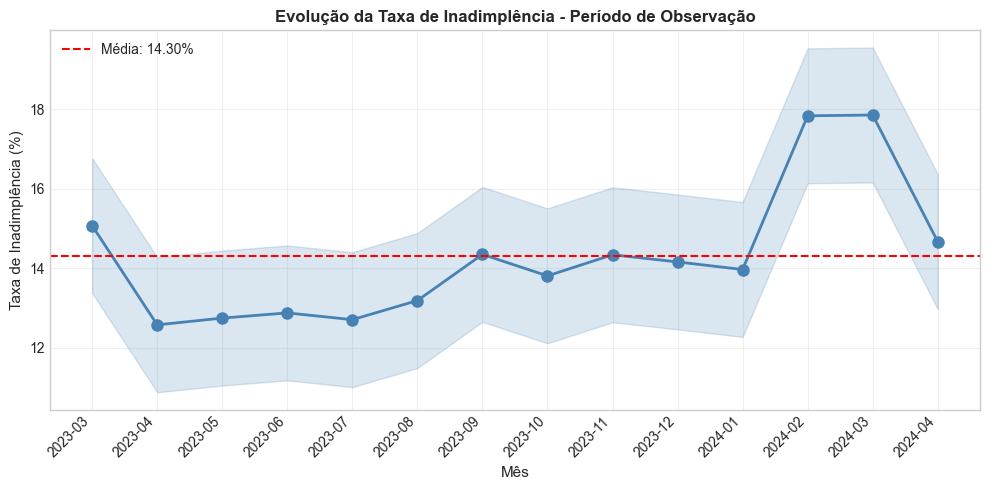


3. TOP MARCAS - TAXA DE INADIMPLÊNCIA AGREGADA

Top 10 marcas com maior inadimplência (mínimo 100 contratos):
           total_contratos  total_inad  taxa_inad_pct
marca                                                
Nissan                1622       323.0          19.91
Fiat                 31763      5249.0          16.53
Jac                   1681       272.0          16.18
Chevrolet            16464      2541.0          15.43
Ford                 24717      3739.0          15.13
Toyota               12702      1886.0          14.85
Outros               36470      5359.0          14.69
Hyundai              11718      1705.0          14.55
VW                   38086      5218.0          13.70
Peugeot              12940      1726.0          13.34

Top 10 marcas com menor inadimplência (mínimo 100 contratos):
           total_contratos  total_inad  taxa_inad_pct
marca                                                
Fiat                 31763      5249.0          16.53
Jac             

C:\Users\kel_m\AppData\Local\Temp\ipykernel_29148\332318215.py:126: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



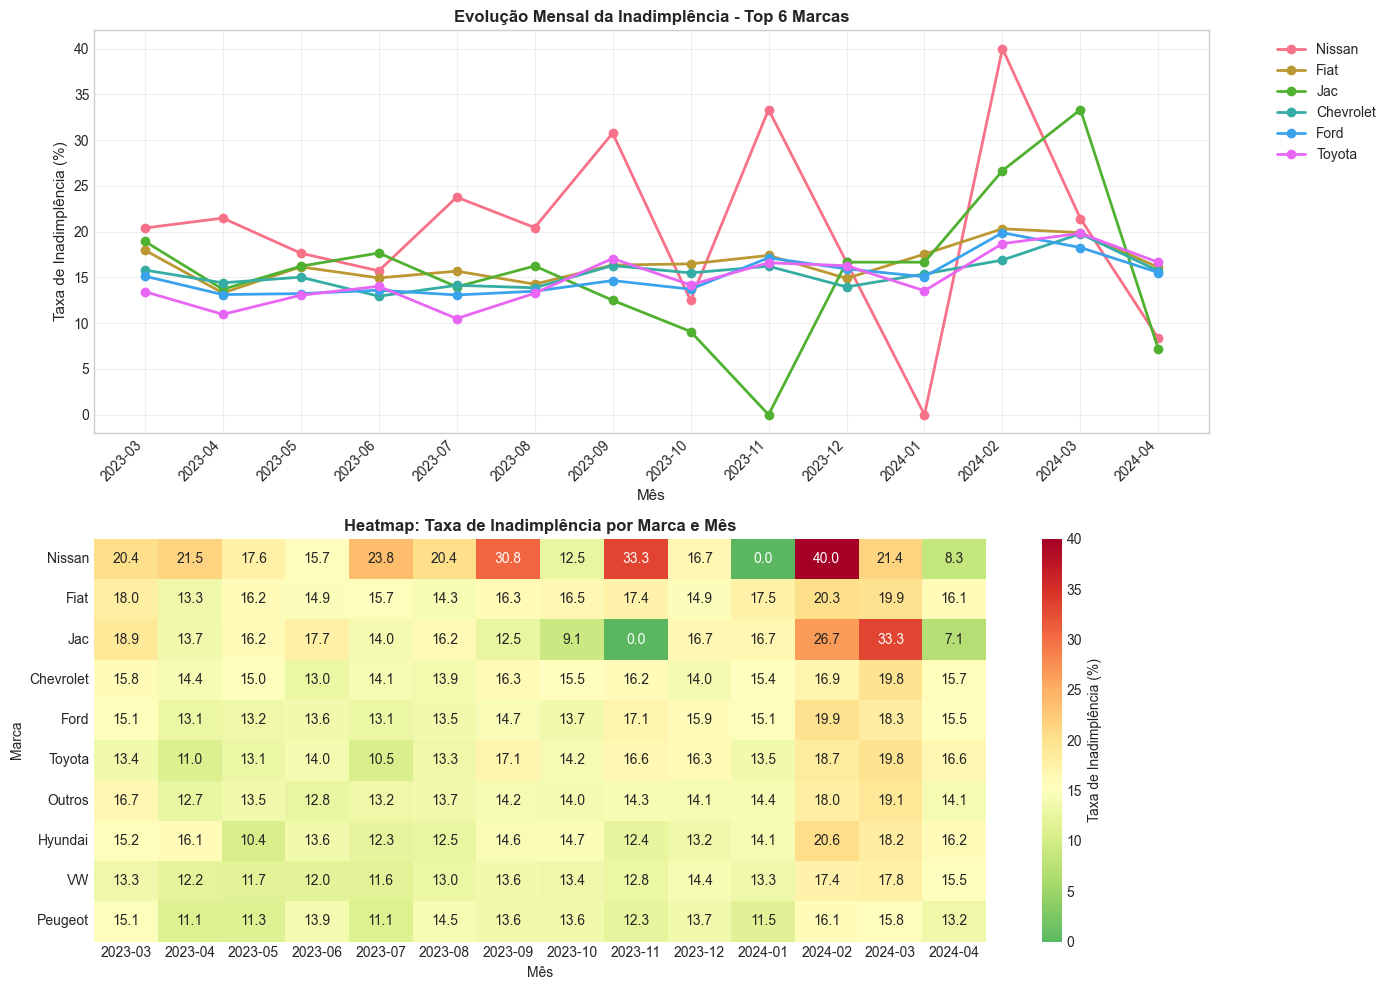


5. ANÁLISE DE SAZONALIDADE

Padrão sazonal (média por mês do ano) - Top marcas:
numero_mes     1      2      3      4      5      6      7      8      9   \
marca                                                                       
Chevrolet   15.38  16.90  17.80  15.07  15.03  12.95  14.14  13.87  16.30   
Fiat        17.55  20.32  18.95  14.69  16.15  14.95  15.68  14.27  16.35   
Ford        15.07  19.88  16.72  14.32  13.23  13.61  13.08  13.49  14.66   
Hyundai     14.13  20.61  16.66  16.13  10.41  13.64  12.27  12.50  14.59   
Jac         16.67  26.67  20.00  13.38  16.23  17.67  13.97  16.25  12.50   
Nissan       0.00  40.00  20.45  20.90  17.65  15.72  23.77  20.45  30.77   
Outros      14.37  17.98  17.99  13.47  13.53  12.80  13.22  13.67  14.20   
Peugeot     11.50  16.06  15.42  12.17  11.26  13.93  11.13  14.53  13.59   
Toyota      13.54  18.69  16.61  13.77  13.05  14.03  10.50  13.27  17.07   
VW          13.35  17.40  15.51  13.83  11.68  11.99  11.58  12.98  13.6

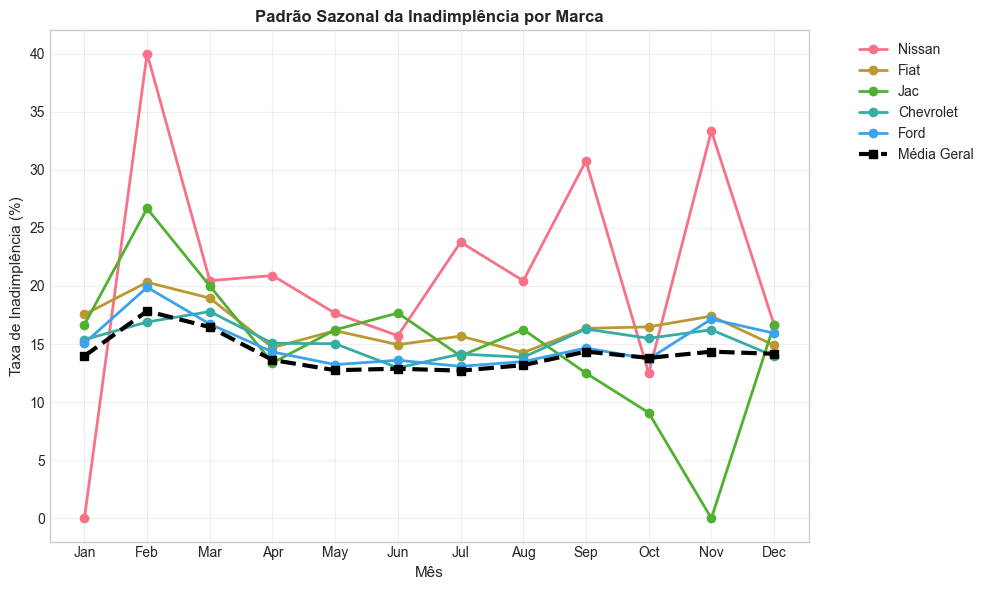


6. VOLUME DE CONTRATOS POR MARCA

Volume de contratos por mês - Top marcas:
mes_ano    2023-03  2023-04  2023-05  2023-06  2023-07  2023-08  2023-09  \
marca                                                                      
Nissan         367      396      402      385      398      398       18   
Fiat          3147     3166     3048     3196     3312     3173     3261   
Jac            400      392      380      372      395      364       25   
Chevrolet     1644     1554     1576     1591     1583     1557     1564   
Ford          2372     2428     2436     2362     2332     2432     2339   
Toyota        1179     1160     1192     1169     1195     1234     1177   
Outros        3028     2998     3058     2992     3057     3137     3819   
Hyundai       1116     1112     1103     1151     1123     1070     1184   
VW            3567     3507     3569     3598     3523     3634     3432   
Peugeot       1228     1180     1205     1196     1229     1157     1177   

mes_ano   

C:\Users\kel_m\AppData\Local\Temp\ipykernel_29148\332318215.py:222: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



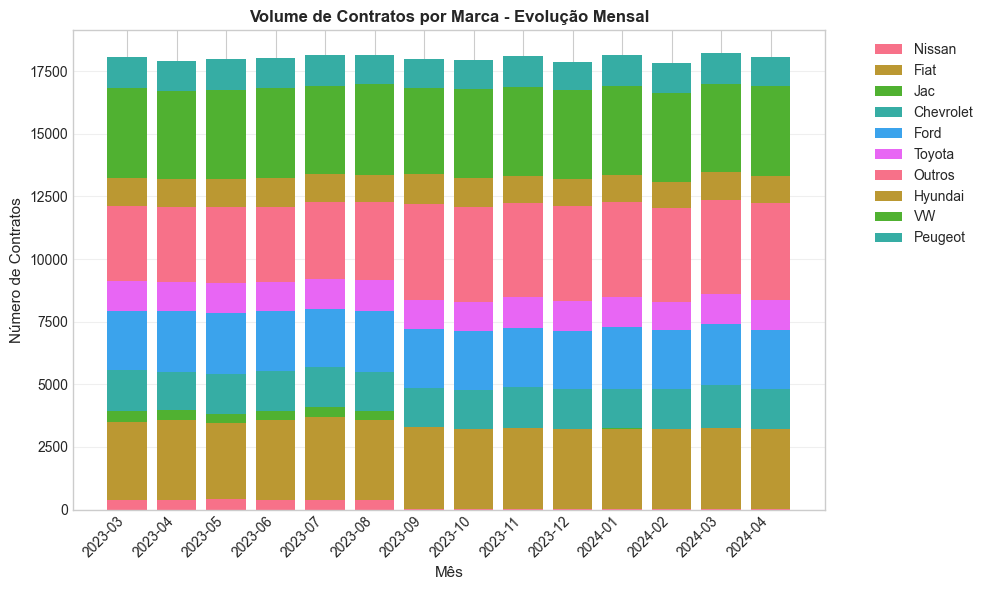


7. PRINCIPAIS INSIGHTS

ESTATÍSTICAS POR MARCA:

Nissan:
  Taxa média: 19.91%
  Desvio padrão: 39.95%
  Volume total: 2,500
  Mês maior taxa: February (40.00%)
  Mês menor taxa: January (0.00%)

Fiat:
  Taxa média: 16.53%
  Desvio padrão: 37.14%
  Volume total: 44,689
  Mês maior taxa: February (20.32%)
  Mês menor taxa: August (14.27%)

Jac:
  Taxa média: 16.18%
  Desvio padrão: 36.84%
  Volume total: 2,483
  Mês maior taxa: February (26.67%)
  Mês menor taxa: November (0.00%)

Chevrolet:
  Taxa média: 15.43%
  Desvio padrão: 36.13%
  Volume total: 22,239
  Mês maior taxa: March (17.80%)
  Mês menor taxa: June (12.95%)

Ford:
  Taxa média: 15.13%
  Desvio padrão: 35.83%
  Volume total: 33,347
  Mês maior taxa: February (19.88%)
  Mês menor taxa: July (13.08%)

ESTABILIDADE TEMPORAL (Correlação entre meses consecutivos):
  Nissan: -0.4371
  Fiat: 0.2569
  Jac: 0.1961

ANÁLISE CONCLUÍDA


In [118]:
import calendar

# Configurações de visualização
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print("="*80)
print("ANÁLISE DETALHADA - PERÍODO DE OBSERVAÇÃO")
print("MARCA vs INADIMPLÊNCIA POR MÊS")
print("="*80)

# 1. FILTRAR APENAS PERÍODO DE OBSERVAÇÃO
df_obs = df[(df['per_observed2'] == 1)].copy()

# Criar coluna de mês/ano para análise temporal
df_obs['ano_mes_dt'] = pd.to_datetime(df_obs['ano_mes'].astype(str), format='%Y%m')
df_obs['mes'] = df_obs['ano_mes_dt'].dt.month
df_obs['ano'] = df_obs['ano_mes_dt'].dt.year
df_obs['mes_ano'] = df_obs['ano_mes_dt'].dt.strftime('%Y-%m')
df_obs['nome_mes'] = df_obs['ano_mes_dt'].dt.month_name()

print(f"\nPeríodo de Observação: {df_obs['mes_ano'].min()} a {df_obs['mes_ano'].max()}")
print(f"Total de registros: {len(df_obs):,}")
print(f"Total de marcas: {df_obs['marca'].nunique()}")

# 2. VISÃO GERAL - TAXA DE INADIMPLÊNCIA POR MÊS
print("\n" + "="*80)
print("2. TAXA DE INADIMPLÊNCIA GERAL POR MÊS")
print("="*80)

# Calcular taxa mensal
taxa_mensal = df_obs.groupby('mes_ano').agg({
    'target': ['mean', 'count', 'sum']
}).round(4)
taxa_mensal.columns = ['taxa_inad', 'total_contratos', 'total_inad']
taxa_mensal['taxa_inad_pct'] = taxa_mensal['taxa_inad'] * 100
taxa_mensal = taxa_mensal.sort_index()

print("\nTaxa de inadimplência por mês:")
print(taxa_mensal[['total_contratos', 'total_inad', 'taxa_inad_pct']].round(2))

# Gráfico de linha da taxa mensal
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(len(taxa_mensal)), taxa_mensal['taxa_inad_pct'], 
        marker='o', linewidth=2, markersize=8, color='steelblue')
ax.fill_between(range(len(taxa_mensal)), 
                taxa_mensal['taxa_inad_pct'] - taxa_mensal['taxa_inad_pct'].std(),
                taxa_mensal['taxa_inad_pct'] + taxa_mensal['taxa_inad_pct'].std(),
                alpha=0.2, color='steelblue')

ax.set_xlabel('Mês', fontsize=11)
ax.set_ylabel('Taxa de Inadimplência (%)', fontsize=11)
ax.set_title('Evolução da Taxa de Inadimplência - Período de Observação', fontweight='bold')
ax.set_xticks(range(len(taxa_mensal)))
ax.set_xticklabels(taxa_mensal.index, rotation=45, ha='right')
ax.grid(True, alpha=0.3)
ax.axhline(y=taxa_mensal['taxa_inad_pct'].mean(), color='red', 
           linestyle='--', label=f"Média: {taxa_mensal['taxa_inad_pct'].mean():.2f}%")
ax.legend()

plt.tight_layout()
plt.show()

# 3. ANÁLISE POR MARCA - VISÃO AGREGADA
print("\n" + "="*80)
print("3. TOP MARCAS - TAXA DE INADIMPLÊNCIA AGREGADA")
print("="*80)

# Calcular taxa por marca no período
taxa_marca = df_obs.groupby('marca').agg({
    'target': ['mean', 'count', 'sum']
}).round(4)
taxa_marca.columns = ['taxa_inad', 'total_contratos', 'total_inad']
taxa_marca['taxa_inad_pct'] = taxa_marca['taxa_inad'] * 100

# Filtrar marcas com volume mínimo (ex: pelo menos 100 contratos)
taxa_marca_filtrada = taxa_marca[taxa_marca['total_contratos'] >= 100].copy()
taxa_marca_filtrada = taxa_marca_filtrada.sort_values('taxa_inad_pct', ascending=False)

print(f"\nTop 10 marcas com maior inadimplência (mínimo 100 contratos):")
print(taxa_marca_filtrada[['total_contratos', 'total_inad', 'taxa_inad_pct']].head(10).round(2))

print(f"\nTop 10 marcas com menor inadimplência (mínimo 100 contratos):")
print(taxa_marca_filtrada[['total_contratos', 'total_inad', 'taxa_inad_pct']].tail(10).round(2))

# 4. ANÁLISE TEMPORAL POR MARCA
print("\n" + "="*80)
print("4. EVOLUÇÃO MENSAL POR MARCA")
print("="*80)

# Selecionar top N marcas para análise detalhada
top_marcas = taxa_marca_filtrada.head(10).index.tolist()
print(f"\nAnalisando evolução mensal das top 10 marcas: {', '.join(top_marcas)}")

# Criar tabela dinâmica: marcas vs meses
tabela_temporal = pd.pivot_table(
    df_obs[df_obs['marca'].isin(top_marcas)],
    values='target',
    index='marca',
    columns='mes_ano',
    aggfunc='mean'
) * 100

# Ordenar pela média geral
media_marcas = tabela_temporal.mean(axis=1).sort_values(ascending=False)
tabela_temporal = tabela_temporal.loc[media_marcas.index]

print("\nTaxa de inadimplência (%) por mês - Top marcas:")
print(tabela_temporal.round(2))

# 5. GRÁFICO DE LINHAS - EVOLUÇÃO TEMPORAL POR MARCA
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Gráfico 1: Linhas para cada marca
ax1 = axes[0]
for marca in top_marcas[:6]:  # Mostrar apenas 6 para não poluir
    dados_marca = df_obs[df_obs['marca'] == marca].groupby('mes_ano')['target'].mean() * 100
    ax1.plot(dados_marca.index, dados_marca.values, marker='o', linewidth=2, label=marca)

ax1.set_xlabel('Mês', fontsize=11)
ax1.set_ylabel('Taxa de Inadimplência (%)', fontsize=11)
ax1.set_title('Evolução Mensal da Inadimplência - Top 6 Marcas', fontweight='bold')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_xticklabels(dados_marca.index, rotation=45, ha='right')

# Gráfico 2: Heatmap da evolução
ax2 = axes[1]
sns.heatmap(tabela_temporal, annot=True, fmt='.1f', cmap='RdYlGn_r', 
            center=tabela_temporal.mean().mean(), ax=ax2, cbar_kws={'label': 'Taxa de Inadimplência (%)'})
ax2.set_title('Heatmap: Taxa de Inadimplência por Marca e Mês', fontweight='bold')
ax2.set_xlabel('Mês')
ax2.set_ylabel('Marca')

plt.tight_layout()
plt.show()

# 6. ANÁLISE DE SAZONALIDADE
print("\n" + "="*80)
print("5. ANÁLISE DE SAZONALIDADE")
print("="*80)

# Criar coluna de mês (sem ano) para ver padrão sazonal
df_obs['numero_mes'] = df_obs['ano_mes_dt'].dt.month
df_obs['nome_mes_curto'] = df_obs['ano_mes_dt'].dt.strftime('%b')

# Calcular média por mês para cada marca
sazonalidade_marca = pd.pivot_table(
    df_obs[df_obs['marca'].isin(top_marcas)],
    values='target',
    index='marca',
    columns='numero_mes',
    aggfunc='mean'
) * 100

# Ordenar meses
sazonalidade_marca = sazonalidade_marca[sorted(sazonalidade_marca.columns)]

print("\nPadrão sazonal (média por mês do ano) - Top marcas:")
print(sazonalidade_marca.round(2))

# Gráfico de sazonalidade
fig, ax = plt.subplots(figsize=(10, 6))

for marca in top_marcas[:5]:
    dados_marca = df_obs[df_obs['marca'] == marca].groupby('numero_mes')['target'].mean() * 100
    ax.plot(dados_marca.index, dados_marca.values, marker='o', linewidth=2, label=marca)

# Linha da média geral por mês
media_mensal = df_obs.groupby('numero_mes')['target'].mean() * 100
ax.plot(media_mensal.index, media_mensal.values, marker='s', linewidth=3, 
        color='black', linestyle='--', label='Média Geral')

ax.set_xlabel('Mês', fontsize=11)
ax.set_ylabel('Taxa de Inadimplência (%)', fontsize=11)
ax.set_title('Padrão Sazonal da Inadimplência por Marca', fontweight='bold')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(calendar.month_abbr[1:13])
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# 7. ANÁLISE DE VOLUME POR MARCA
print("\n" + "="*80)
print("6. VOLUME DE CONTRATOS POR MARCA")
print("="*80)

# Calcular volume mensal por marca
volume_marca = pd.pivot_table(
    df_obs[df_obs['marca'].isin(top_marcas)],
    values='id',
    index='marca',
    columns='mes_ano',
    aggfunc='count',
    fill_value=0
)

volume_marca = volume_marca.loc[media_marcas.index]

print("\nVolume de contratos por mês - Top marcas:")
print(volume_marca)

# Gráfico de barras empilhadas
fig, ax = plt.subplots(figsize=(10, 6))

meses = volume_marca.columns
marcas = volume_marca.index
bottom = np.zeros(len(meses))

for marca in marcas:
    valores = volume_marca.loc[marca].values
    ax.bar(meses, valores, bottom=bottom, label=marca)
    bottom += valores

ax.set_xlabel('Mês', fontsize=11)
ax.set_ylabel('Número de Contratos', fontsize=11)
ax.set_title('Volume de Contratos por Marca - Evolução Mensal', fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(meses, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 8. INSIGHTS FINAIS
print("\n" + "="*80)
print("7. PRINCIPAIS INSIGHTS")
print("="*80)

# Calcular estatísticas por marca
print("\nESTATÍSTICAS POR MARCA:")
for marca in top_marcas[:5]:
    dados_marca = df_obs[df_obs['marca'] == marca]
    taxa_media = dados_marca['target'].mean() * 100
    taxa_std = dados_marca['target'].std() * 100
    volume = len(dados_marca)
    
    # Mês com maior e menor taxa
    taxa_mensal_marca = dados_marca.groupby('nome_mes')['target'].mean() * 100
    mes_max = taxa_mensal_marca.idxmax()
    mes_min = taxa_mensal_marca.idxmin()
    
    print(f"\n{marca}:")
    print(f"  Taxa média: {taxa_media:.2f}%")
    print(f"  Desvio padrão: {taxa_std:.2f}%")
    print(f"  Volume total: {volume:,}")
    print(f"  Mês maior taxa: {mes_max} ({taxa_mensal_marca[mes_max]:.2f}%)")
    print(f"  Mês menor taxa: {mes_min} ({taxa_mensal_marca[mes_min]:.2f}%)")

# Teste de estabilidade temporal
print("\nESTABILIDADE TEMPORAL (Correlação entre meses consecutivos):")
for marca in top_marcas[:3]:
    serie_mensal = df_obs[df_obs['marca'] == marca].groupby('mes_ano')['target'].mean()
    if len(serie_mensal) > 1:
        correl = serie_mensal.autocorr()
        print(f"  {marca}: {correl:.4f}")

print("\n" + "="*80)
print("ANÁLISE CONCLUÍDA")
print("="*80)

GRÁFICO DE LINHAS: TAXA DE INADIMPLÊNCIA POR MARCA E MÊS
PERÍODO DE OBSERVAÇÃO (Mar/23 a Fev/24)

Período: 2023-03 a 2024-04
Total de registros: 280,177

Marcas com volume >= 100 contratos: 11


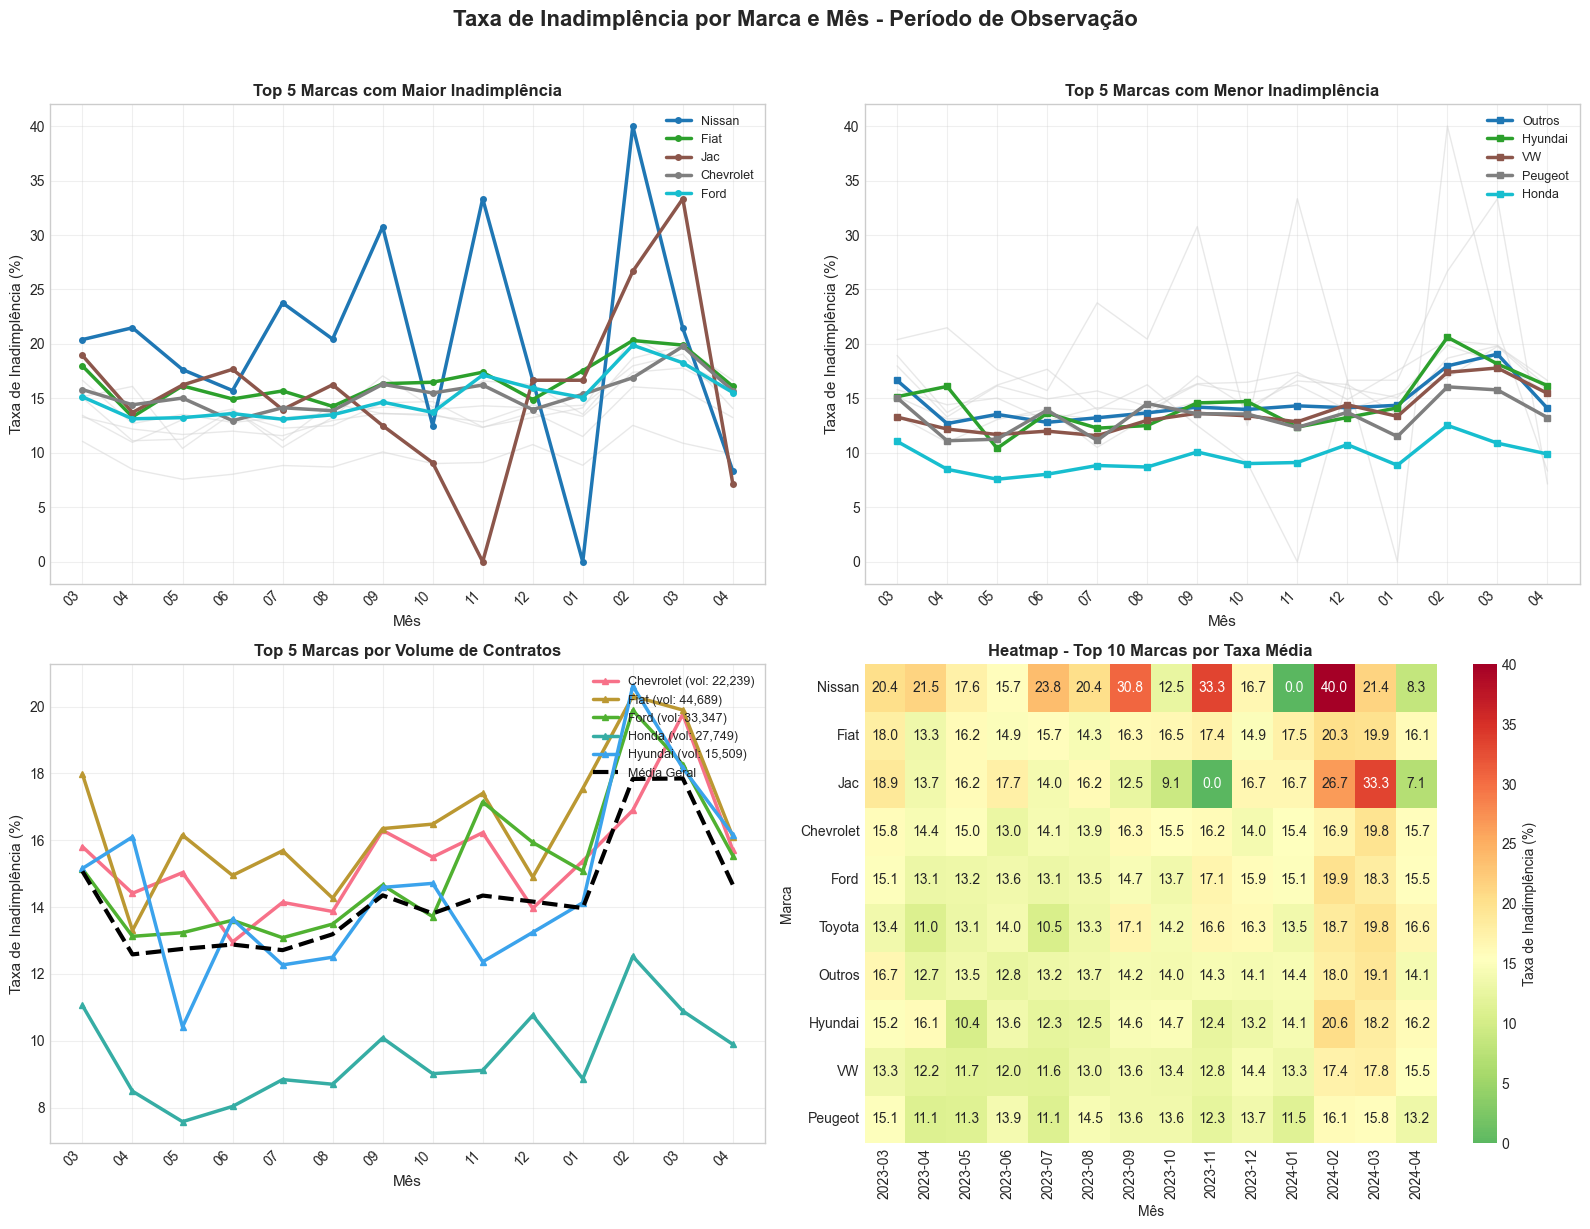


GRÁFICO COMPACTO - MARCAS MAIS RELEVANTES


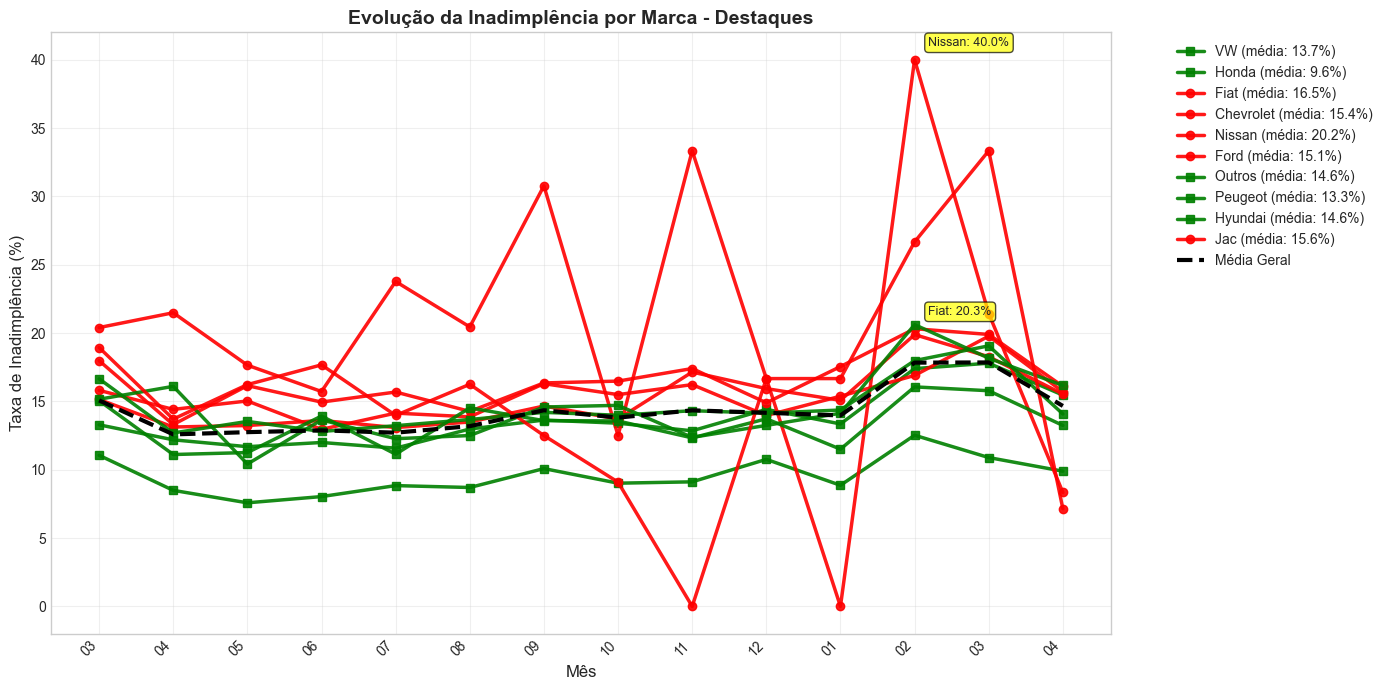


TABELA RESUMO - TAXA DE INADIMPLÊNCIA POR MARCA E MÊS

Taxa de inadimplência (%) por mês - Marcas em destaque:
mes_ano    2023-03  2023-04  2023-05  2023-06  2023-07  2023-08  2023-09  2023-10  2023-11  2023-12  2024-01  2024-02  2024-03  2024-04  Média  Volume
marca                                                                                                                                                 
Nissan        20.4     21.5     17.6     15.7     23.8     20.4     30.8     12.5     33.3     16.7      0.0     40.0     21.4      8.3   20.2    2500
Fiat          18.0     13.3     16.2     14.9     15.7     14.3     16.3     16.5     17.4     14.9     17.5     20.3     19.9     16.1   16.5   44689
Jac           18.9     13.7     16.2     17.7     14.0     16.2     12.5      9.1      0.0     16.7     16.7     26.7     33.3      7.1   15.6    2483
Chevrolet     15.8     14.4     15.0     13.0     14.1     13.9     16.3     15.5     16.2     14.0     15.4     16.9     19.8     15

In [119]:
# Configurações de visualização
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print("="*80)
print("GRÁFICO DE LINHAS: TAXA DE INADIMPLÊNCIA POR MARCA E MÊS")
print("PERÍODO DE OBSERVAÇÃO (Mar/23 a Fev/24)")
print("="*80)

# 1. FILTRAR APENAS PERÍODO DE OBSERVAÇÃO
df_obs = df[(df['per_observed'] == 1) | (df['per_observed2'] == 1)].copy()

# Criar colunas de data
df_obs['ano_mes_dt'] = pd.to_datetime(df_obs['ano_mes'].astype(str), format='%Y%m')
df_obs['mes_ano'] = df_obs['ano_mes_dt'].dt.strftime('%Y-%m')
df_obs['mes_num'] = df_obs['ano_mes_dt'].dt.month
df_obs['mes_nome'] = df_obs['ano_mes_dt'].dt.strftime('%b/%y')

print(f"\nPeríodo: {df_obs['mes_ano'].min()} a {df_obs['mes_ano'].max()}")
print(f"Total de registros: {len(df_obs):,}")

# 2. CALCULAR TAXA DE INADIMPLÊNCIA POR MARCA E MÊS
# Primeiro, vamos identificar as principais marcas (com volume significativo)
taxa_marca_geral = df_obs.groupby('marca')['target'].mean().sort_values(ascending=False)
volume_marca = df_obs.groupby('marca').size()

# Criar DataFrame com marcas que têm pelo menos 100 contratos no período
marcas_principais = volume_marca[volume_marca >= 100].index.tolist()
print(f"\nMarcas com volume >= 100 contratos: {len(marcas_principais)}")

# Calcular a taxa mensal para essas marcas
taxa_mensal_marca = pd.pivot_table(
    df_obs[df_obs['marca'].isin(marcas_principais)],
    values='target',
    index='marca',
    columns='mes_ano',
    aggfunc='mean'
) * 100  # Converter para porcentagem

# Ordenar as colunas (meses) cronologicamente
taxa_mensal_marca = taxa_mensal_marca[sorted(taxa_mensal_marca.columns)]

# 3. IDENTIFICAR AS MARCAS MAIS RELEVANTES PARA DESTACAR
# Top 5 com maior taxa média
top5_maior_taxa = taxa_marca_geral[volume_marca >= 100].head(5).index.tolist()
# Top 5 com menor taxa média
top5_menor_taxa = taxa_marca_geral[volume_marca >= 100].tail(5).index.tolist()
# Top 5 com maior volume
top5_volume = volume_marca[volume_marca >= 100].head(5).index.tolist()

# 4. GRÁFICO PRINCIPAL - TODAS AS MARCAS COM DESTAQUE PARA AS PRINCIPAIS
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Taxa de Inadimplência por Marca e Mês - Período de Observação', 
             fontsize=16, fontweight='bold', y=1.02)

# Gráfico 1: Todas as marcas (linhas cinza) com destaque para top 5 maiores taxas
ax1 = axes[0, 0]
meses = taxa_mensal_marca.columns

# Plotar todas as marcas em cinza claro
for marca in taxa_mensal_marca.index:
    if marca not in top5_maior_taxa:  # Exceto as que serão destacadas
        ax1.plot(meses, taxa_mensal_marca.loc[marca], color='lightgray', 
                linewidth=1, alpha=0.5)

# Destacar top 5 maiores taxas
cores = plt.cm.tab10(np.linspace(0, 1, len(top5_maior_taxa)))
for i, marca in enumerate(top5_maior_taxa):
    if marca in taxa_mensal_marca.index:
        ax1.plot(meses, taxa_mensal_marca.loc[marca], color=cores[i], 
                linewidth=2.5, marker='o', markersize=4, label=marca)

ax1.set_xlabel('Mês', fontsize=11)
ax1.set_ylabel('Taxa de Inadimplência (%)', fontsize=11)
ax1.set_title('Top 5 Marcas com Maior Inadimplência', fontweight='bold')
ax1.set_xticks(range(len(meses)))
ax1.set_xticklabels([m.split('-')[1] for m in meses], rotation=45, ha='right')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right', fontsize=9)

# Gráfico 2: Todas as marcas com destaque para top 5 menores taxas
ax2 = axes[0, 1]

# Plotar todas as marcas em cinza claro
for marca in taxa_mensal_marca.index:
    if marca not in top5_menor_taxa:  # Exceto as que serão destacadas
        ax2.plot(meses, taxa_mensal_marca.loc[marca], color='lightgray', 
                linewidth=1, alpha=0.5)

# Destacar top 5 menores taxas
cores = plt.cm.tab10(np.linspace(0, 1, len(top5_menor_taxa)))
for i, marca in enumerate(top5_menor_taxa):
    if marca in taxa_mensal_marca.index:
        ax2.plot(meses, taxa_mensal_marca.loc[marca], color=cores[i], 
                linewidth=2.5, marker='s', markersize=4, label=marca)

ax2.set_xlabel('Mês', fontsize=11)
ax2.set_ylabel('Taxa de Inadimplência (%)', fontsize=11)
ax2.set_title('Top 5 Marcas com Menor Inadimplência', fontweight='bold')
ax2.set_xticks(range(len(meses)))
ax2.set_xticklabels([m.split('-')[1] for m in meses], rotation=45, ha='right')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right', fontsize=9)

# Gráfico 3: Top 5 marcas por volume
ax3 = axes[1, 0]

for i, marca in enumerate(top5_volume):
    if marca in taxa_mensal_marca.index:
        ax3.plot(meses, taxa_mensal_marca.loc[marca], linewidth=2.5, 
                marker='^', markersize=5, label=f"{marca} (vol: {volume_marca[marca]:,})")

# Adicionar linha da média geral
media_geral = df_obs.groupby('mes_ano')['target'].mean() * 100
ax3.plot(media_geral.index, media_geral.values, color='black', 
        linewidth=3, linestyle='--', label='Média Geral')

ax3.set_xlabel('Mês', fontsize=11)
ax3.set_ylabel('Taxa de Inadimplência (%)', fontsize=11)
ax3.set_title('Top 5 Marcas por Volume de Contratos', fontweight='bold')
ax3.set_xticks(range(len(meses)))
ax3.set_xticklabels([m.split('-')[1] for m in meses], rotation=45, ha='right')
ax3.grid(True, alpha=0.3)
ax3.legend(loc='upper right', fontsize=9)

# Gráfico 4: Heatmap das top 10 marcas (ordenadas por taxa média)
ax4 = axes[1, 1]

# Selecionar top 10 marcas com maior taxa (com volume mínimo)
top10_geral = taxa_marca_geral[volume_marca >= 100].head(10).index
heatmap_data = taxa_mensal_marca.loc[top10_geral]

sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn_r', 
            center=heatmap_data.mean().mean(), ax=ax4, 
            cbar_kws={'label': 'Taxa de Inadimplência (%)'})
ax4.set_title('Heatmap - Top 10 Marcas por Taxa Média', fontweight='bold')
ax4.set_xlabel('Mês')
ax4.set_ylabel('Marca')

plt.tight_layout()
plt.show()

# 5. GRÁFICO COMPACTO - FOCO NAS MARCAS MAIS RELEVANTES
print("\n" + "="*80)
print("GRÁFICO COMPACTO - MARCAS MAIS RELEVANTES")
print("="*80)

fig, ax = plt.subplots(figsize=(14, 7))

# Combinar as marcas mais interessantes para análise
marcas_destaque = list(set(top5_maior_taxa + top5_menor_taxa + top5_volume[:3]))
marcas_destaque = [m for m in marcas_destaque if m in taxa_mensal_marca.index]

# Criar um dicionário de estilos para cada marca
estilos = {}
for i, marca in enumerate(marcas_destaque):
    if marca in top5_maior_taxa:
        estilos[marca] = {'color': 'red', 'marker': 'o', 'linewidth': 2.5, 'alpha': 0.9}
    elif marca in top5_menor_taxa:
        estilos[marca] = {'color': 'green', 'marker': 's', 'linewidth': 2.5, 'alpha': 0.9}
    else:
        estilos[marca] = {'color': 'blue', 'marker': '^', 'linewidth': 2, 'alpha': 0.7}

# Plotar cada marca com seu estilo
for marca in marcas_destaque:
    estilo = estilos[marca]
    ax.plot(meses, taxa_mensal_marca.loc[marca], 
           label=f"{marca} (média: {taxa_mensal_marca.loc[marca].mean():.1f}%)",
           **estilo)

# Adicionar linha da média geral
ax.plot(media_geral.index, media_geral.values, color='black', 
       linewidth=3, linestyle='--', label='Média Geral')

ax.set_xlabel('Mês', fontsize=12)
ax.set_ylabel('Taxa de Inadimplência (%)', fontsize=12)
ax.set_title('Evolução da Inadimplência por Marca - Destaques', fontweight='bold', fontsize=14)
ax.set_xticks(range(len(meses)))
ax.set_xticklabels([m.split('-')[1] for m in meses], rotation=45, ha='right')
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

# Adicionar anotações para os picos
for marca in top5_maior_taxa[:2]:
    if marca in taxa_mensal_marca.index:
        serie = taxa_mensal_marca.loc[marca]
        mes_pico = serie.idxmax()
        valor_pico = serie.max()
        ax.annotate(f'{marca}: {valor_pico:.1f}%', 
                   xy=(list(meses).index(mes_pico), valor_pico),
                   xytext=(10, 10), textcoords='offset points',
                   fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

# 6. TABELA RESUMO
print("\n" + "="*80)
print("TABELA RESUMO - TAXA DE INADIMPLÊNCIA POR MARCA E MÊS")
print("="*80)

# Criar tabela formatada
tabela_resumo = taxa_mensal_marca.loc[marcas_destaque].round(1)
tabela_resumo['Média'] = tabela_resumo.mean(axis=1).round(1)
tabela_resumo['Volume'] = volume_marca[tabela_resumo.index]

# Ordenar por média (decrescente)
tabela_resumo = tabela_resumo.sort_values('Média', ascending=False)

print("\nTaxa de inadimplência (%) por mês - Marcas em destaque:")
print("="*100)
print(tabela_resumo.to_string())

# 7. INSIGHTS RÁPIDOS
print("\n" + "="*80)
print("INSIGHTS RÁPIDOS")
print("="*80)

print(f"\n📊 Média geral do período: {media_geral.mean():.2f}%")

# Marca com maior variação
variacoes = {}
for marca in marcas_destaque:
    serie = taxa_mensal_marca.loc[marca]
    variacoes[marca] = serie.max() - serie.min()

marca_mais_variavel = max(variacoes, key=variacoes.get)
print(f"📈 Marca com maior variação: {marca_mais_variavel} (amplitude: {variacoes[marca_mais_variavel]:.1f} p.p.)")

# Mês com maior taxa geral
mes_maior_taxa = media_geral.idxmax()
print(f"📅 Mês com maior inadimplência geral: {mes_maior_taxa} ({media_geral[mes_maior_taxa]:.2f}%)")

# Mês com menor taxa geral
mes_menor_taxa = media_geral.idxmin()
print(f"📅 Mês com menor inadimplência geral: {mes_menor_taxa} ({media_geral[mes_menor_taxa]:.2f}%)")

print("\n" + "="*80)
print("ANÁLISE CONCLUÍDA")
print("="*80)

### Taxas Target, FPD e Contratado

GRÁFICO DE LINHAS: EVOLUÇÃO DAS TAXAS AO LONGO DO TEMPO
Comparação: Taxa de Contratado vs Taxa de Inadimplência (Target) vs Taxa de FPD

1. PREPARANDO OS DADOS...
Período total: 2022-03 a 2025-12
Total de registros: 848,001

2. CALCULANDO TAXAS MENSAIS...

Amostra das taxas calculadas:
         Taxa Contratado  Taxa Inadimplência  Taxa FPD
mes_ano                                               
2022-03            75.53                9.11      2.19
2022-04            75.94                8.78      2.30
2022-05            75.90                8.93      2.14
2022-06            76.30                8.86      2.23
2022-07            75.93                8.99      2.15
2022-08            76.03                9.21      2.30
2022-09            75.94                9.14      2.20
2022-10            75.76                9.15      2.24
2022-11            75.92                8.94      2.11
2022-12            75.56                8.86      2.25

3. ESTATÍSTICAS DAS TAXAS

Resumo estatístico:
     

C:\Users\kel_m\AppData\Local\Temp\ipykernel_29148\3807512655.py:123: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



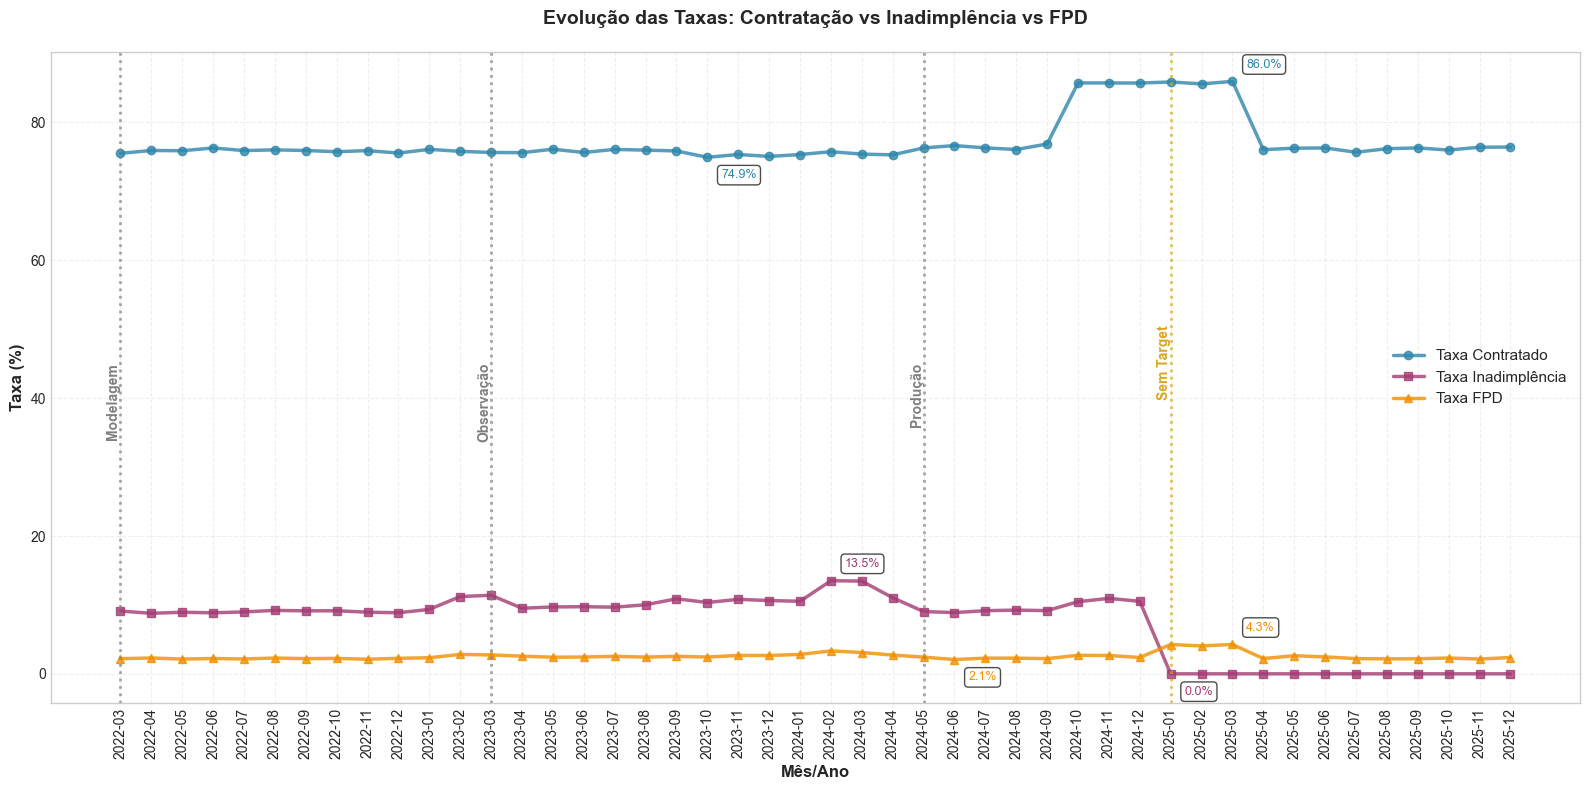


5. GRÁFICOS INDIVIDUAIS (ESCALAS OTIMIZADAS)


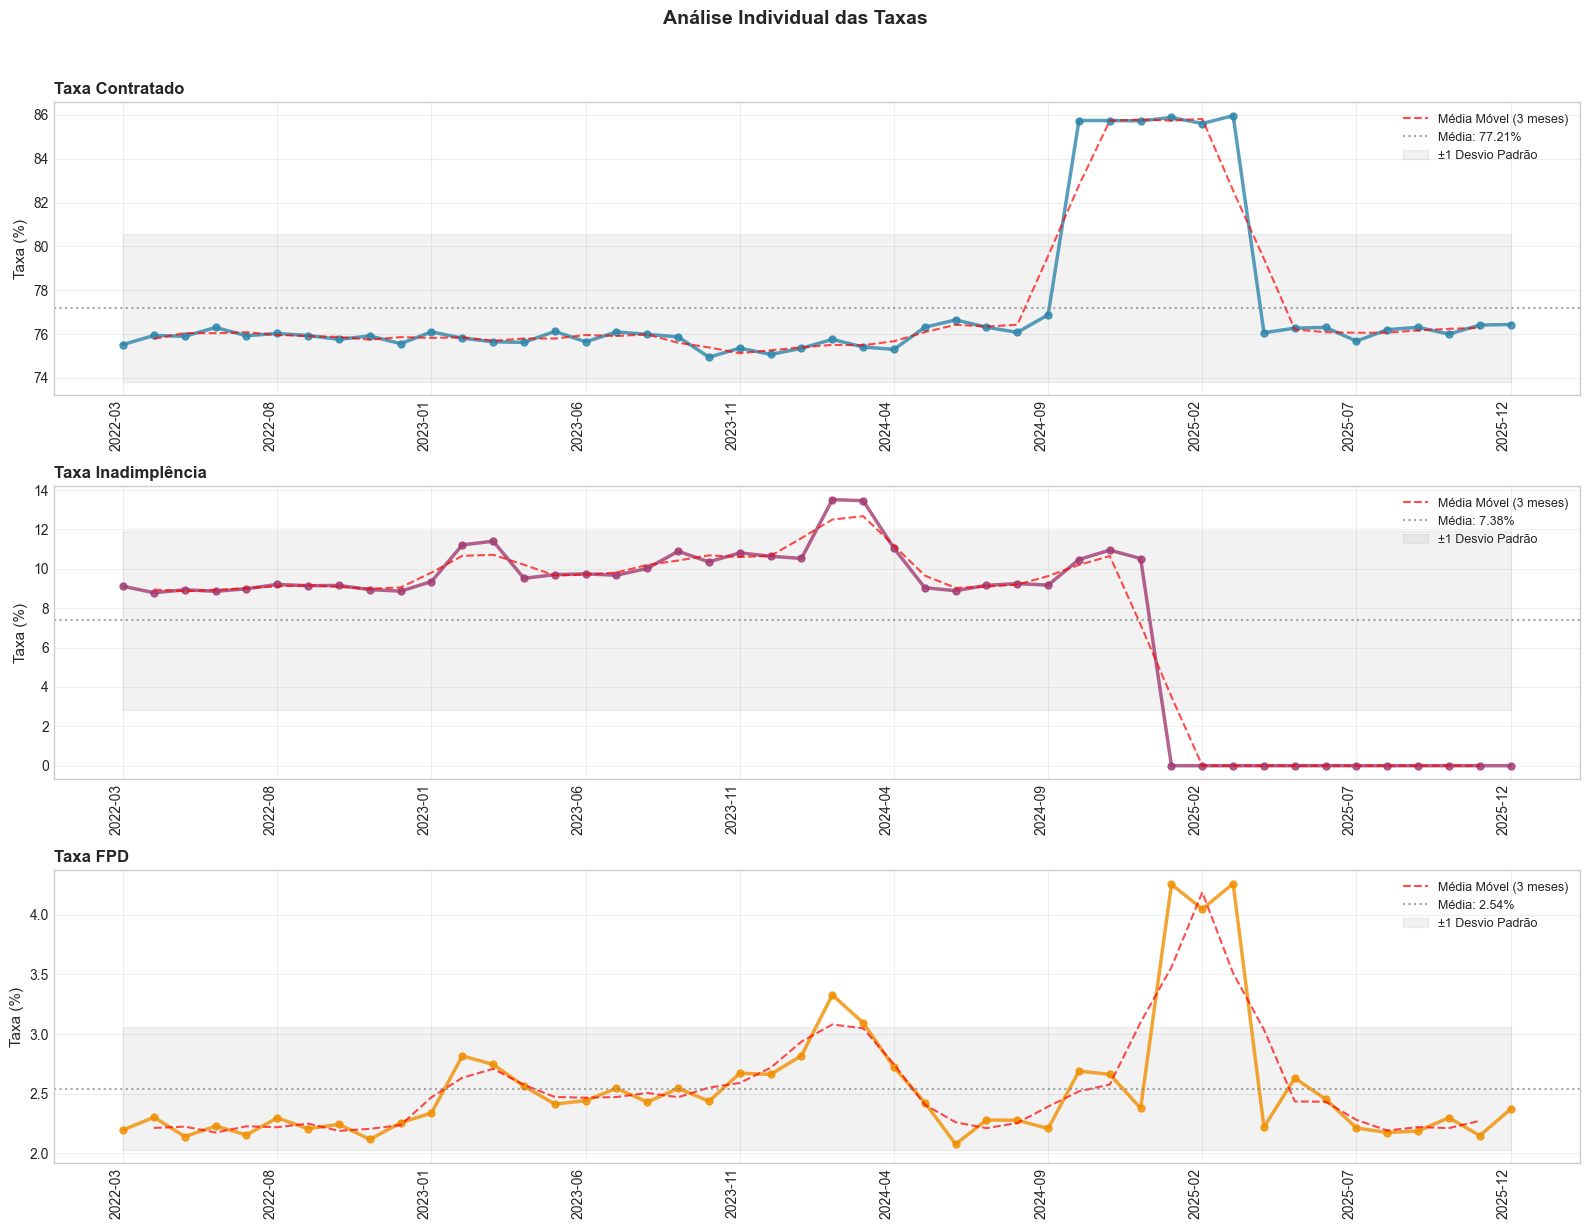


6. GRÁFICO DE ÁREA - COMPOSIÇÃO DAS TAXAS


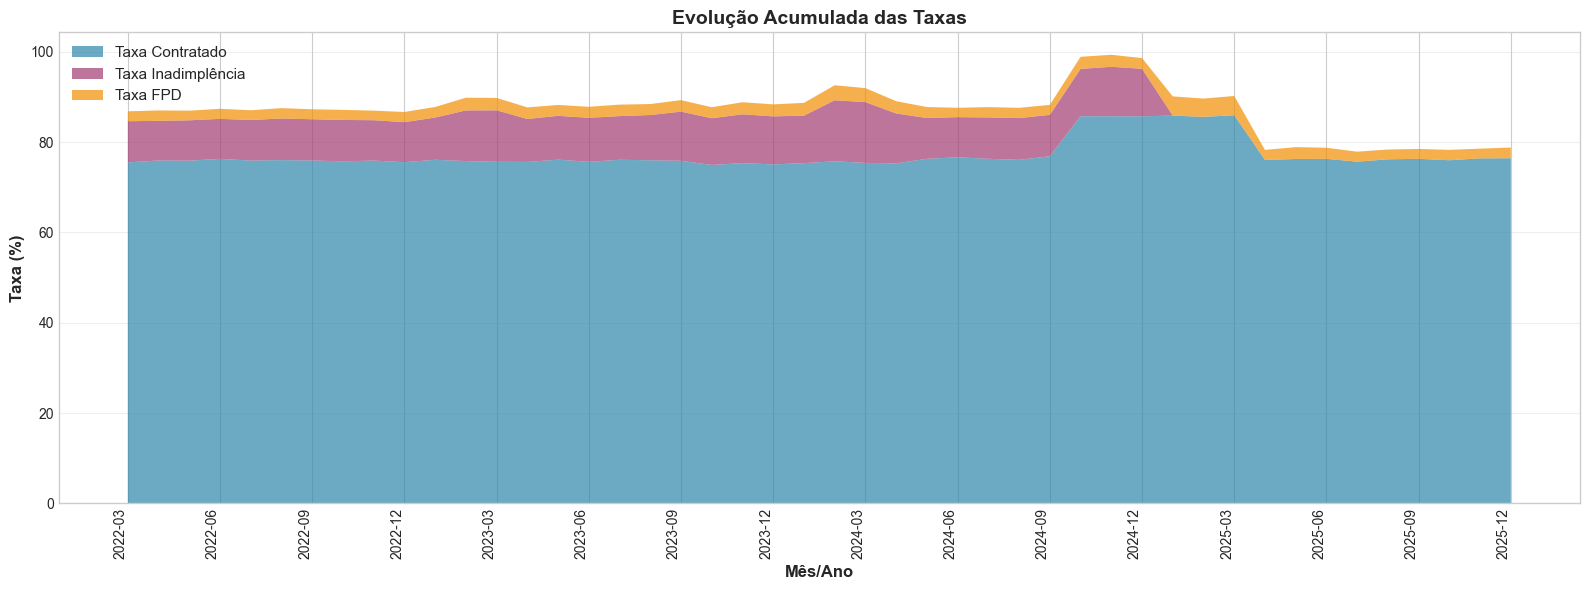


7. ANÁLISE DE CORRELAÇÃO TEMPORAL

Correlação cruzada (lag de 1 mês):
  Correlação FPD(mês anterior) vs Target: -0.179
  Correlação Contratado(mês anterior) vs Target: -0.359

8. PRINCIPAIS INSIGHTS

🔍 PADRÕES IDENTIFICADOS:
⚠️  Períodos com alta contratação E alta inadimplência:
   - 2024-10
   - 2024-11
   - 2024-12

📊 Relação FPD vs Inadimplência:
   Correlação: -0.160
   ➡️ Relação fraca

📈 Tendência Recente (últimos 6 meses):
   Taxa Contratado: 📈 subindo (+0.76 p.p.)
   Taxa Inadimplência: ➡️ estável (+0.00 p.p.)
   Taxa FPD: 📈 subindo (+0.16 p.p.)

ANÁLISE CONCLUÍDA


In [120]:
from matplotlib.ticker import PercentFormatter

# Configurações de visualização
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print("="*80)
print("GRÁFICO DE LINHAS: EVOLUÇÃO DAS TAXAS AO LONGO DO TEMPO")
print("Comparação: Taxa de Contratado vs Taxa de Inadimplência (Target) vs Taxa de FPD")
print("="*80)

# 1. PREPARAR OS DADOS
print("\n1. PREPARANDO OS DADOS...")

# Garantir que ano_mes está no formato correto
df['ano_mes_dt'] = pd.to_datetime(df['ano_mes'].astype(str), format='%Y%m')
df['mes_ano'] = df['ano_mes_dt'].dt.strftime('%Y-%m')
df['mes_num'] = df['ano_mes_dt'].dt.month
df['ano'] = df['ano_mes_dt'].dt.year

# Ordenar por data
df = df.sort_values('ano_mes_dt')

print(f"Período total: {df['mes_ano'].min()} a {df['mes_ano'].max()}")
print(f"Total de registros: {len(df):,}")

# 2. CALCULAR AS TAXAS POR MÊS
print("\n2. CALCULANDO TAXAS MENSAIS...")

# Taxa de contratados (% de contratados no mês)
# Assumindo que contratado = 1 significa que foi contratado
taxa_contratado = df.groupby('mes_ano').agg({
    'contratado': lambda x: (x == 1).mean() * 100  # Percentual de contratados
})

# Taxa de inadimplência (target = 1)
taxa_target = df.groupby('mes_ano').agg({
    'target': lambda x: (x == 1).mean() * 100 if x.notna().any() else np.nan
})

# Taxa de FPD (FPD = 1)
taxa_fpd = df.groupby('mes_ano').agg({
    'FPD': lambda x: (x == 1).mean() * 100 if x.notna().any() else np.nan
})

# Combinar em um único DataFrame
taxas_mensais = pd.DataFrame({
    'Taxa Contratado': taxa_contratado['contratado'],
    'Taxa Inadimplência': taxa_target['target'],
    'Taxa FPD': taxa_fpd['FPD']
})

# Remover meses sem dados suficientes
taxas_mensais = taxas_mensais.dropna(thresh=2)  # Manter meses com pelo menos 2 taxas

print("\nAmostra das taxas calculadas:")
print(taxas_mensais.head(10).round(2))

# 3. ESTATÍSTICAS DESCRITIVAS
print("\n" + "="*80)
print("3. ESTATÍSTICAS DAS TAXAS")
print("="*80)

print("\nResumo estatístico:")
print(taxas_mensais.describe().round(2))

# Correlação entre as taxas
print("\nCorrelação entre as taxas:")
correlacoes = taxas_mensais.corr()
print(correlacoes.round(3))

# 4. GRÁFICO PRINCIPAL - 3 LINHAS NO MESMO GRÁFICO
print("\n" + "="*80)
print("4. GRÁFICO PRINCIPAL - EVOLUÇÃO DAS 3 TAXAS")
print("="*80)

fig, ax = plt.subplots(figsize=(16, 8))

# Definir cores e estilos
cores = {
    'Taxa Contratado': '#2E86AB',  # Azul
    'Taxa Inadimplência': '#A23B72',  # Roxo
    'Taxa FPD': '#F18F01'  # Laranja
}

marcadores = {
    'Taxa Contratado': 'o',
    'Taxa Inadimplência': 's',
    'Taxa FPD': '^'
}

# Plotar cada linha
for coluna in taxas_mensais.columns:
    ax.plot(taxas_mensais.index, taxas_mensais[coluna], 
            marker=marcadores[coluna], 
            linewidth=2.5, 
            markersize=6,
            color=cores[coluna],
            label=coluna,
            alpha=0.8)

# Adicionar linhas de tendência (média móvel de 3 meses)
# window = 3
# for coluna in taxas_mensais.columns:
#     media_movel = taxas_mensais[coluna].rolling(window=window, center=True).mean()
#     ax.plot(taxas_mensais.index, media_movel, 
#             color=cores[coluna], 
#             linewidth=1.5, 
#             linestyle='--',
#             alpha=0.5)

# Configurar o gráfico
ax.set_xlabel('Mês/Ano', fontsize=12, fontweight='bold')
ax.set_ylabel('Taxa (%)', fontsize=12, fontweight='bold')
ax.set_title('Evolução das Taxas: Contratação vs Inadimplência vs FPD', 
             fontsize=14, fontweight='bold', pad=20)

# Configurar eixo X
meses = taxas_mensais.index.tolist()

# ax.set_xticks(range(0, len(meses), max(1, len(meses)//12)))
ax.set_xticklabels(meses, rotation=90)
# ax.set_xticklabels([meses[i] for i in range(0, len(meses), max(1, len(meses)//12))], 
                #    rotation=90, ha='right')

# Adicionar grade
ax.grid(True, alpha=0.3, linestyle='--')

# Adicionar legenda
ax.legend(loc='center right', fontsize=11, framealpha=0.9)

# Adicionar anotações para os pontos mais relevantes
for coluna in taxas_mensais.columns:
    serie = taxas_mensais[coluna].dropna()
    if len(serie) > 0:
        # Ponto máximo
        idx_max = serie.idxmax()
        valor_max = serie.max()
        ax.annotate(f'{valor_max:.1f}%', 
                   xy=(idx_max, valor_max),
                   xytext=(10, 10), textcoords='offset points',
                   fontsize=9, color=cores[coluna],
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
        
        # Ponto mínimo
        idx_min = serie.idxmin()
        valor_min = serie.min()
        ax.annotate(f'{valor_min:.1f}%', 
                   xy=(idx_min, valor_min),
                   xytext=(10, -15), textcoords='offset points',
                   fontsize=9, color=cores[coluna],
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

# Adicionar linhas verticais para separar os períodos
periodos = {
    'Modelagem': '2022-03',
    'Observação': '2023-03',
    'Produção': '2024-05'
}

for periodo, data in periodos.items():
    if data in taxas_mensais.index:
        ax.axvline(x=data, color='gray', linestyle=':', linewidth=2, alpha=0.7)
        ax.text(data, ax.get_ylim()[1]*0.5, periodo, 
                rotation=90, fontsize=10, color='gray', fontweight='bold',
                ha='right', va='top')


ax.axvline(x='2025-01', color='goldenrod', linestyle=':', linewidth=2, alpha=0.7)
ax.text('2025-01', ax.get_ylim()[1]*0.5, 'Sem Target', 
                rotation=90, fontsize=10, color='goldenrod', fontweight='bold',
                ha='right', va='center')
plt.tight_layout()
plt.show()

# 5. GRÁFICO COM SUBPLOTS SEPARADOS
print("\n" + "="*80)
print("5. GRÁFICOS INDIVIDUAIS (ESCALAS OTIMIZADAS)")
print("="*80)

fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle('Análise Individual das Taxas', fontsize=14, fontweight='bold', y=1.02)

for idx, (coluna, ax) in enumerate(zip(taxas_mensais.columns, axes)):
    serie = taxas_mensais[coluna].dropna()
    
    # Plotar linha
    ax.plot(serie.index, serie.values, 
            marker='o', linewidth=2.5, markersize=5,
            color=cores[coluna], alpha=0.8)
    
    # Adicionar média móvel
    media_movel = serie.rolling(window=3, center=True).mean()
    ax.plot(serie.index, media_movel, 
            color='red', linewidth=1.5, linestyle='--', alpha=0.7, label='Média Móvel (3 meses)')
    
    # Configurar eixos
    ax.set_ylabel('Taxa (%)', fontsize=11)
    ax.set_title(coluna, fontweight='bold', fontsize=12, loc='left')
    ax.grid(True, alpha=0.3)
    
    # Configurar eixo X
    ax.set_xticks(range(0, len(serie), max(1, len(serie)//8)))
    ax.set_xticklabels([serie.index[i] for i in range(0, len(serie), max(1, len(serie)//8))], 
                       rotation=90, ha='right')
    
    # Adicionar linha da média
    media = serie.mean()
    ax.axhline(y=media, color='gray', linestyle=':', linewidth=1.5, 
               alpha=0.7, label=f'Média: {media:.2f}%')
    
    # Adicionar banda de desvio padrão
    std = serie.std()
    ax.fill_between(serie.index, media - std, media + std, 
                    alpha=0.1, color='gray', label=f'±1 Desvio Padrão')
    
    ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

# 6. GRÁFICO DE ÁREA EMPILHADA
print("\n" + "="*80)
print("6. GRÁFICO DE ÁREA - COMPOSIÇÃO DAS TAXAS")
print("="*80)

fig, ax = plt.subplots(figsize=(16, 6))

# Para área empilhada, precisamos normalizar ou usar valores absolutos
# Vou usar as taxas como estão para mostrar a evolução relativa
ax.stackplot(taxas_mensais.index, 
             taxas_mensais['Taxa Contratado'].fillna(0),
             taxas_mensais['Taxa Inadimplência'].fillna(0),
             taxas_mensais['Taxa FPD'].fillna(0),
             labels=['Taxa Contratado', 'Taxa Inadimplência', 'Taxa FPD'],
             colors=[cores['Taxa Contratado'], cores['Taxa Inadimplência'], cores['Taxa FPD']],
             alpha=0.7)

ax.set_xlabel('Mês/Ano', fontsize=12, fontweight='bold')
ax.set_ylabel('Taxa (%)', fontsize=12, fontweight='bold')
ax.set_title('Evolução Acumulada das Taxas', fontsize=14, fontweight='bold')
ax.set_xticks(range(0, len(taxas_mensais.index), max(1, len(taxas_mensais.index)//12)))
ax.set_xticklabels([taxas_mensais.index[i] for i in range(0, len(taxas_mensais.index), max(1, len(taxas_mensais.index)//12))], 
                   rotation=90, ha='right')
ax.grid(True, alpha=0.3, axis='y')
ax.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

# 7. ANÁLISE DE CORRELAÇÃO TEMPORAL
print("\n" + "="*80)
print("7. ANÁLISE DE CORRELAÇÃO TEMPORAL")
print("="*80)

# Correlação com lag (será que FPD de um mês prevê target do mês seguinte?)
print("\nCorrelação cruzada (lag de 1 mês):")

# Criar versões com lag
taxas_lag = taxas_mensais.copy()
taxas_lag['FPD_lag1'] = taxas_lag['Taxa FPD'].shift(1)
taxas_lag['Contratado_lag1'] = taxas_lag['Taxa Contratado'].shift(1)

# Correlação do lag com target
corr_fpd_lag = taxas_lag[['Taxa Inadimplência', 'FPD_lag1']].corr().iloc[0,1]
corr_cont_lag = taxas_lag[['Taxa Inadimplência', 'Contratado_lag1']].corr().iloc[0,1]

print(f"  Correlação FPD(mês anterior) vs Target: {corr_fpd_lag:.3f}")
print(f"  Correlação Contratado(mês anterior) vs Target: {corr_cont_lag:.3f}")

# 8. INSIGHTS FINAIS
print("\n" + "="*80)
print("8. PRINCIPAIS INSIGHTS")
print("="*80)

# Identificar períodos de maior/alerta
print("\n🔍 PADRÕES IDENTIFICADOS:")

# Quando a taxa de contratado sobe e a inadimplência sobe junto?
contratado_alto = taxas_mensais['Taxa Contratado'] > taxas_mensais['Taxa Contratado'].quantile(0.75)
inad_alta = taxas_mensais['Taxa Inadimplência'] > taxas_mensais['Taxa Inadimplência'].quantile(0.75)
periodos_alerta = taxas_mensais[contratado_alto & inad_alta].index.tolist()

if periodos_alerta:
    print("⚠️  Períodos com alta contratação E alta inadimplência:")
    for p in periodos_alerta:
        print(f"   - {p}")

# Relação FPD vs Target
print("\n📊 Relação FPD vs Inadimplência:")
corr_fpd_target = taxas_mensais[['Taxa FPD', 'Taxa Inadimplência']].corr().iloc[0,1]
print(f"   Correlação: {corr_fpd_target:.3f}")
if corr_fpd_target > 0.5:
    print("   ➡️ Forte relação positiva: meses com mais FPD tendem a ter mais inadimplência")
elif corr_fpd_target > 0.3:
    print("   ➡️ Relação moderada positiva")
else:
    print("   ➡️ Relação fraca")

# Tendência recente (últimos 6 meses)
print("\n📈 Tendência Recente (últimos 6 meses):")
ultimos_6 = taxas_mensais.tail(6)
for coluna in ultimos_6.columns:
    inicio = ultimos_6.iloc[0][coluna]
    fim = ultimos_6.iloc[-1][coluna]
    variacao = fim - inicio
    tendencia = "📈 subindo" if variacao > 0 else "📉 caindo" if variacao < 0 else "➡️ estável"
    print(f"   {coluna}: {tendencia} ({variacao:+.2f} p.p.)")

print("\n" + "="*80)
print("ANÁLISE CONCLUÍDA")
print("="*80)

GRÁFICO DE LINHAS: EVOLUÇÃO DAS TAXAS AO LONGO DO TEMPO
Com destaque para o período FEV-ABR em todos os anos

1. PREPARANDO OS DADOS...
Período total: 2022-03 a 2025-12
Total de registros: 848,001

2. CALCULANDO TAXAS MENSAIS...

Amostra das taxas calculadas:
         Taxa Contratado  Taxa Inadimplência  Taxa FPD  mes_num   ano
mes_ano                                                              
2022-03            75.53                9.11      2.19        3  2022
2022-04            75.94                8.78      2.30        4  2022
2022-05            75.90                8.93      2.14        5  2022
2022-06            76.30                8.86      2.23        6  2022
2022-07            75.93                8.99      2.15        7  2022
2022-08            76.03                9.21      2.30        8  2022
2022-09            75.94                9.14      2.20        9  2022
2022-10            75.76                9.15      2.24       10  2022
2022-11            75.92                

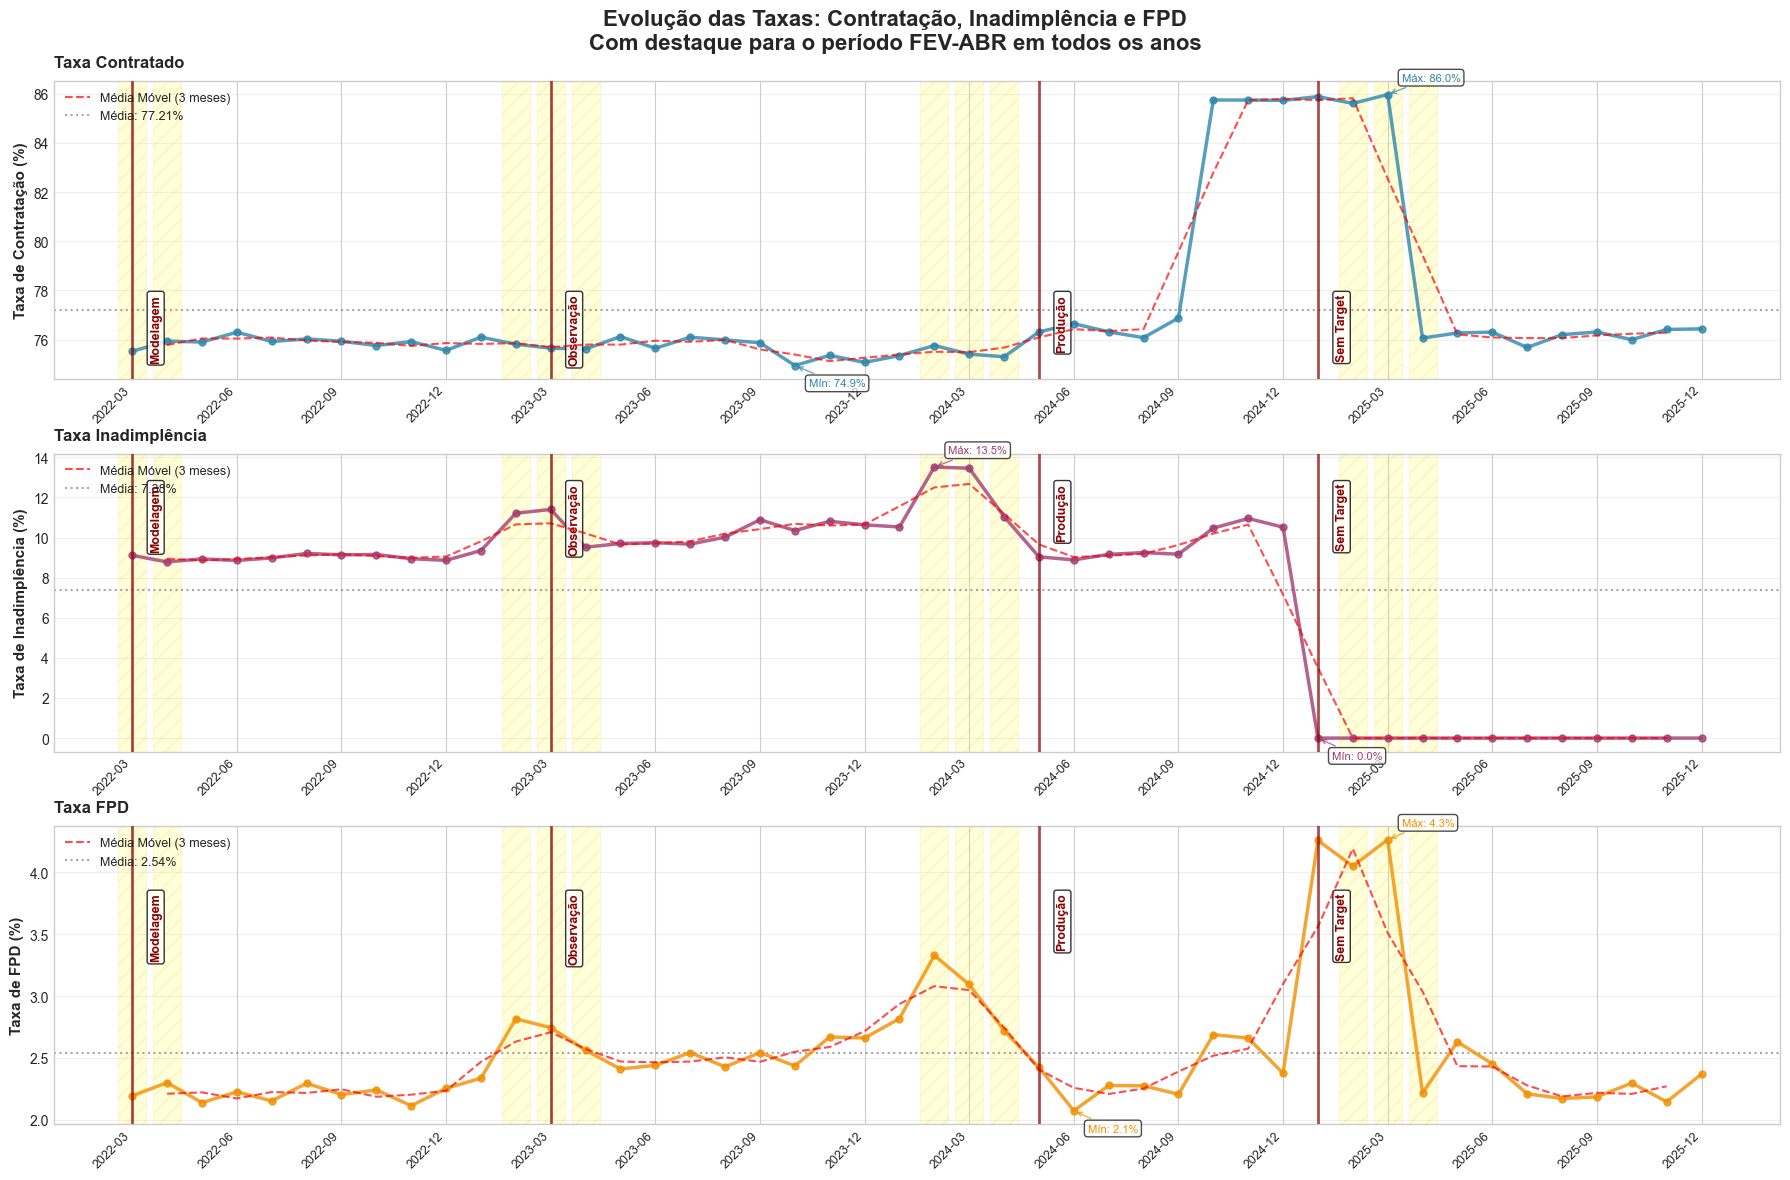


5. GRÁFICO COMPACTO - TAXAS NORMALIZADAS


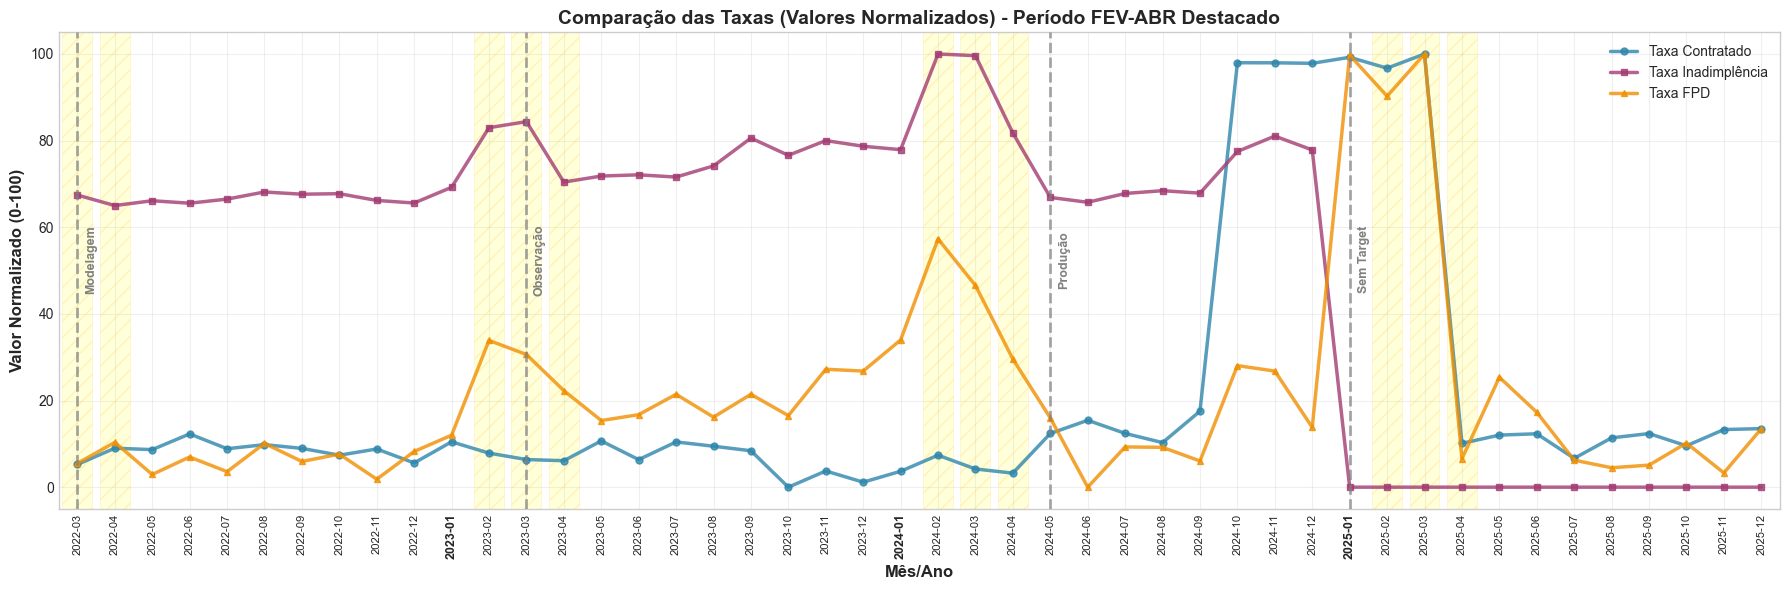


6. ANÁLISE DO PERÍODO FEV-ABR

Comparação: Período FEV-ABR vs Demais meses

Taxa Contratado:
  FEV-ABR: média = 77.51%, mediana = 75.76%, std = 4.09%
  Outros meses: média = 77.11%, mediana = 76.10%, std = 3.18%
  Diferença estatística: p-valor = 0.7335 (não significativa)

Taxa Inadimplência:
  FEV-ABR: média = 8.00%, mediana = 9.52%, std = 5.36%
  Outros meses: média = 7.18%, mediana = 9.15%, std = 4.33%
  Diferença estatística: p-valor = 0.6050 (não significativa)

Taxa FPD:
  FEV-ABR: média = 2.94%, mediana = 2.74%, std = 0.70%
  Outros meses: média = 2.42%, mediana = 2.34%, std = 0.37%
  Diferença estatística: p-valor = 0.0025 (significativa)

7. DISTRIBUIÇÃO DAS TAXAS POR MÊS


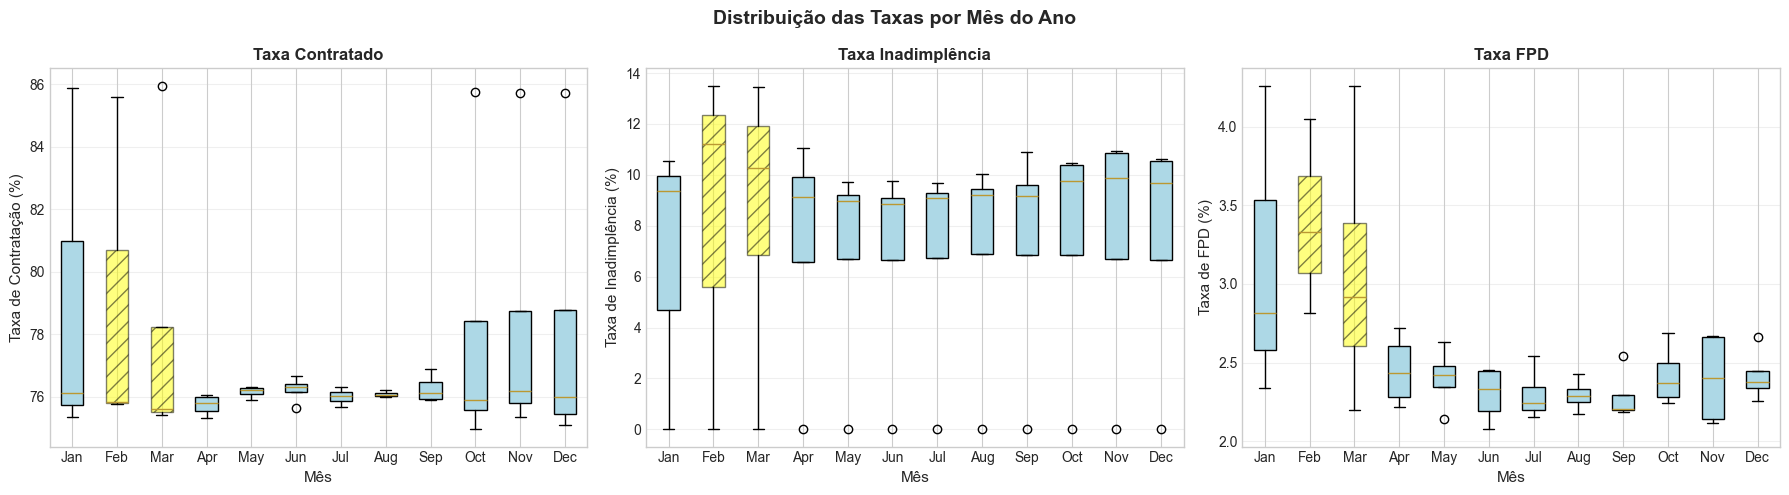


ANÁLISE CONCLUÍDA


In [121]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
# import seaborn as sns
# import calendar
# from datetime import datetime

# Configurações de visualização
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print("="*80)
print("GRÁFICO DE LINHAS: EVOLUÇÃO DAS TAXAS AO LONGO DO TEMPO")
print("Com destaque para o período FEV-ABR em todos os anos")
print("="*80)

# 1. PREPARAR OS DADOS
print("\n1. PREPARANDO OS DADOS...")

# Garantir que ano_mes está no formato correto
df['ano_mes_dt'] = pd.to_datetime(df['ano_mes'].astype(str), format='%Y%m')
df['mes_ano'] = df['ano_mes_dt'].dt.strftime('%Y-%m')
df['mes_num'] = df['ano_mes_dt'].dt.month
df['ano'] = df['ano_mes_dt'].dt.year
df['mes_nome'] = df['ano_mes_dt'].dt.strftime('%b')

# Ordenar por data
df = df.sort_values('ano_mes_dt')

print(f"Período total: {df['mes_ano'].min()} a {df['mes_ano'].max()}")
print(f"Total de registros: {len(df):,}")

# 2. CALCULAR AS TAXAS POR MÊS
print("\n2. CALCULANDO TAXAS MENSAIS...")

# Taxa de contratados (% de contratados no mês)
taxa_contratado = df.groupby('mes_ano').agg({
    'contratado': lambda x: (x == 1).mean() * 100  # Percentual de contratados
})

# Taxa de inadimplência (target = 1)
taxa_target = df.groupby('mes_ano').agg({
    'target': lambda x: (x == 1).mean() * 100 if x.notna().any() else np.nan
})

# Taxa de FPD (FPD = 1)
taxa_fpd = df.groupby('mes_ano').agg({
    'FPD': lambda x: (x == 1).mean() * 100 if x.notna().any() else np.nan
})

# Combinar em um único DataFrame
taxas_mensais = pd.DataFrame({
    'Taxa Contratado': taxa_contratado['contratado'],
    'Taxa Inadimplência': taxa_target['target'],
    'Taxa FPD': taxa_fpd['FPD']
})

# Remover meses sem dados suficientes
taxas_mensais = taxas_mensais.dropna(thresh=2)

# Adicionar informações de mês e ano para referência
taxas_mensais['mes_num'] = pd.to_datetime(taxas_mensais.index).month
taxas_mensais['ano'] = pd.to_datetime(taxas_mensais.index).year

print("\nAmostra das taxas calculadas:")
print(taxas_mensais.head(10).round(2))

# 3. IDENTIFICAR OS PERÍODOS PARA AS LINHAS VERTICAIS
print("\n3. CONFIGURANDO PERÍODOS...")

# Datas importantes
periodos = {
    'Modelagem': '2022-03',
    'Observação': '2023-03',
    # 'Produção': '2024-03',  # Ajustei para março (fim do período de observação)
    'Produção': '2024-05',
    'Sem Target': '2025-01',
}

# Converter para índices numéricos para facilitar
indices_periodos = {}
for nome, data in periodos.items():
    if data in taxas_mensais.index:
        indices_periodos[nome] = list(taxas_mensais.index).index(data)
    else:
        # Encontrar o índice mais próximo
        datas = pd.to_datetime(taxas_mensais.index)
        data_alvo = pd.to_datetime(data)
        idx_mais_proximo = (datas - data_alvo).abs().argmin()
        indices_periodos[nome] = idx_mais_proximo
        print(f"  {nome}: data {data} não encontrada, usando {taxas_mensais.index[idx_mais_proximo]}")

print("\nPeríodos demarcados:")
for nome, idx in indices_periodos.items():
    print(f"  {nome}: {taxas_mensais.index[idx]} (índice {idx})")

# 4. IDENTIFICAR MESES DE FEVEREIRO A ABRIL PARA HACHURAR
meses_hachurados = []
for i, mes_ano in enumerate(taxas_mensais.index):
    mes = int(mes_ano.split('-')[1])
    if mes in [2, 3, 4]:  # Fevereiro, Março, Abril
        meses_hachurados.append(i)

print(f"\nMeses hachurados (Fev-Abr): {len(meses_hachurados)} meses")
print(f"  {[taxas_mensais.index[i] for i in meses_hachurados[:5]]}...")

# 5. CRIAR O GRÁFICO PRINCIPAL COM 3 SUBPLOTS
print("\n" + "="*80)
print("4. CRIANDO GRÁFICO COM 3 SUBPLOTS E HACHURAS")
print("="*80)

# Configurar a figura
fig, axes = plt.subplots(3, 1, figsize=(18, 12))
fig.suptitle('Evolução das Taxas: Contratação, Inadimplência e FPD\nCom destaque para o período FEV-ABR em todos os anos', 
             fontsize=16, fontweight='bold', y=0.98)

# Definir cores e estilos para cada taxa
cores = {
    'Taxa Contratado': '#2E86AB',  # Azul
    'Taxa Inadimplência': '#A23B72',  # Roxo
    'Taxa FPD': '#F18F01'  # Laranja
}

# Lista das taxas para plotar
taxas = ['Taxa Contratado', 'Taxa Inadimplência', 'Taxa FPD']
titulos = ['Taxa de Contratação (%)', 'Taxa de Inadimplência (%)', 'Taxa de FPD (%)']

# Criar cada subplot
for idx, (taxa, titulo, ax) in enumerate(zip(taxas, titulos, axes)):
    serie = taxas_mensais[taxa].dropna()
    indices_numericos = range(len(serie))
    
    # Plotar a linha principal
    ax.plot(indices_numericos, serie.values, 
            marker='o', linewidth=2.5, markersize=5,
            color=cores[taxa], alpha=0.8, zorder=3)
    
    # Adicionar linha de tendência (média móvel de 3 meses)
    media_movel = serie.rolling(window=3, center=True).mean()
    ax.plot(indices_numericos, media_movel.values, 
            color='red', linewidth=1.5, linestyle='--', alpha=0.7, 
            label='Média Móvel (3 meses)', zorder=4)
    
    # Adicionar linha da média geral
    media_geral = serie.mean()
    ax.axhline(y=media_geral, color='gray', linestyle=':', linewidth=1.5, 
               alpha=0.7, label=f'Média: {media_geral:.2f}%', zorder=2)
    
    # ADICIONAR HACHURAS NOS MESES DE FEV-ABR
    y_min, y_max = ax.get_ylim()
    for i in meses_hachurados:
        if i < len(serie):  # Garantir que o índice existe
            # Criar um retângulo hachurado para cada mês
            rect = Rectangle((i-0.4, y_min), 0.8, y_max - y_min,
                           facecolor='yellow', alpha=0.15, hatch='//', 
                           edgecolor='orange', linewidth=0.5, zorder=1)
            ax.add_patch(rect)
    
    # ADICIONAR LINHAS VERTICAIS PARA OS PERÍODOS
    for nome_periodo, idx_periodo in indices_periodos.items():
        if idx_periodo < len(serie):
            cor = 'darkgreen' if 'Início' in nome_periodo else 'darkred'
            ax.axvline(x=idx_periodo, color=cor, linestyle='-', 
                      linewidth=2, alpha=0.7, zorder=5)
            
            # Adicionar rótulo
            y_pos = y_max * 0.9 - (0.05 * idx)  # Posição diferente para cada subplot
            ax.text(idx_periodo + 0.5, y_pos, nome_periodo, 
                   rotation=90, fontsize=9, color=cor, fontweight='bold',
                   ha='left', va='top', bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))
    
    # Configurar eixos
    ax.set_ylabel(titulo, fontsize=11, fontweight='bold')
    ax.set_title(f'{taxa}', fontweight='bold', fontsize=12, loc='left', pad=10)
    ax.grid(True, alpha=0.3, axis='y', zorder=0)
    
    # Configurar eixo X com labels dos meses
    # Mostrar apenas alguns labels para não poluir
    passo = max(1, len(serie) // 12)
    ticks_positions = list(range(0, len(serie), passo))
    ticks_labels = [serie.index[i] for i in ticks_positions]
    
    ax.set_xticks(ticks_positions)
    ax.set_xticklabels(ticks_labels, rotation=45, ha='right', fontsize=9)
    
    # Adicionar legenda
    ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
    
    # Adicionar anotações nos pontos mais altos e baixos
    max_idx = serie.idxmax()
    max_val = serie.max()
    max_pos = list(serie.index).index(max_idx)
    ax.annotate(f'Máx: {max_val:.1f}%', 
               xy=(max_pos, max_val),
               xytext=(10, 10), textcoords='offset points',
               fontsize=8, color=cores[taxa],
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7),
               arrowprops=dict(arrowstyle='->', color=cores[taxa], alpha=0.7))
    
    min_idx = serie.idxmin()
    min_val = serie.min()
    min_pos = list(serie.index).index(min_idx)
    ax.annotate(f'Mín: {min_val:.1f}%', 
               xy=(min_pos, min_val),
               xytext=(10, -15), textcoords='offset points',
               fontsize=8, color=cores[taxa],
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7),
               arrowprops=dict(arrowstyle='->', color=cores[taxa], alpha=0.7))

# Ajustar layout
plt.tight_layout()
plt.subplots_adjust(top=0.92, hspace=0.25)
plt.show()

# 6. GRÁFICO ALTERNATIVO - VERSÃO MAIS COMPACTA COM ESCALAS NORMALIZADAS
print("\n" + "="*80)
print("5. GRÁFICO COMPACTO - TAXAS NORMALIZADAS")
print("="*80)

fig, ax = plt.subplots(figsize=(18, 6))

# Normalizar as séries para comparação (escala 0-100)
for taxa in taxas:
    serie = taxas_mensais[taxa].dropna()
    serie_norm = (serie - serie.min()) / (serie.max() - serie.min()) * 100
    indices_numericos = range(len(serie))
    
    ax.plot(indices_numericos, serie_norm.values, 
            marker=marcadores[taxa], linewidth=2.5, markersize=5,
            color=cores[taxa], alpha=0.8, label=taxa, zorder=3)

# Adicionar hachuras
y_min, y_max = ax.get_ylim()
for i in meses_hachurados:
    rect = Rectangle((i-0.4, y_min), 0.8, y_max - y_min,
                   facecolor='yellow', alpha=0.15, hatch='//', 
                   edgecolor='orange', linewidth=0.5, zorder=1)
    ax.add_patch(rect)

# Adicionar linhas verticais dos períodos
for nome_periodo, idx_periodo in indices_periodos.items():
    cor = 'darkgreen' if 'Início' in nome_periodo else 'gray'
    ax.axvline(x=idx_periodo, color=cor, linestyle='--', 
              linewidth=2, alpha=0.7, zorder=5)
    ax.text(idx_periodo + 0.2, y_max * 0.5, nome_periodo, 
           rotation=90, fontsize=9, color=cor, fontweight='bold',
           ha='left', va='center')#, bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

ax.set_xlabel('Mês/Ano', fontsize=12, fontweight='bold')
ax.set_ylabel('Valor Normalizado (0-100)', fontsize=12, fontweight='bold')
ax.set_title('Comparação das Taxas (Valores Normalizados) - Período FEV-ABR Destacado', 
             fontsize=14, fontweight='bold')

# Configurar eixo X
# serie_ref = taxas_mensais['Taxa Contratado'].dropna()
# passo = max(1, len(serie_ref) // 12)
# ticks_positions = list(range(0, len(serie_ref), passo))
# ticks_labels = [serie_ref.index[i] for i in ticks_positions]
# ax.set_xticks(ticks_positions)
# ax.set_xticklabels(ticks_labels, rotation=90, ha='right')


# CONFIGURAR EIXO X - MOSTRAR TODOS OS MESES
ax.set_xlim(-0.5, len(serie) - 0.5)  # Ajustar limites para mostrar todos os pontos

# Configurar ticks para mostrar TODOS os meses
ax.set_xticks(indices_numericos)  # Todos os índices
ax.set_xticklabels(serie.index, rotation=90, ha='center', fontsize=8)  # Rótulos verticais

# Opcional: destacar alguns ticks com negrito (início de cada ano)
for i, mes_ano in enumerate(serie.index):
    if mes_ano.endswith('-01'):  # Janeiro de cada ano
        ax.get_xticklabels()[i].set_fontweight('bold')
        ax.get_xticklabels()[i].set_fontsize(9)


ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.show()

# 7. ANÁLISE DO PERÍODO HACHURADO
print("\n" + "="*80)
print("6. ANÁLISE DO PERÍODO FEV-ABR")
print("="*80)

# Criar coluna indicando se é período hachurado
taxas_mensais['periodo_hachurado'] = taxas_mensais['mes_num'].isin([2, 3, 4])

# Estatísticas comparativas
print("\nComparação: Período FEV-ABR vs Demais meses")
print("="*60)

for taxa in taxas:
    print(f"\n{taxa}:")
    
    # Período hachurado
    hachurado = taxas_mensais[taxas_mensais['periodo_hachurado']][taxa].dropna()
    if len(hachurado) > 0:
        print(f"  FEV-ABR: média = {hachurado.mean():.2f}%, "
              f"mediana = {hachurado.median():.2f}%, "
              f"std = {hachurado.std():.2f}%")
    
    # Demais períodos
    outros = taxas_mensais[~taxas_mensais['periodo_hachurado']][taxa].dropna()
    if len(outros) > 0:
        print(f"  Outros meses: média = {outros.mean():.2f}%, "
              f"mediana = {outros.median():.2f}%, "
              f"std = {outros.std():.2f}%")
    
    # Teste t para diferença de médias
    if len(hachurado) > 0 and len(outros) > 0:
        t_stat, p_val = stats.ttest_ind(hachurado, outros)
        print(f"  Diferença estatística: p-valor = {p_val:.4f} "
              f"({'significativa' if p_val < 0.05 else 'não significativa'})")

# 8. GRÁFICO DE BOXPLOT POR MÊS
print("\n" + "="*80)
print("7. DISTRIBUIÇÃO DAS TAXAS POR MÊS")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribuição das Taxas por Mês do Ano', fontsize=14, fontweight='bold')

for idx, (taxa, ax) in enumerate(zip(taxas, axes)):
    # Preparar dados para boxplot
    dados_por_mes = []
    meses_nomes = []
    
    for mes in range(1, 13):
        dados_mes = taxas_mensais[taxas_mensais['mes_num'] == mes][taxa].dropna()
        if len(dados_mes) > 0:
            dados_por_mes.append(dados_mes.values)
            meses_nomes.append(calendar.month_abbr[mes])
    
    # Criar boxplot
    bp = ax.boxplot(dados_por_mes, patch_artist=True)
    
    # Colorir os meses de FEV-ABR
    for i, (patch, mes) in enumerate(zip(bp['boxes'], meses_nomes)):
        if mes in ['Feb', 'Mar', 'Abr']:
            patch.set_facecolor('yellow')
            patch.set_alpha(0.5)
            patch.set_hatch('//')
        else:
            patch.set_facecolor('lightblue')
    
    ax.set_xlabel('Mês', fontsize=11)
    ax.set_ylabel(titulos[idx], fontsize=11)
    ax.set_title(taxa, fontweight='bold')
    ax.set_xticklabels(meses_nomes)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("ANÁLISE CONCLUÍDA")
print("="*80)

## EDA - Carta Controle

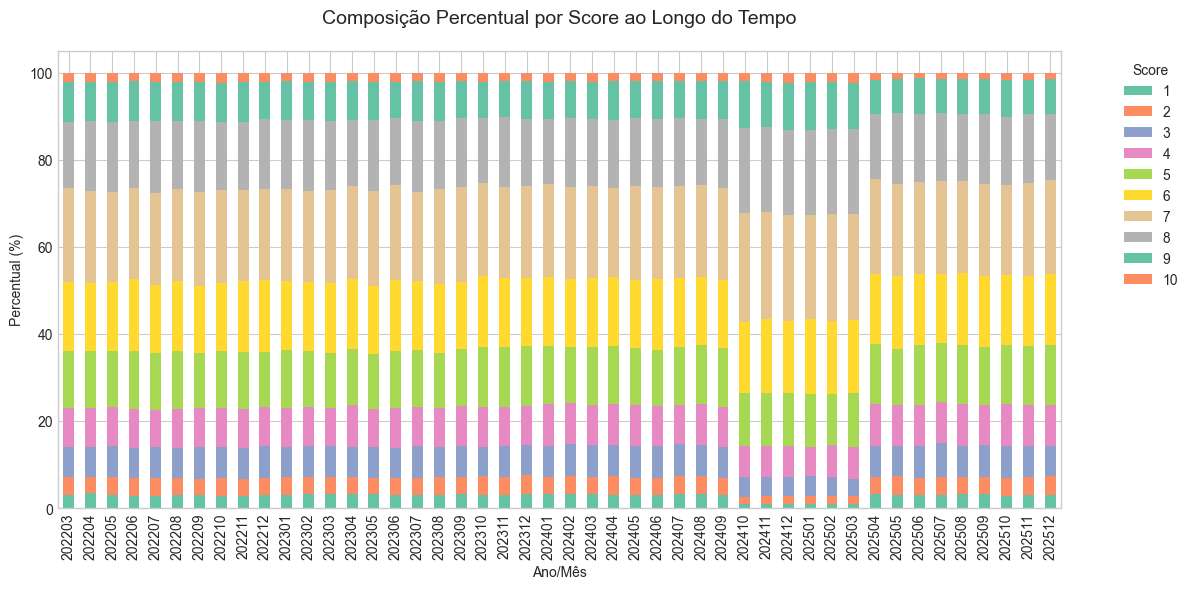

In [122]:
# Ordenar por ano_mês
dfG12 = dfG12.sort_values('ano_mes')

# Opção 2: Gráfico de barras empilhadas (mostra a composição total)
pivot_df = dfG12.pivot(index='ano_mes', columns='score', values='percentual')

cores_pastel = sns.color_palette("Set2", n_colors=len(pivot_df.columns))

pivot_df.plot(kind='bar', stacked=True, figsize=(12, 6), color=cores_pastel)

plt.title('Composição Percentual por Score ao Longo do Tempo', fontsize=14, pad=20)
plt.xlabel('Ano/Mês')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=90)
plt.legend(title='Score', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

GRÁFICO DE LINHAS - EVOLUÇÃO DA COMPOSIÇÃO POR SCORE

1. PREPARANDO DADOS...
Período: 202203 a 202512
Scores: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

2. CRIANDO GRÁFICO DE LINHAS...


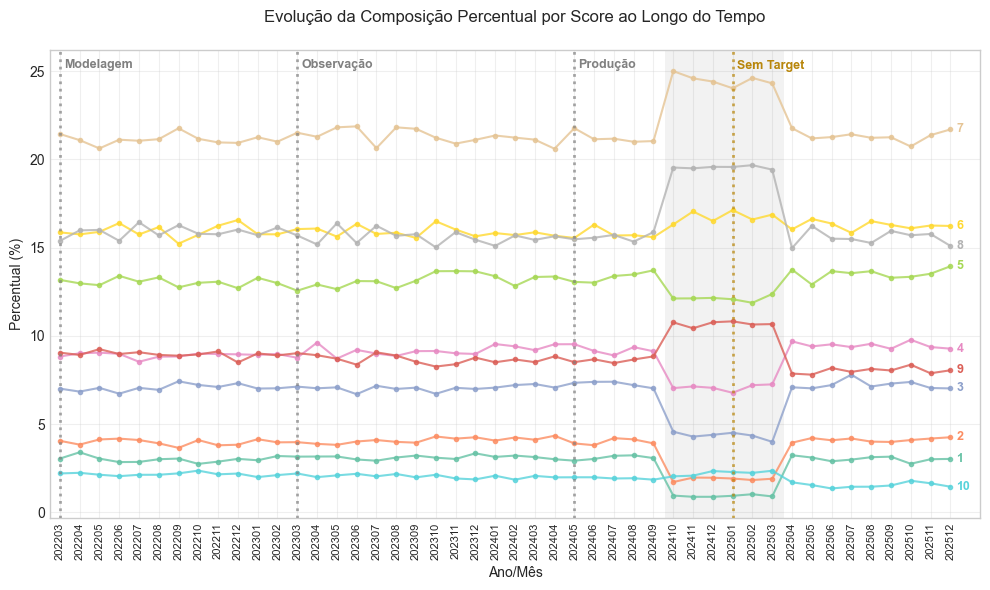


GRÁFICO CRIADO COM SUCESSO


In [402]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print("="*80)
print("GRÁFICO DE LINHAS - EVOLUÇÃO DA COMPOSIÇÃO POR SCORE")
print("="*80)

# 1. PREPARAR OS DADOS
print("\n1. PREPARANDO DADOS...")

# Garantir que dfG12 está ordenado
dfG12 = dfG12.sort_values('ano_mes')

# Criar pivot table
pivot_df = dfG12.pivot(index='ano_mes', columns='score', values='percentual')

# Garantir que todas as colunas de score existem (1-10)
for score in range(1, 11):
    if score not in pivot_df.columns:
        pivot_df[score] = 0

# Ordenar colunas
pivot_df = pivot_df[sorted(pivot_df.columns)]

print(f"Período: {pivot_df.index.min()} a {pivot_df.index.max()}")
print(f"Scores: {list(pivot_df.columns)}")

# 2. GRÁFICO DE LINHAS ÚNICO COM RÓTULOS NO FINAL
print("\n2. CRIANDO GRÁFICO DE LINHAS...")

fig, ax = plt.subplots(figsize=(10, 6))

# Definir paleta de cores
n = len(pivot_df.columns)
cores = sns.color_palette('Set2', 8) + sns.color_palette('hls', max(0, n - 8))

# Plotar cada linha
for i, score in enumerate(pivot_df.columns):
    linha = pivot_df[score].values
    x_pos = range(len(linha))
    
    # Plotar linha
    ax.plot(x_pos, linha, 
            marker='o', 
            markersize=3,
            linewidth=1.5,
            color=cores[i],
            alpha=0.8)
    
    # Adicionar rótulo no final da linha
    ultimo_x = x_pos[-1]
    ultimo_y = linha[-1]
    
    ax.text(ultimo_x + 0.3, ultimo_y, 
            f'{score}', 
            fontsize=9,
            color=cores[i],
            fontweight='bold',
            va='center')

# Configurar eixo X
ax.set_xlim(-0.5, len(pivot_df) + 0.5)
ax.set_xticks(range(len(pivot_df)))
ax.set_xticklabels(pivot_df.index, rotation=90, fontsize=8)

# Configurar labels e título
ax.set_xlabel('Ano/Mês', fontsize=10)
ax.set_ylabel('Percentual (%)', fontsize=10)
ax.set_title('Evolução da Composição Percentual por Score ao Longo do Tempo', 
             fontsize=12, pad=20)


meses_hachurados2 = [202410, 202411, 202412, 202501, 202502, 202503]
indices_hachurados = [list(pivot_df.index).index(mes) for mes in meses_hachurados2 if mes in list(pivot_df.index)]
# Adicionar hachuras
y_min, y_max = ax.get_ylim()
for i in indices_hachurados:
    rect = Rectangle((i-0.4, y_min), 1, y_max - y_min, facecolor='gray', alpha=0.1, linewidth=0, zorder=1)
    ax.add_patch(rect)

# Adicionar linhas verticais
for nome_periodo, idx_periodo in indices_periodos.items():
    cor = 'darkgoldenrod' if 'Sem Target' in nome_periodo else 'gray'
    ax.axvline(x=idx_periodo, color=cor, linestyle=':', linewidth=2, alpha=0.7, zorder=5)
    ax.text(idx_periodo + 0.2, y_max * 0.98 , nome_periodo, rotation=0, fontsize=9, color=cor, fontweight='bold', ha='left', va='top')


# Adicionar grid
ax.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("GRÁFICO CRIADO COM SUCESSO")
print("="*80)

[31, 32, 33, 34, 35]

## Carta Controle 2

ValueError: operands could not be broadcast together with shapes (13,) (10,) 

# END

---

#### <span style="color:purple">Nota</span>
